In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
import os
os.chdir(r"C:/Users/jamed\Documents/repos/terrain_classification_project/TerrainClassificationForFloodModelling")

In [47]:
import torch
from structured_data_utils.data import ModelData
from structured_data_utils.structured_data_interfacing import (
    standardise_dataset,
    load_data_with_labels,
    put_nans_in_neggative_positions,
    normalise_dwl_local,
    get_segments_with_sliding_window,
    remove_empty_segments,
    infer_nans_segmented,
 )

In [48]:
standardise_dataset("WILLOWAN", force=False)
md = ModelData()

md.data_with_labels = load_data_with_labels("WILLOWAN")
md.data_with_labels.data = put_nans_in_neggative_positions(
    md.data_with_labels.data
 )

Standardised file already exists at data\WILLOWAN\POSITIVE_STANDARDISED.tif. Skipping. Use force=True to override.
Standardised file already exists at data\WILLOWAN\COMBINED_STANDARDISED.tif. Skipping. Use force=True to override.


In [49]:
standardise_dataset("WILLOWAN", force=False)
md = ModelData()

md.data_with_labels = load_data_with_labels("WILLOWAN")
md.data_with_labels.data = put_nans_in_neggative_positions(
    md.data_with_labels.data
 )
md.data_with_labels = normalise_dwl_local(
    md.data_with_labels, kernel_size=11
 )

Standardised file already exists at data\WILLOWAN\POSITIVE_STANDARDISED.tif. Skipping. Use force=True to override.
Standardised file already exists at data\WILLOWAN\COMBINED_STANDARDISED.tif. Skipping. Use force=True to override.
[local_normalise:input] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5033127 nan%=9.68
[local_normalise:input] min=113.168098 max=128.880936 mean=124.579155 std=1.396130 median=124.953583 p01=118.729362 p05=121.867531 p95=125.641922 p99=125.835381
[local_normalise:output] shape=(1, 2135, 2610) dtype=torch.float32 total=5572350 valid=5572350 nan%=0.00
[local_normalise:output] min=0.000000 max=48.087933 mean=21.435007 std=1.000000 median=21.435066 p01=18.279329 p05=20.686172 p95=22.154362 p99=24.739069


dwl shapes -- data: torch.Size([1, 2135, 2610]), labels: torch.Size([1, 2135, 2610])
SegmentedDataWithLabels size: data=0.04 GB, labels=0.04 GB, total=0.09 GB
Gross size of all SegmentedDataWithLabels so far: 0.09 GB
SegmentedDataWithLabels size: data=0.03 GB, labels=0.03 GB, total=0.05 GB
Gross size of all SegmentedDataWithLabels so far: 0.14 GB
SegmentedDataWithLabels size: data=0.01 GB, labels=0.01 GB, total=0.03 GB
Gross size of all SegmentedDataWithLabels so far: 0.16 GB
SegmentedDataWithLabels size: data=0.08 GB, labels=0.08 GB, total=0.16 GB
Gross size of all SegmentedDataWithLabels so far: 0.32 GB
SegmentedDataWithLabels size: data=0.01 GB, labels=0.01 GB, total=0.02 GB
Gross size of all SegmentedDataWithLabels so far: 0.35 GB
SegmentedDataWithLabels size: data=0.08 GB, labels=0.08 GB, total=0.17 GB
Gross size of all SegmentedDataWithLabels so far: 0.51 GB
SegmentedDataWithLabels size: data=0.06 GB, labels=0.06 GB, total=0.12 GB
Gross size of all SegmentedDataWithLabels so far:

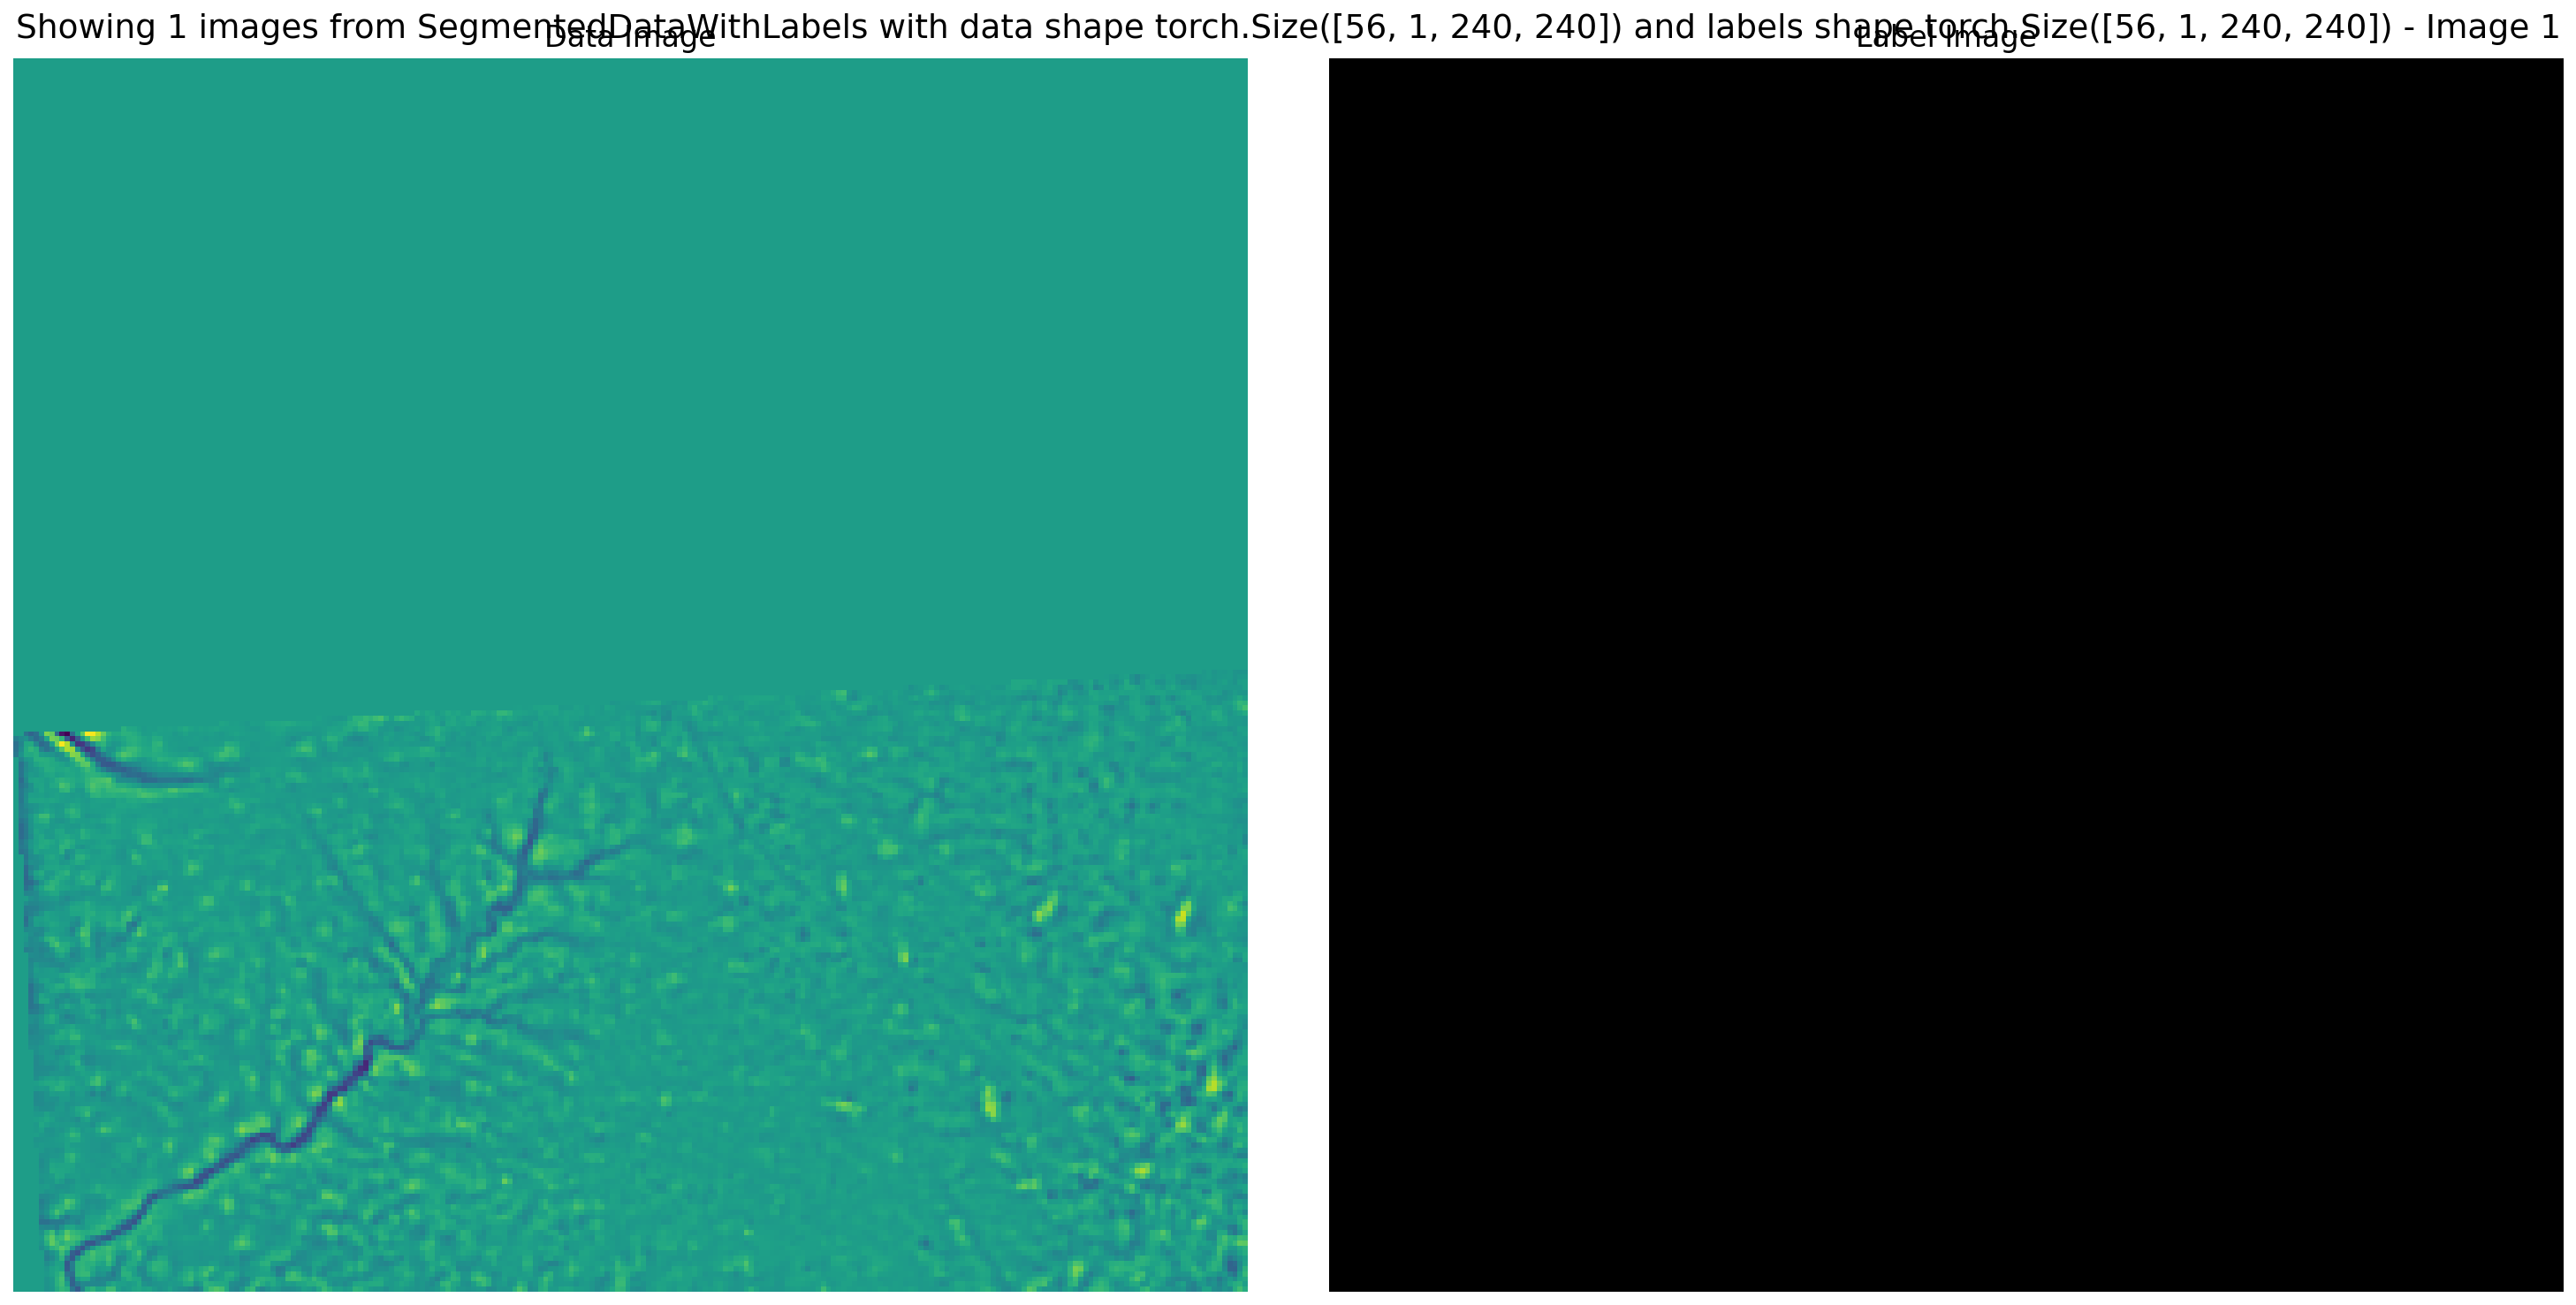

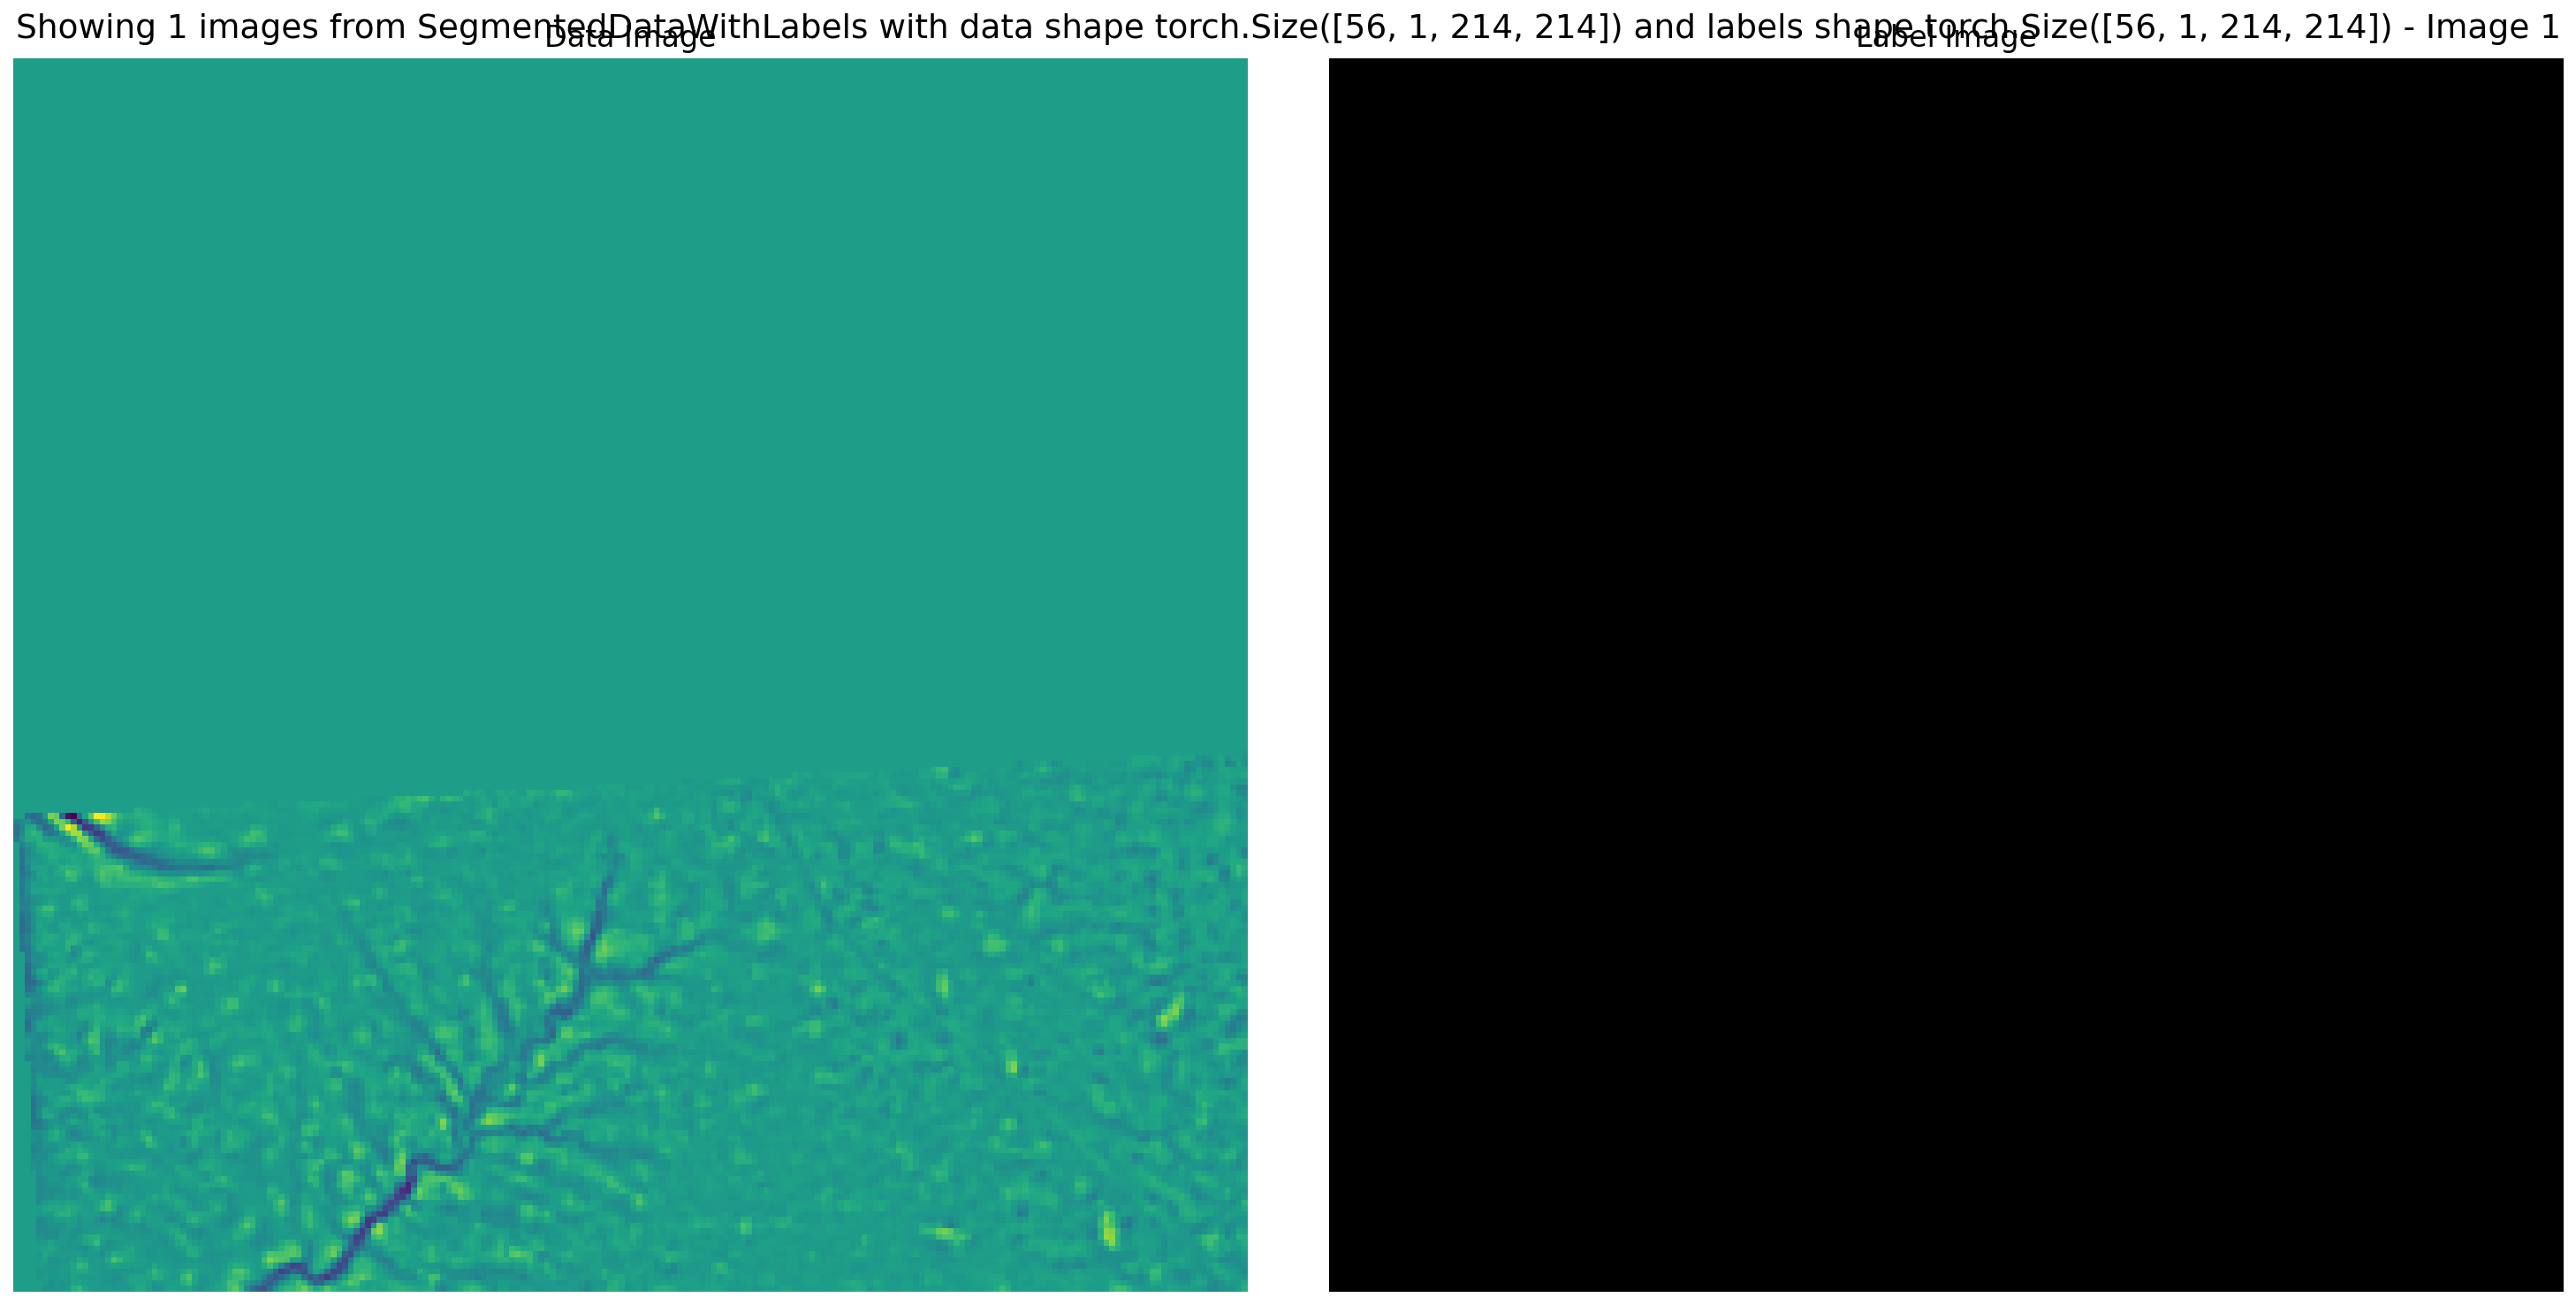

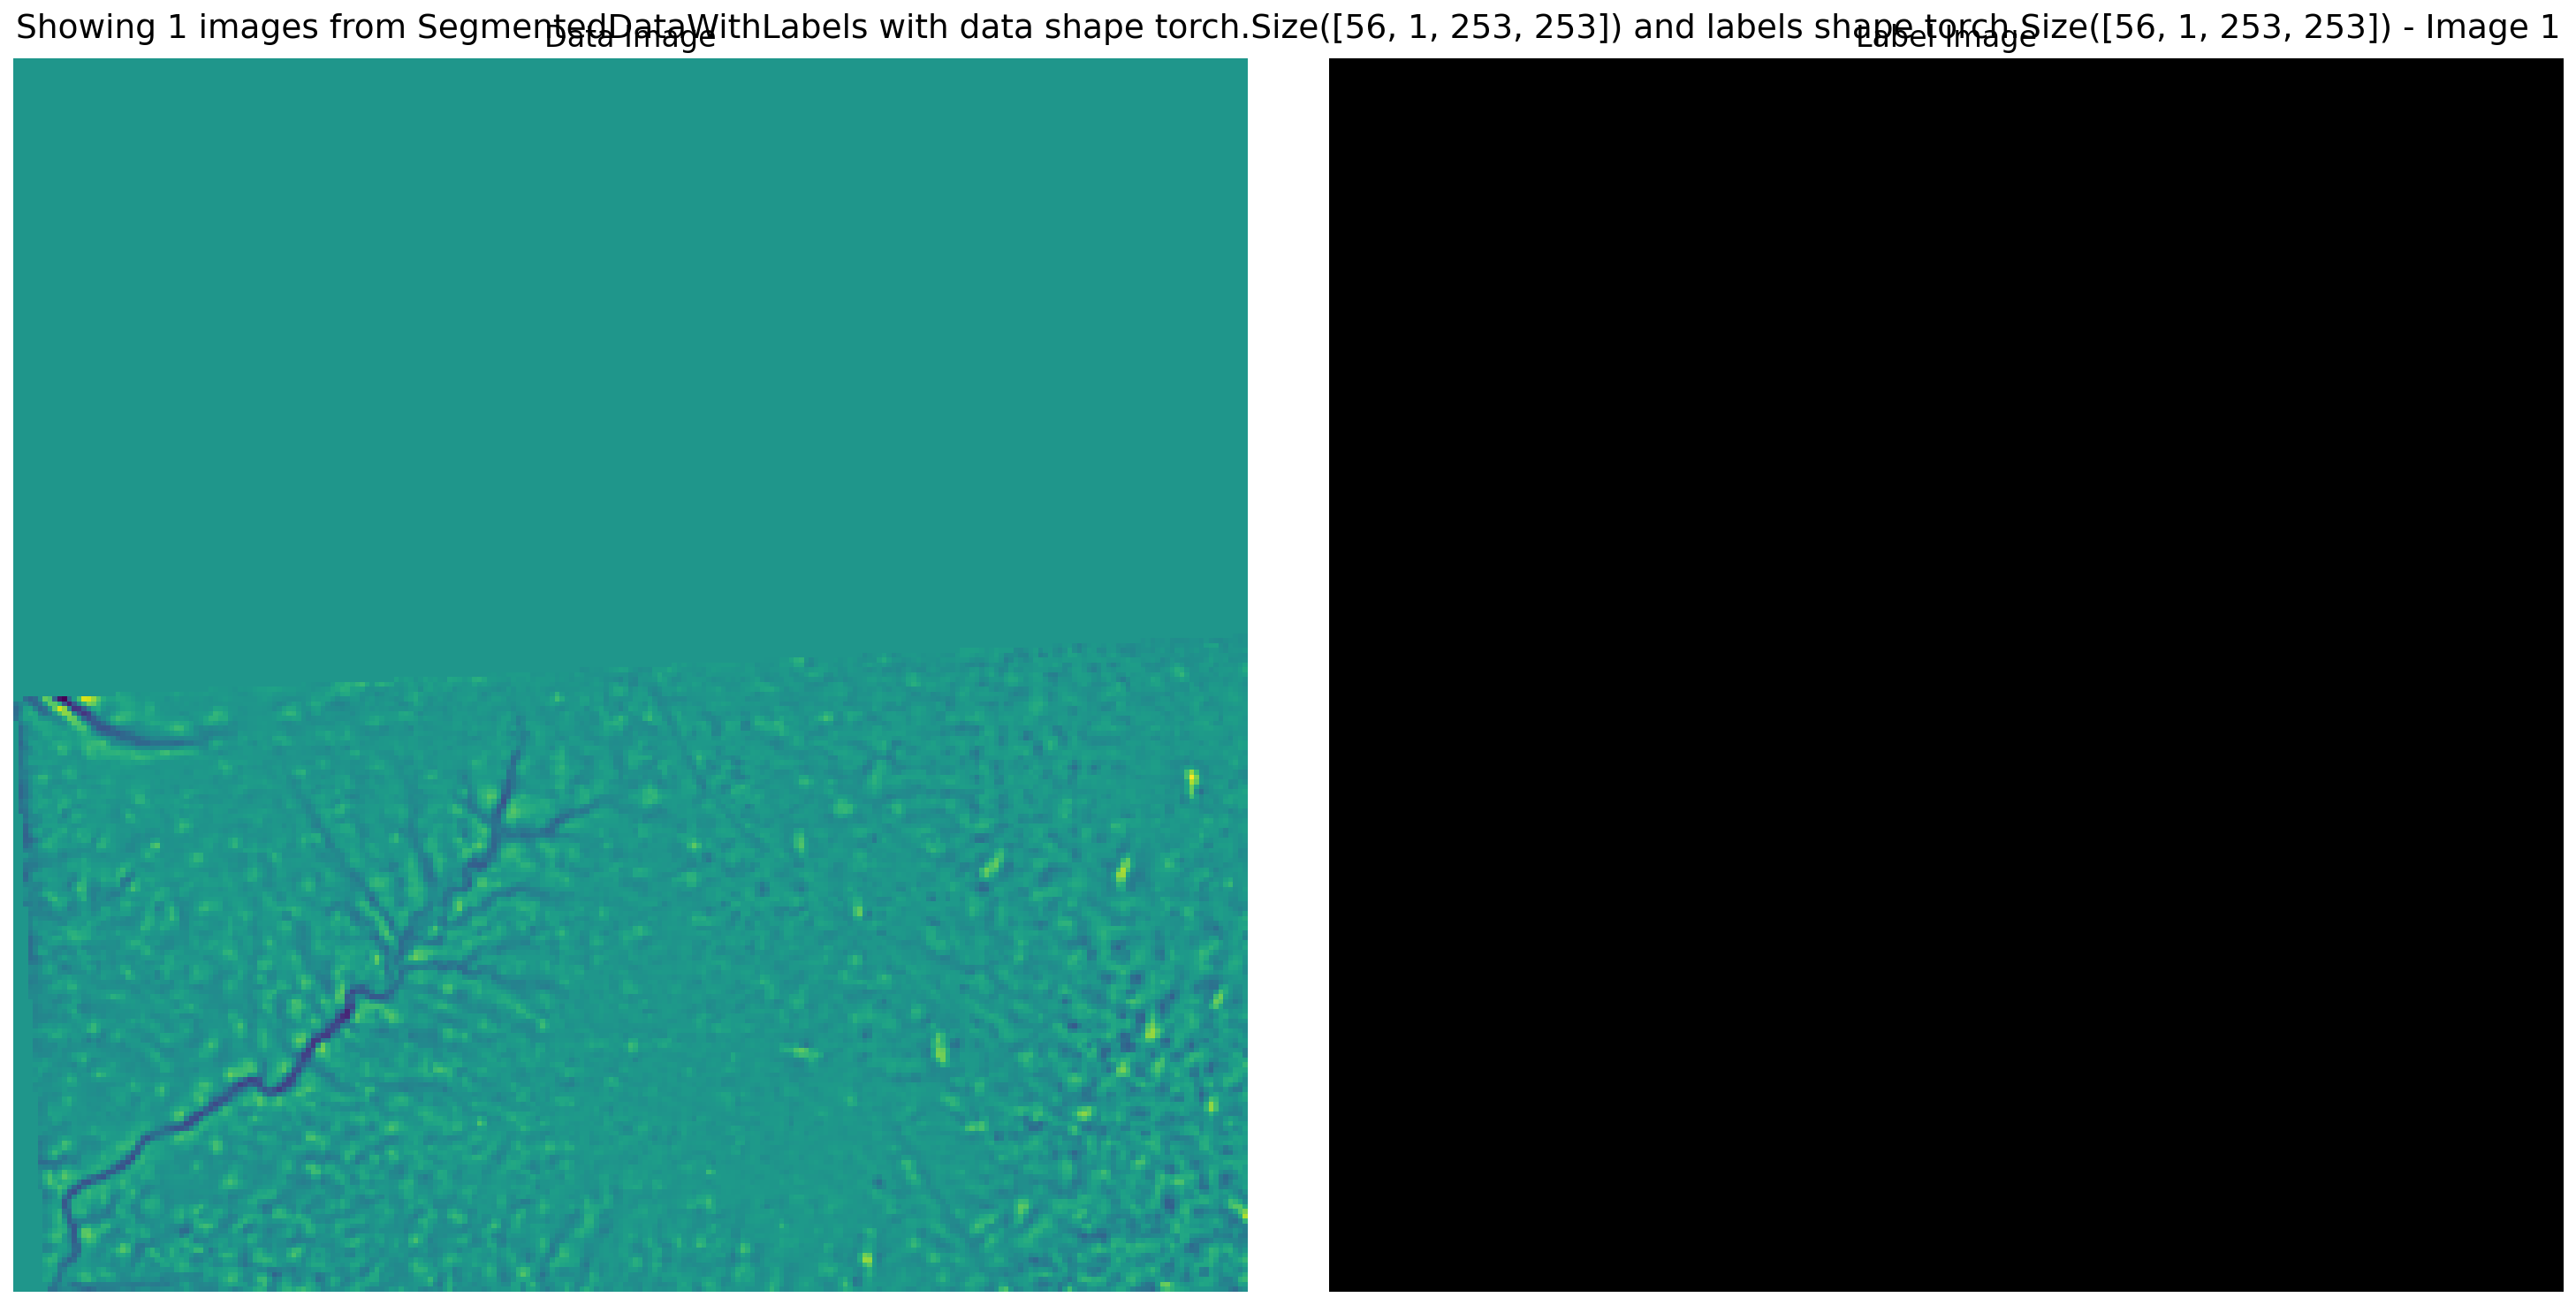

In [50]:
md.segmented_data_with_labels = get_segments_with_sliding_window(
    md.data_with_labels,
    base_window_size=300,
    stride=300,
 )
md.segmented_data_with_labels = infer_nans_segmented(
    md.segmented_data_with_labels
 )
if torch.isnan(md.segmented_data_with_labels.data).any():
    print("infering nans failed...")

In [51]:
def show_images_from_segmented_data_with_labels(segmented_data_with_labels, num_images: int = 5):
    import matplotlib.pyplot as plt

    for i in range(num_images):
        data_image = segmented_data_with_labels.data[i].squeeze().cpu().numpy()
        label_image = segmented_data_with_labels.labels[i].squeeze().cpu().numpy()

        fig, axes = plt.subplots(1, 2, figsize=(20, 10), dpi=150)
        axes[0].imshow(data_image, cmap='viridis')
        axes[0].set_title('Data Image', fontsize=16)
        axes[0].axis('off')

        axes[1].imshow(label_image, cmap='gray')
        axes[1].set_title('Label Image', fontsize=16)
        axes[1].axis('off')

        plt.tight_layout()
        plt.show()

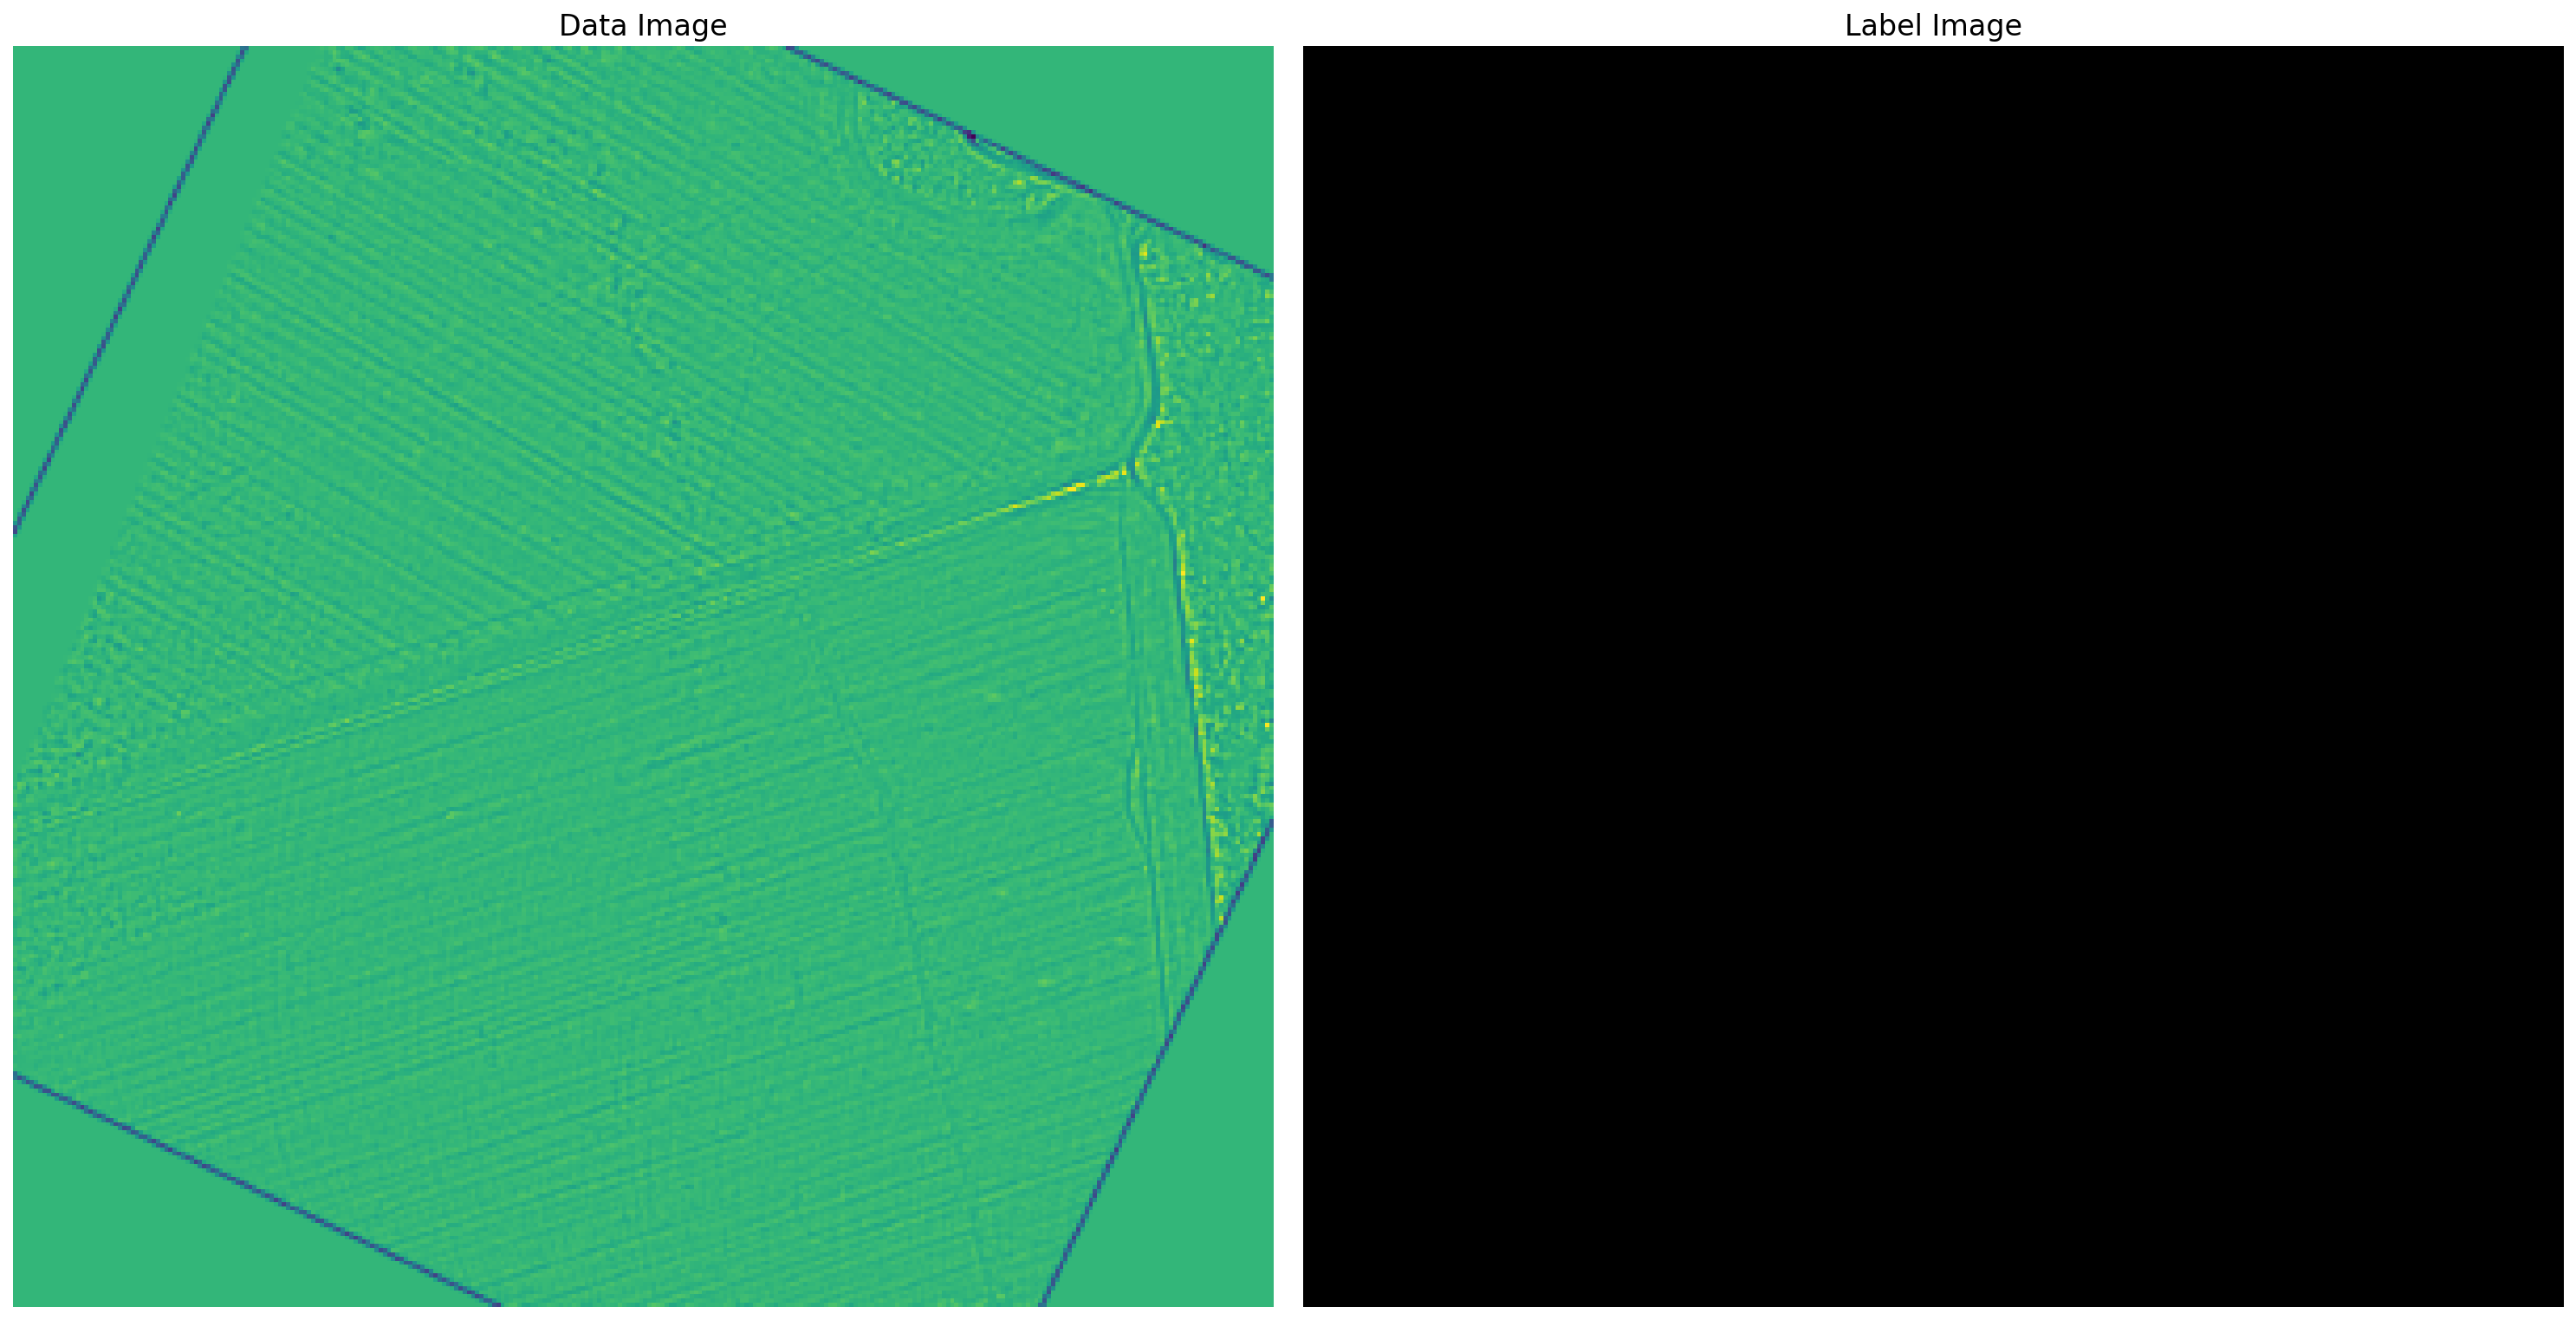

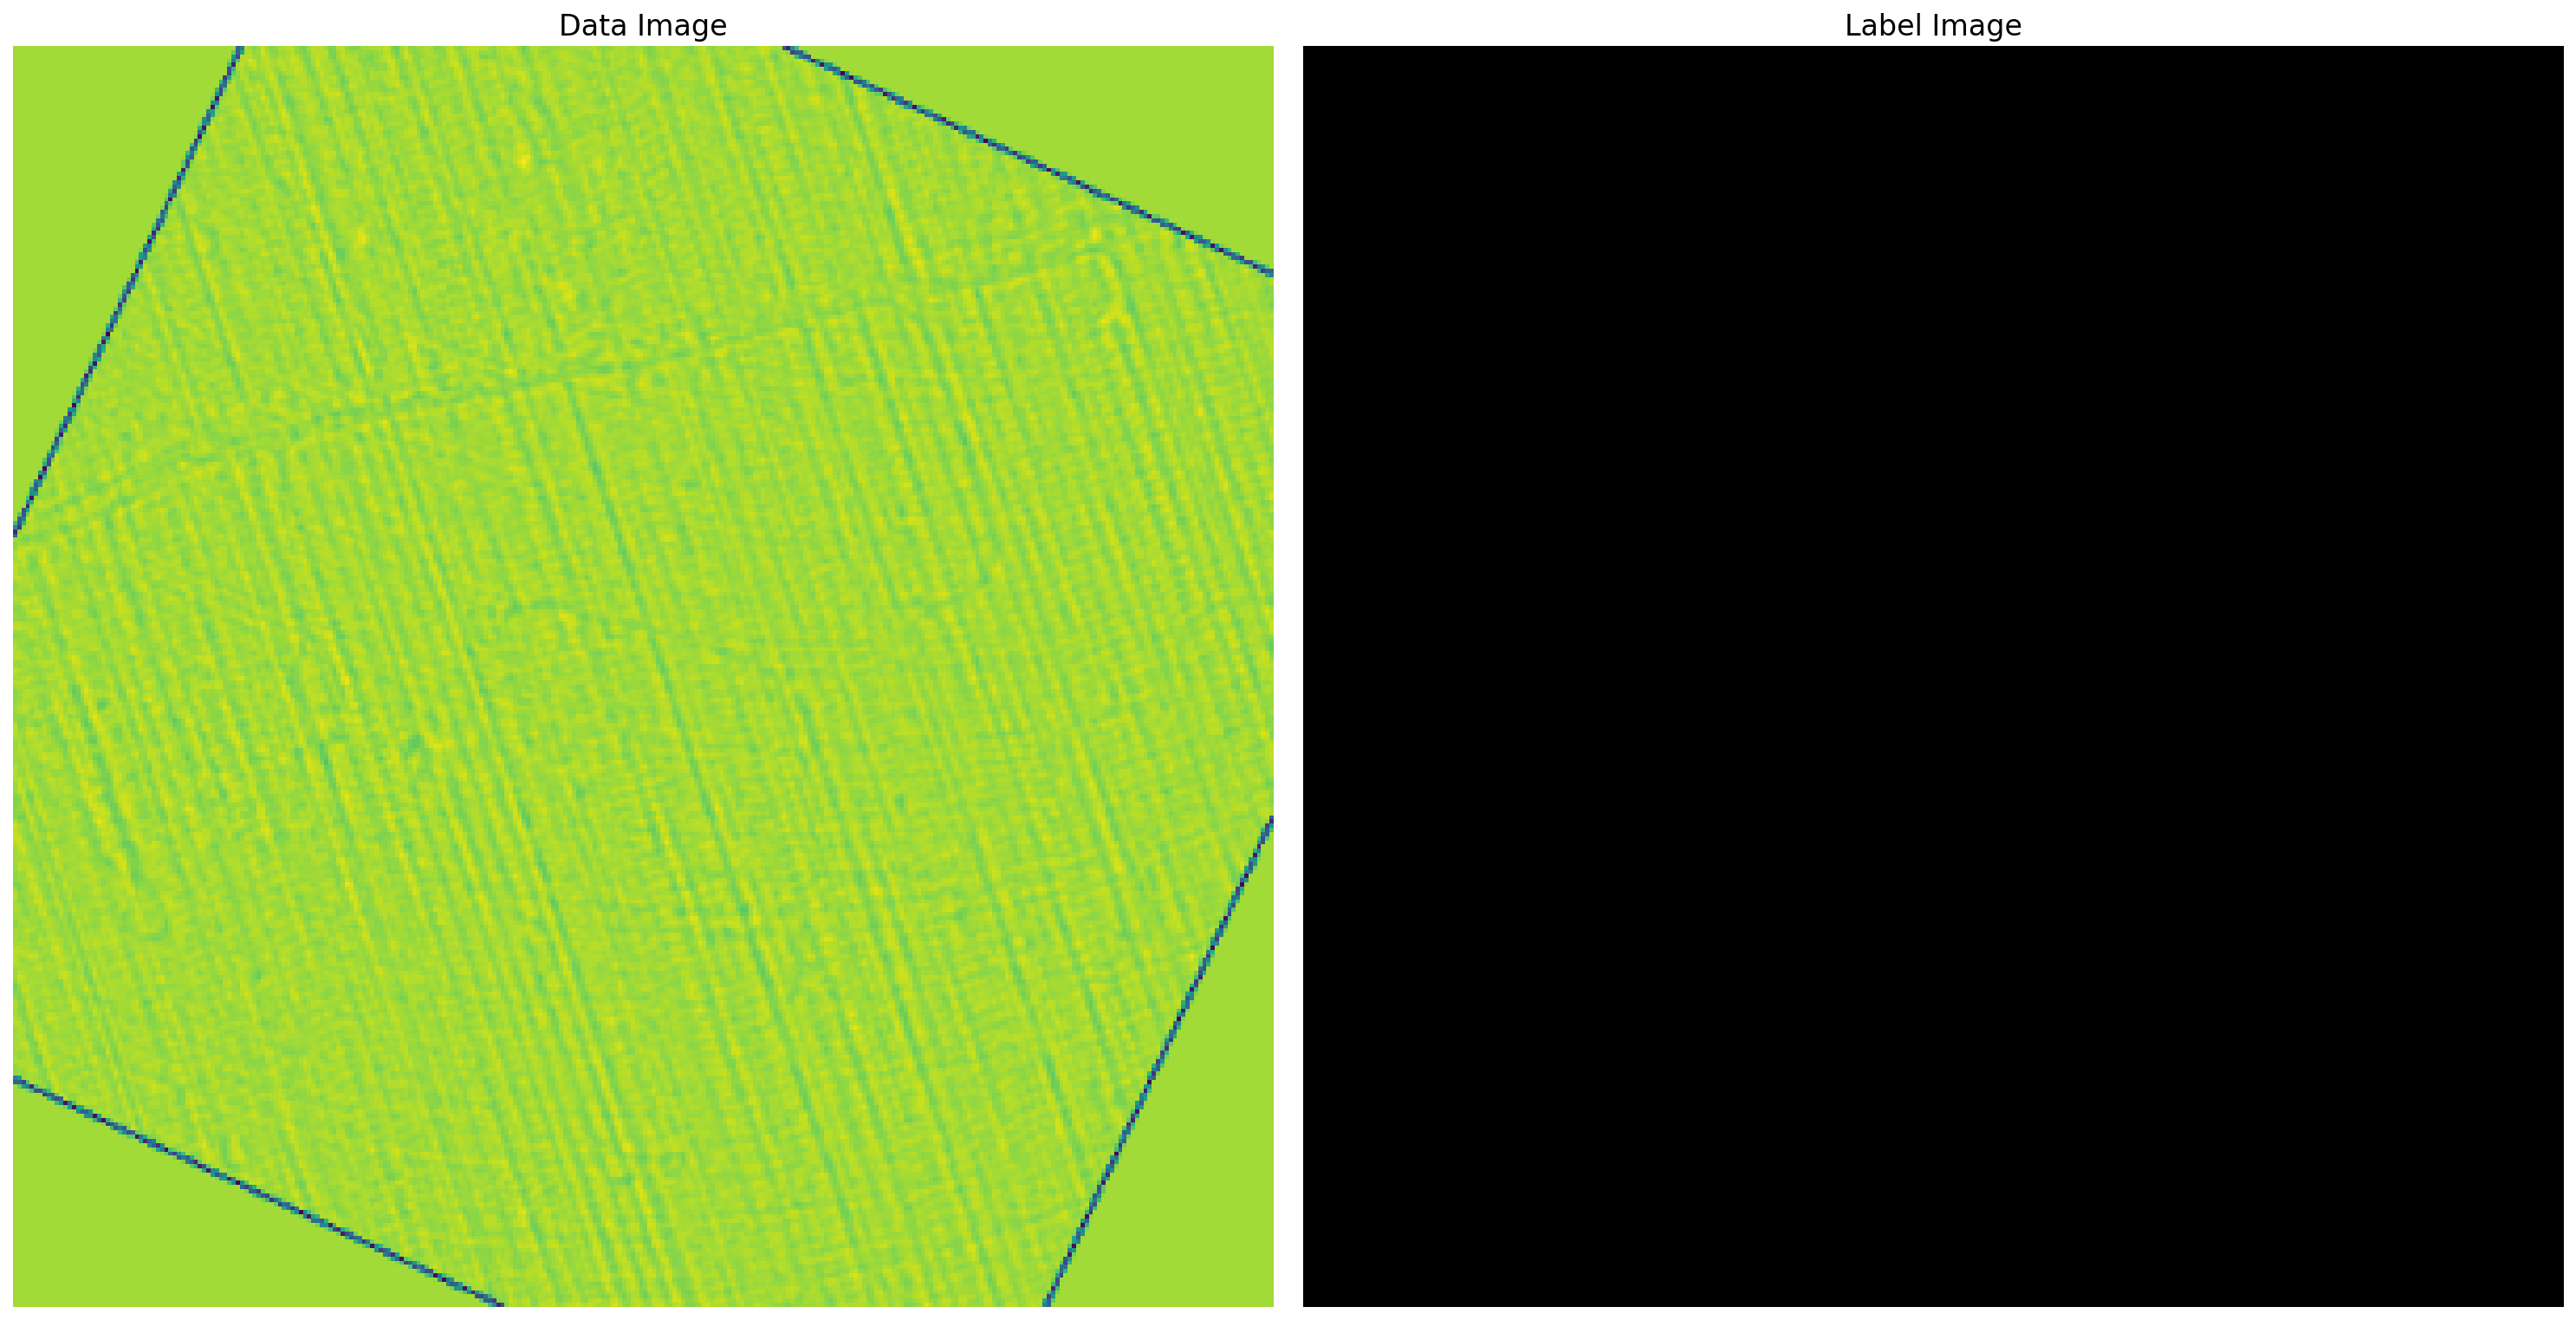

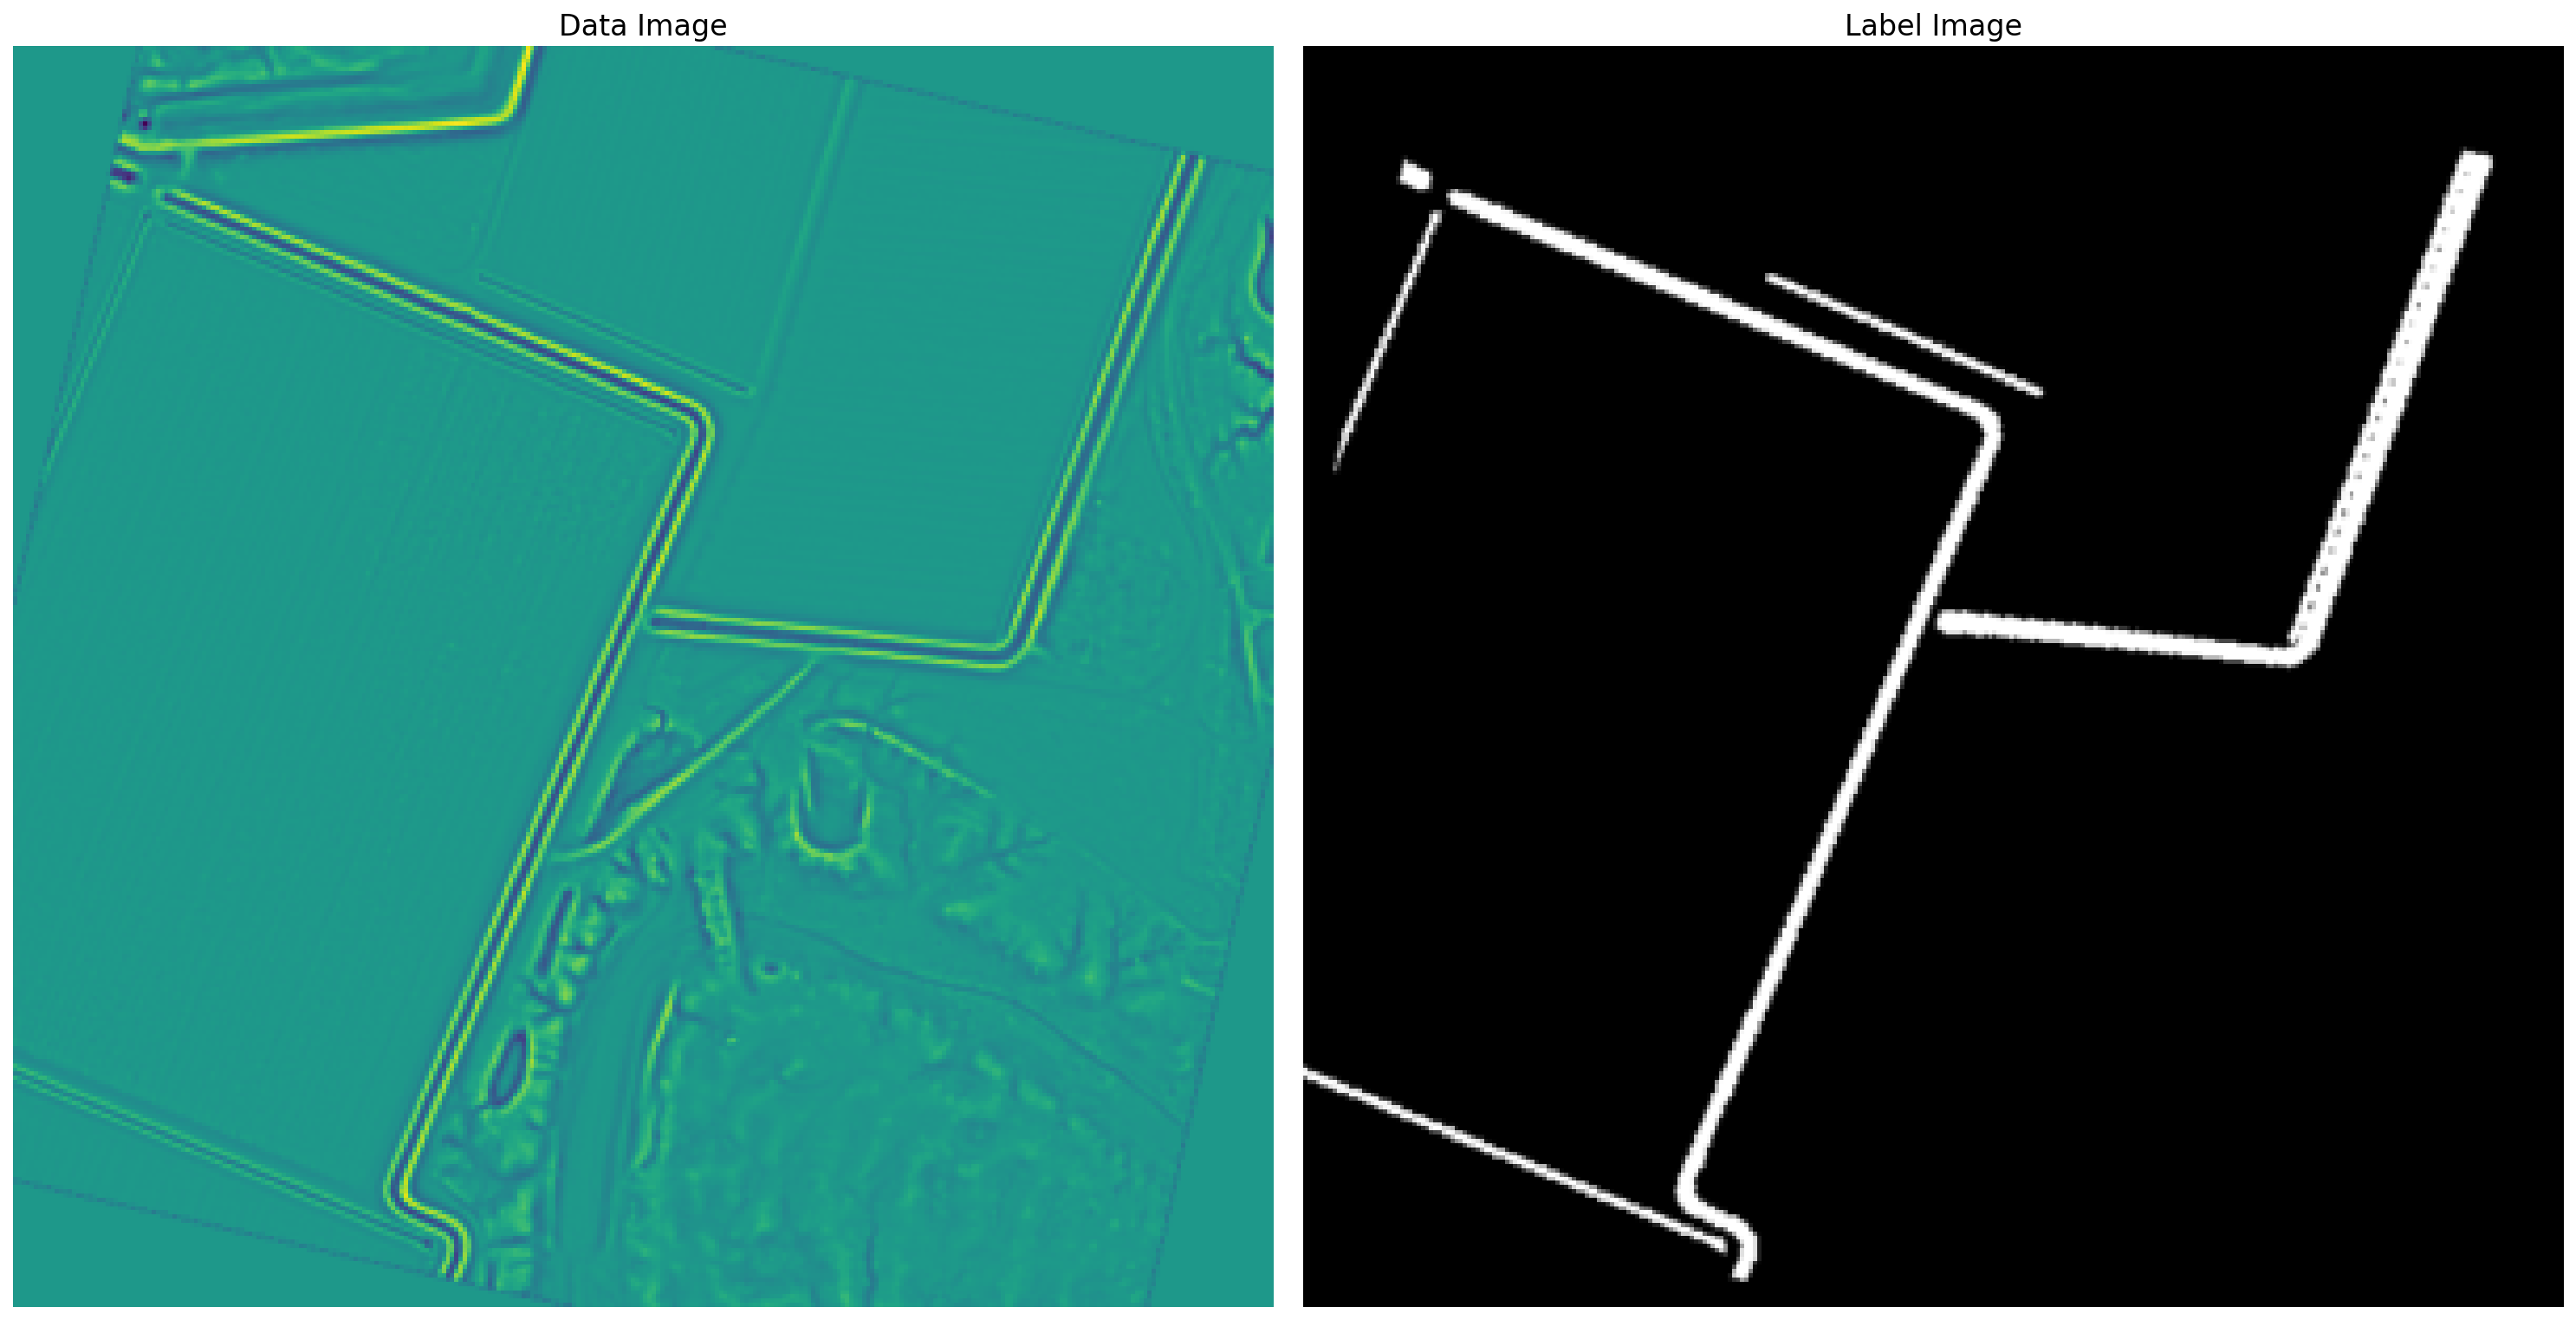

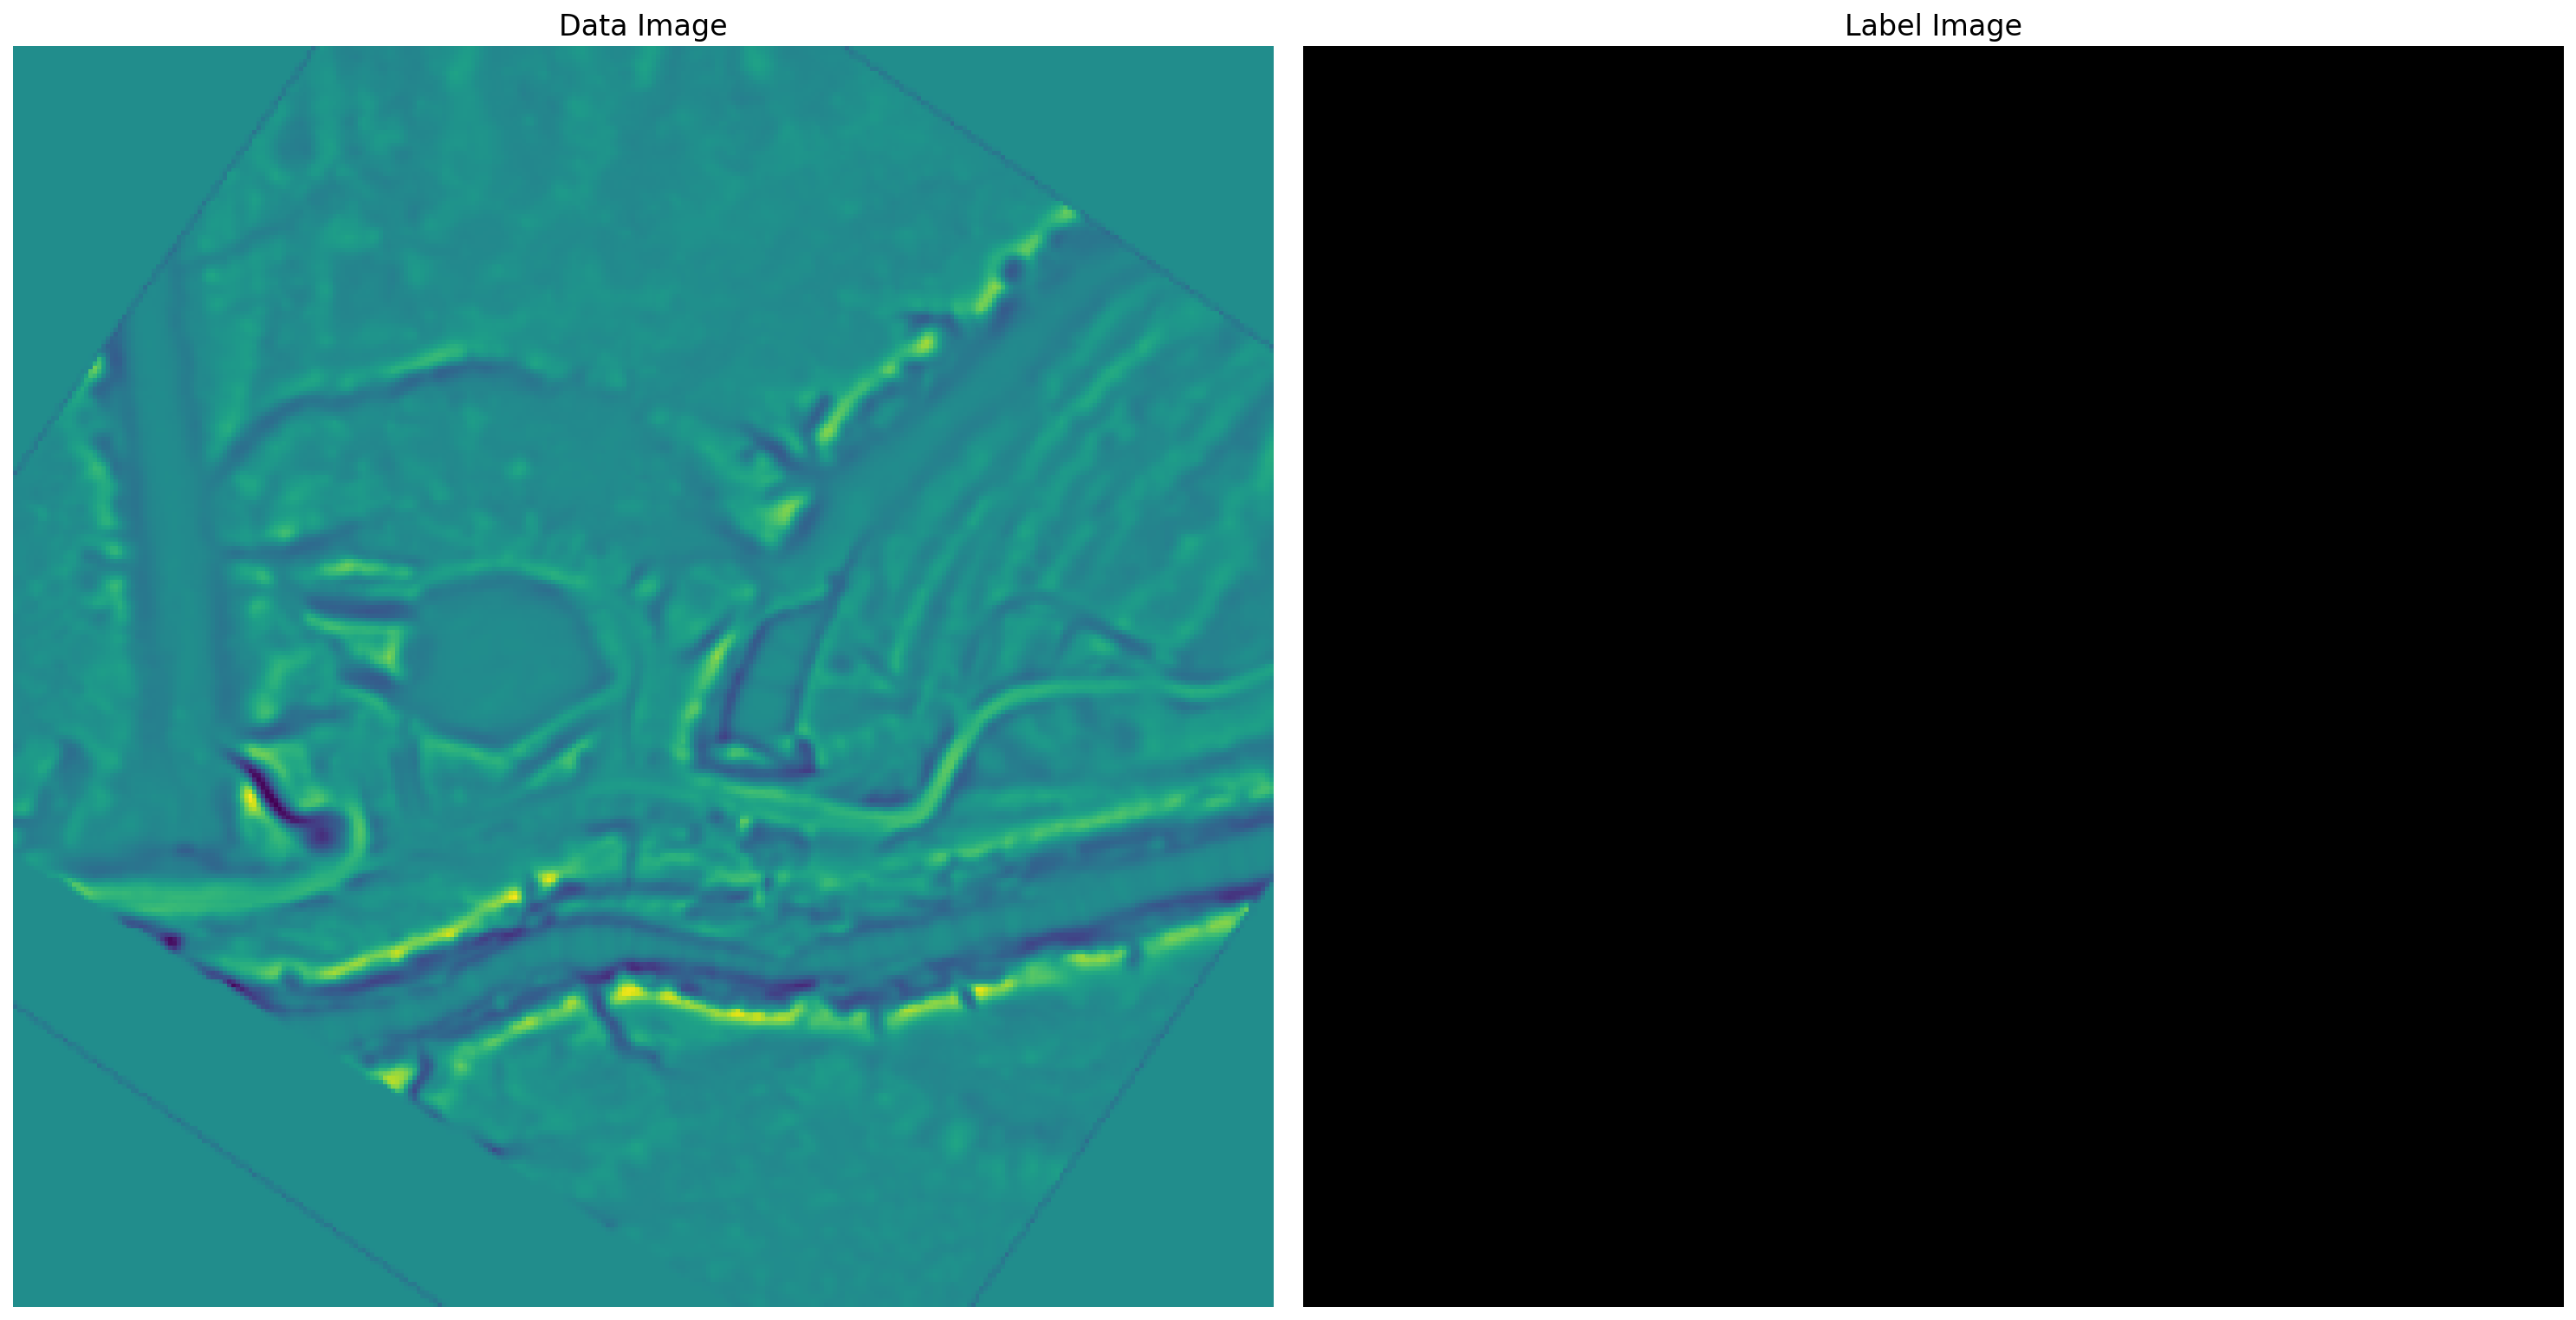

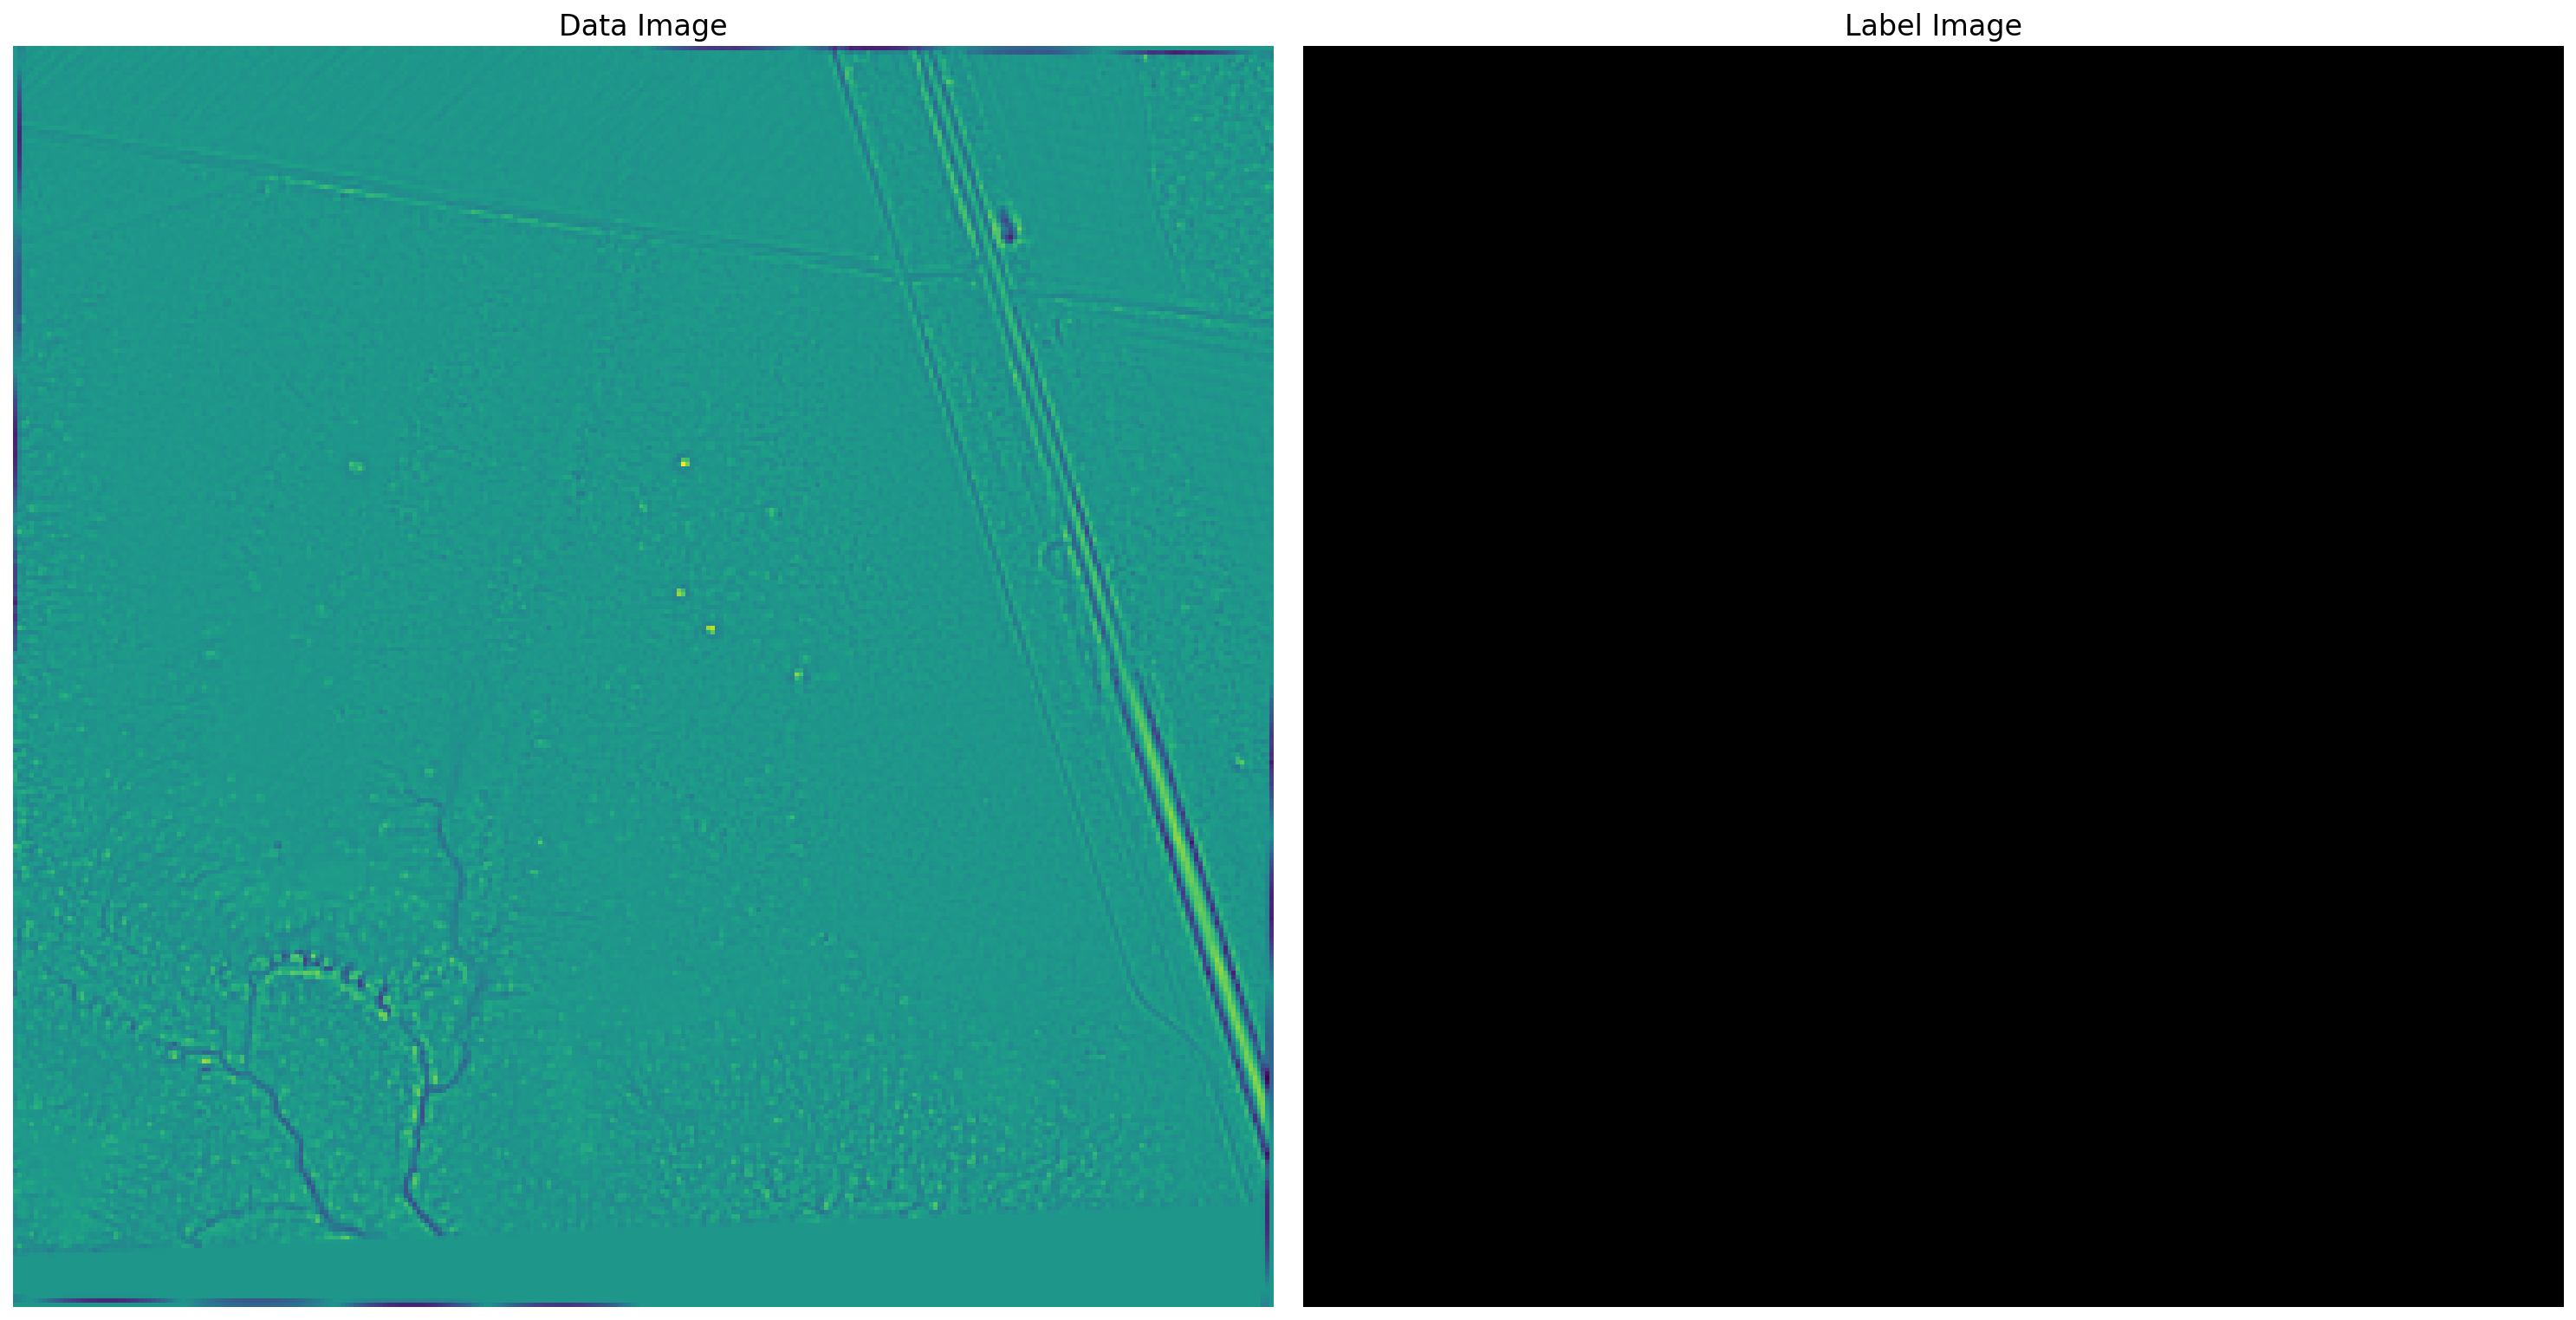

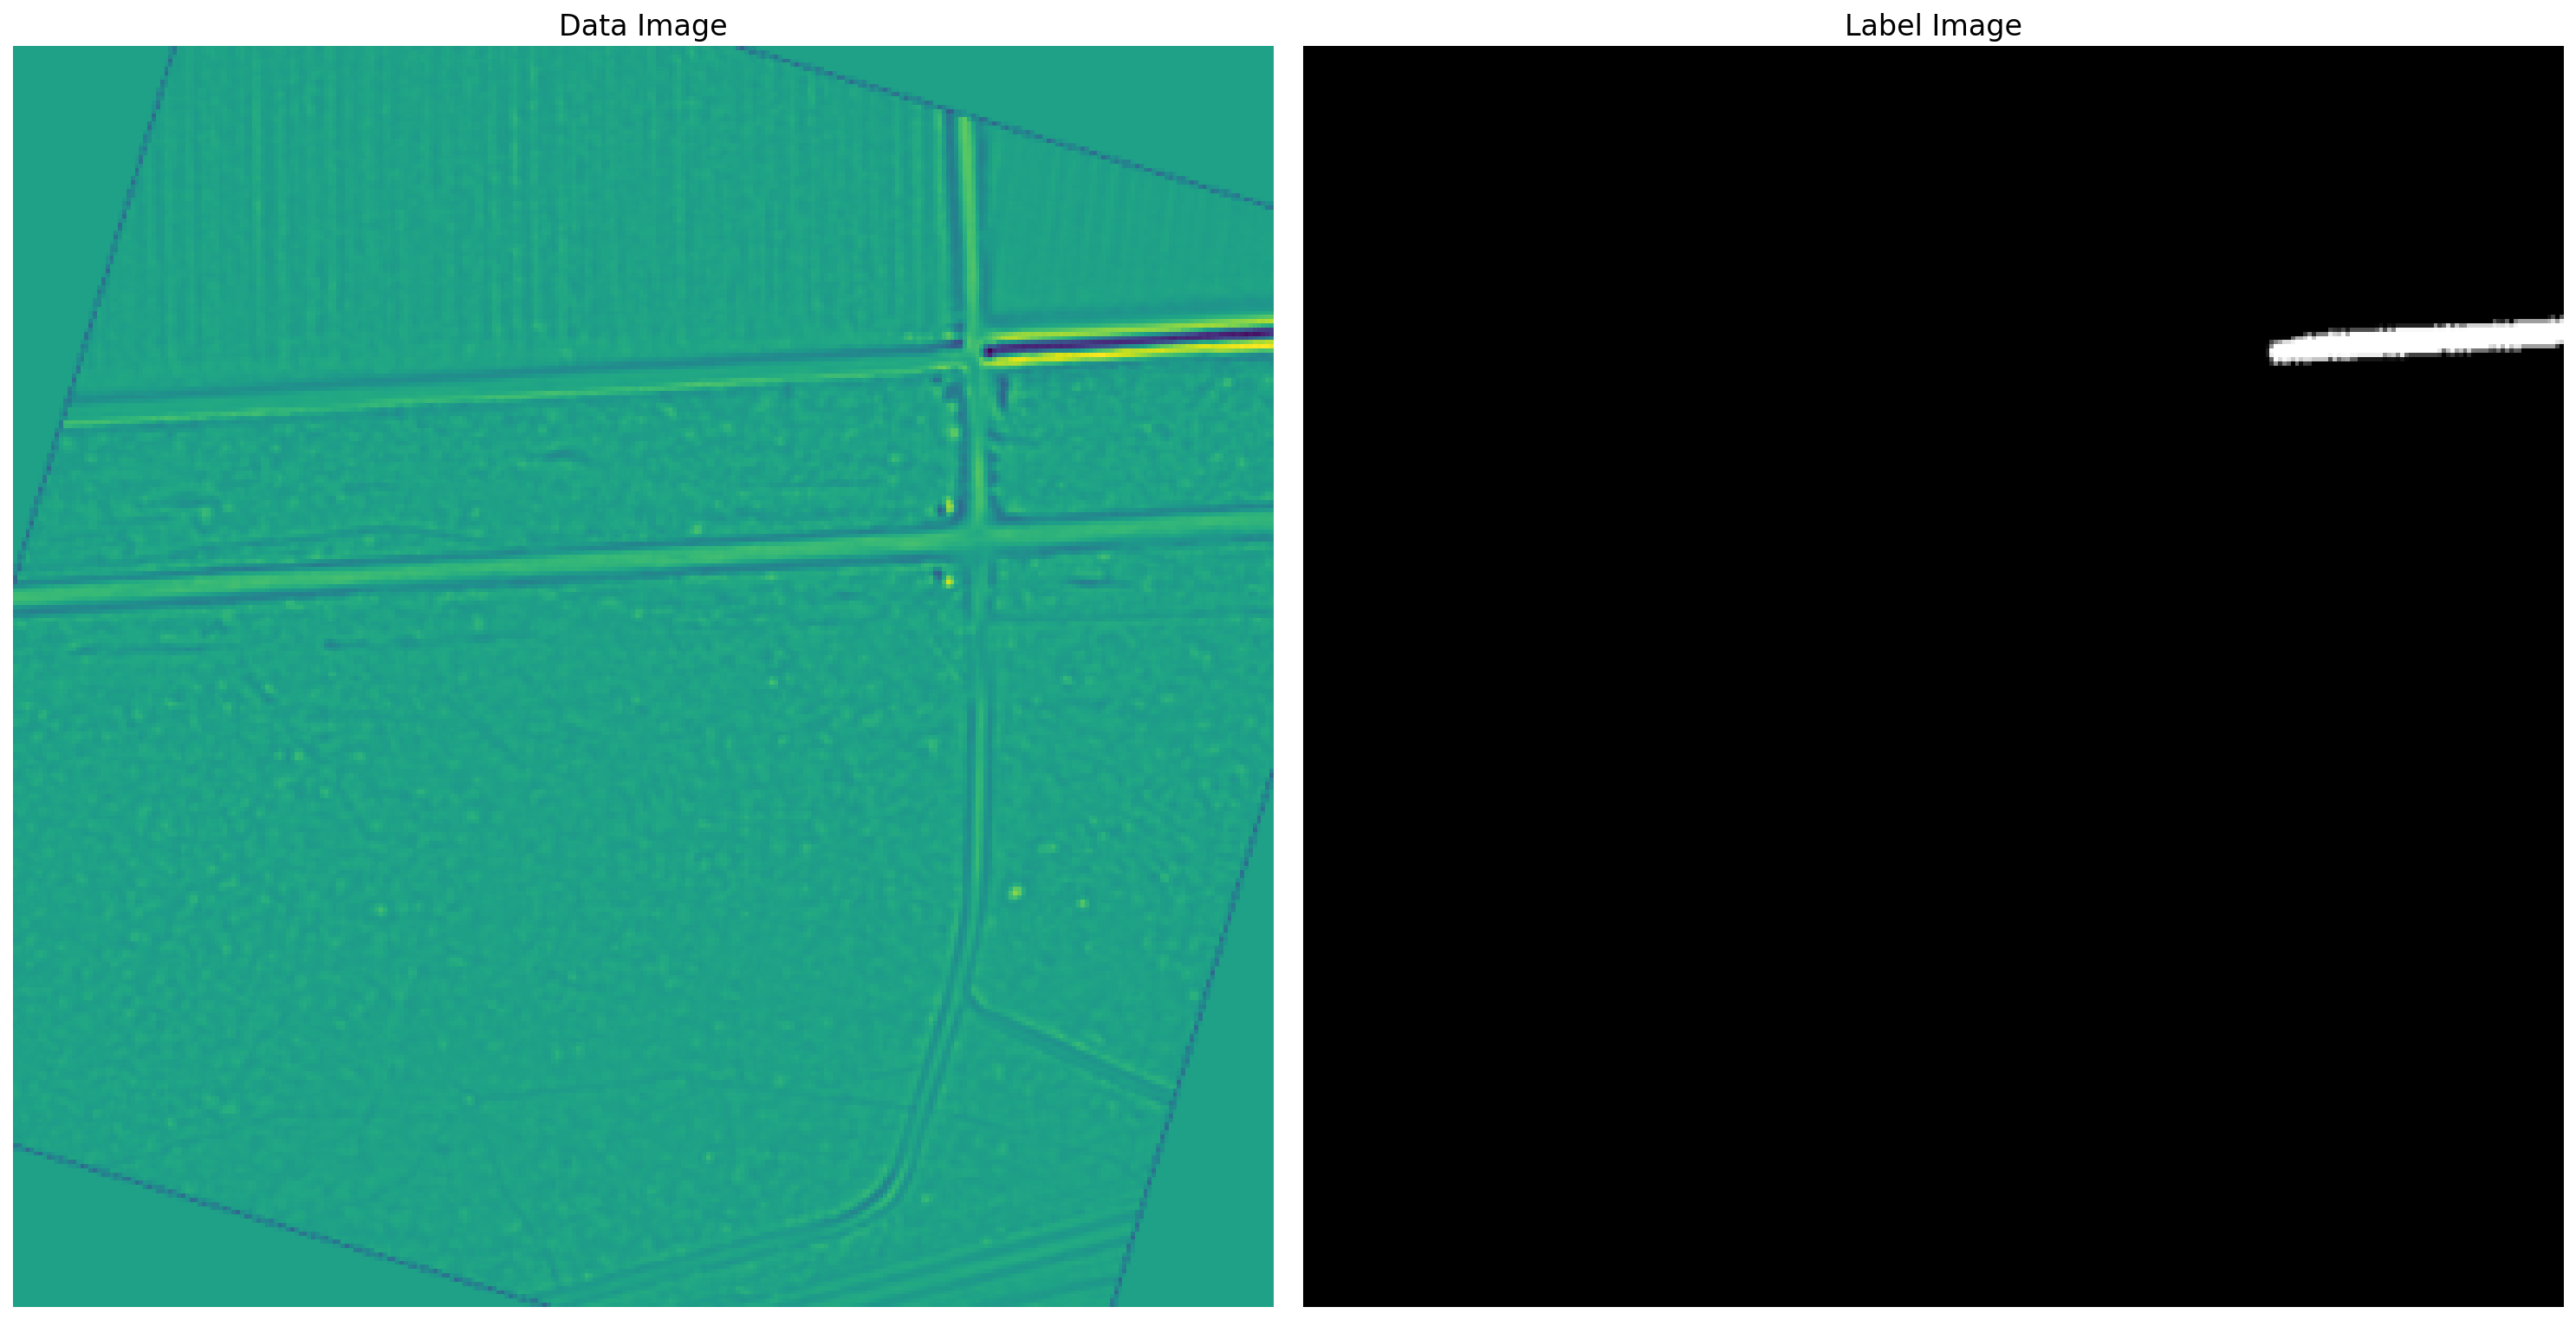

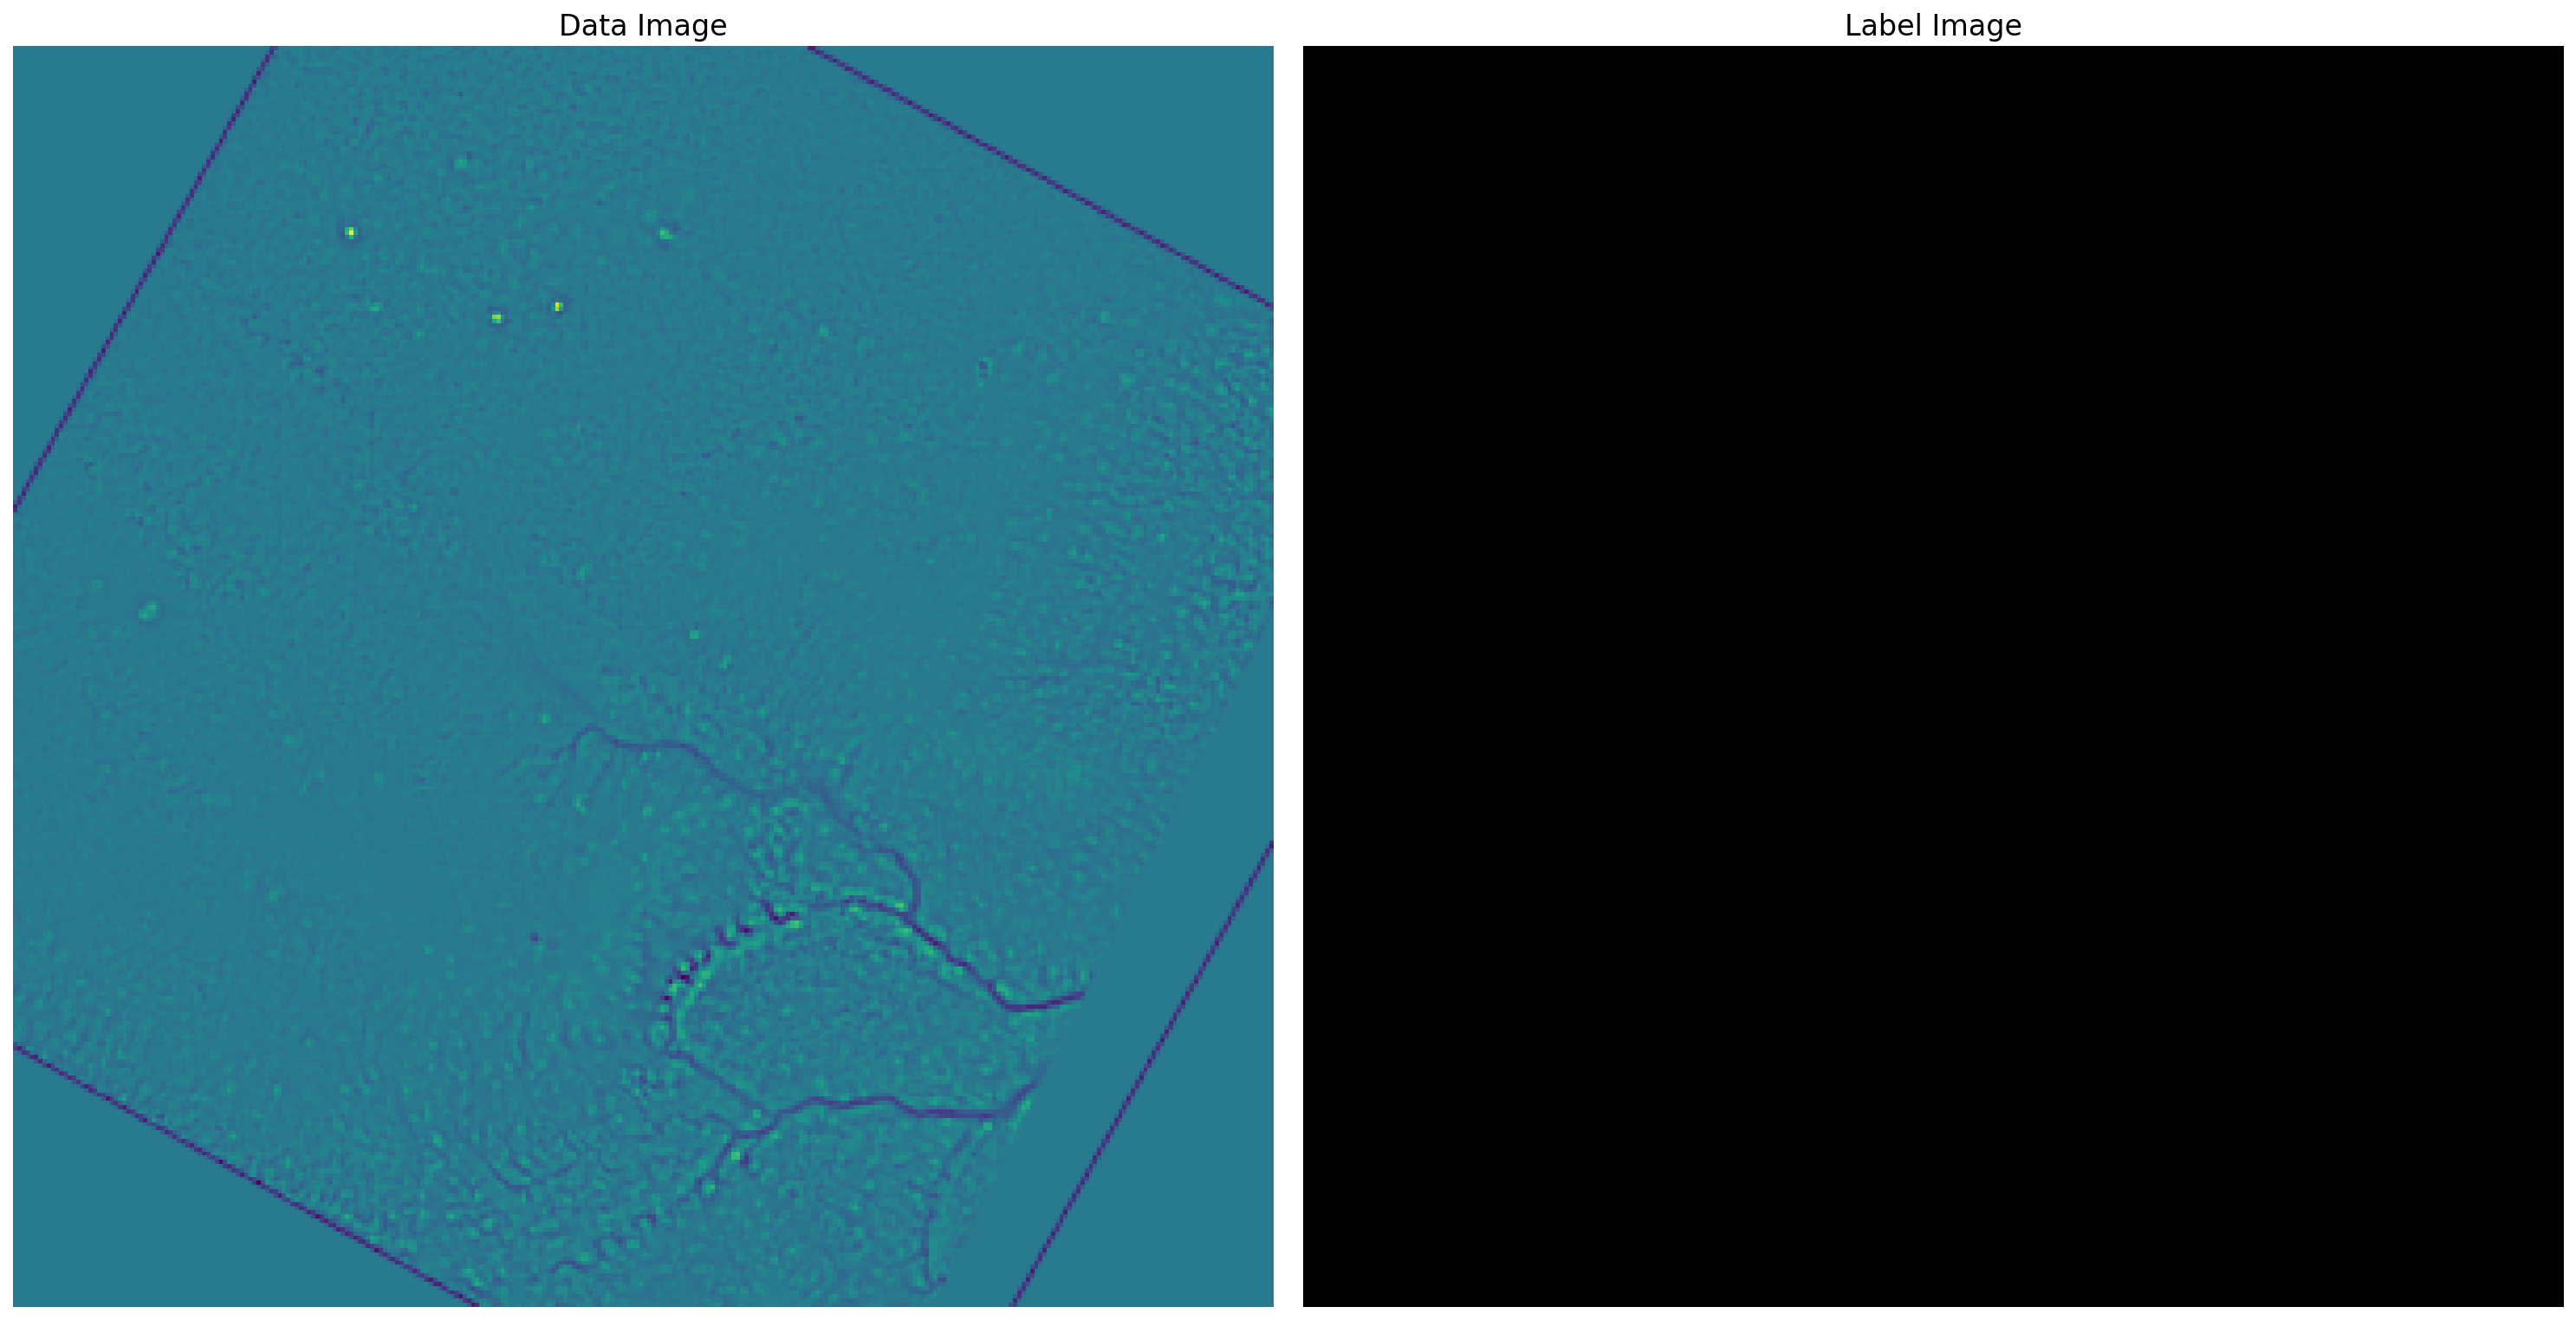

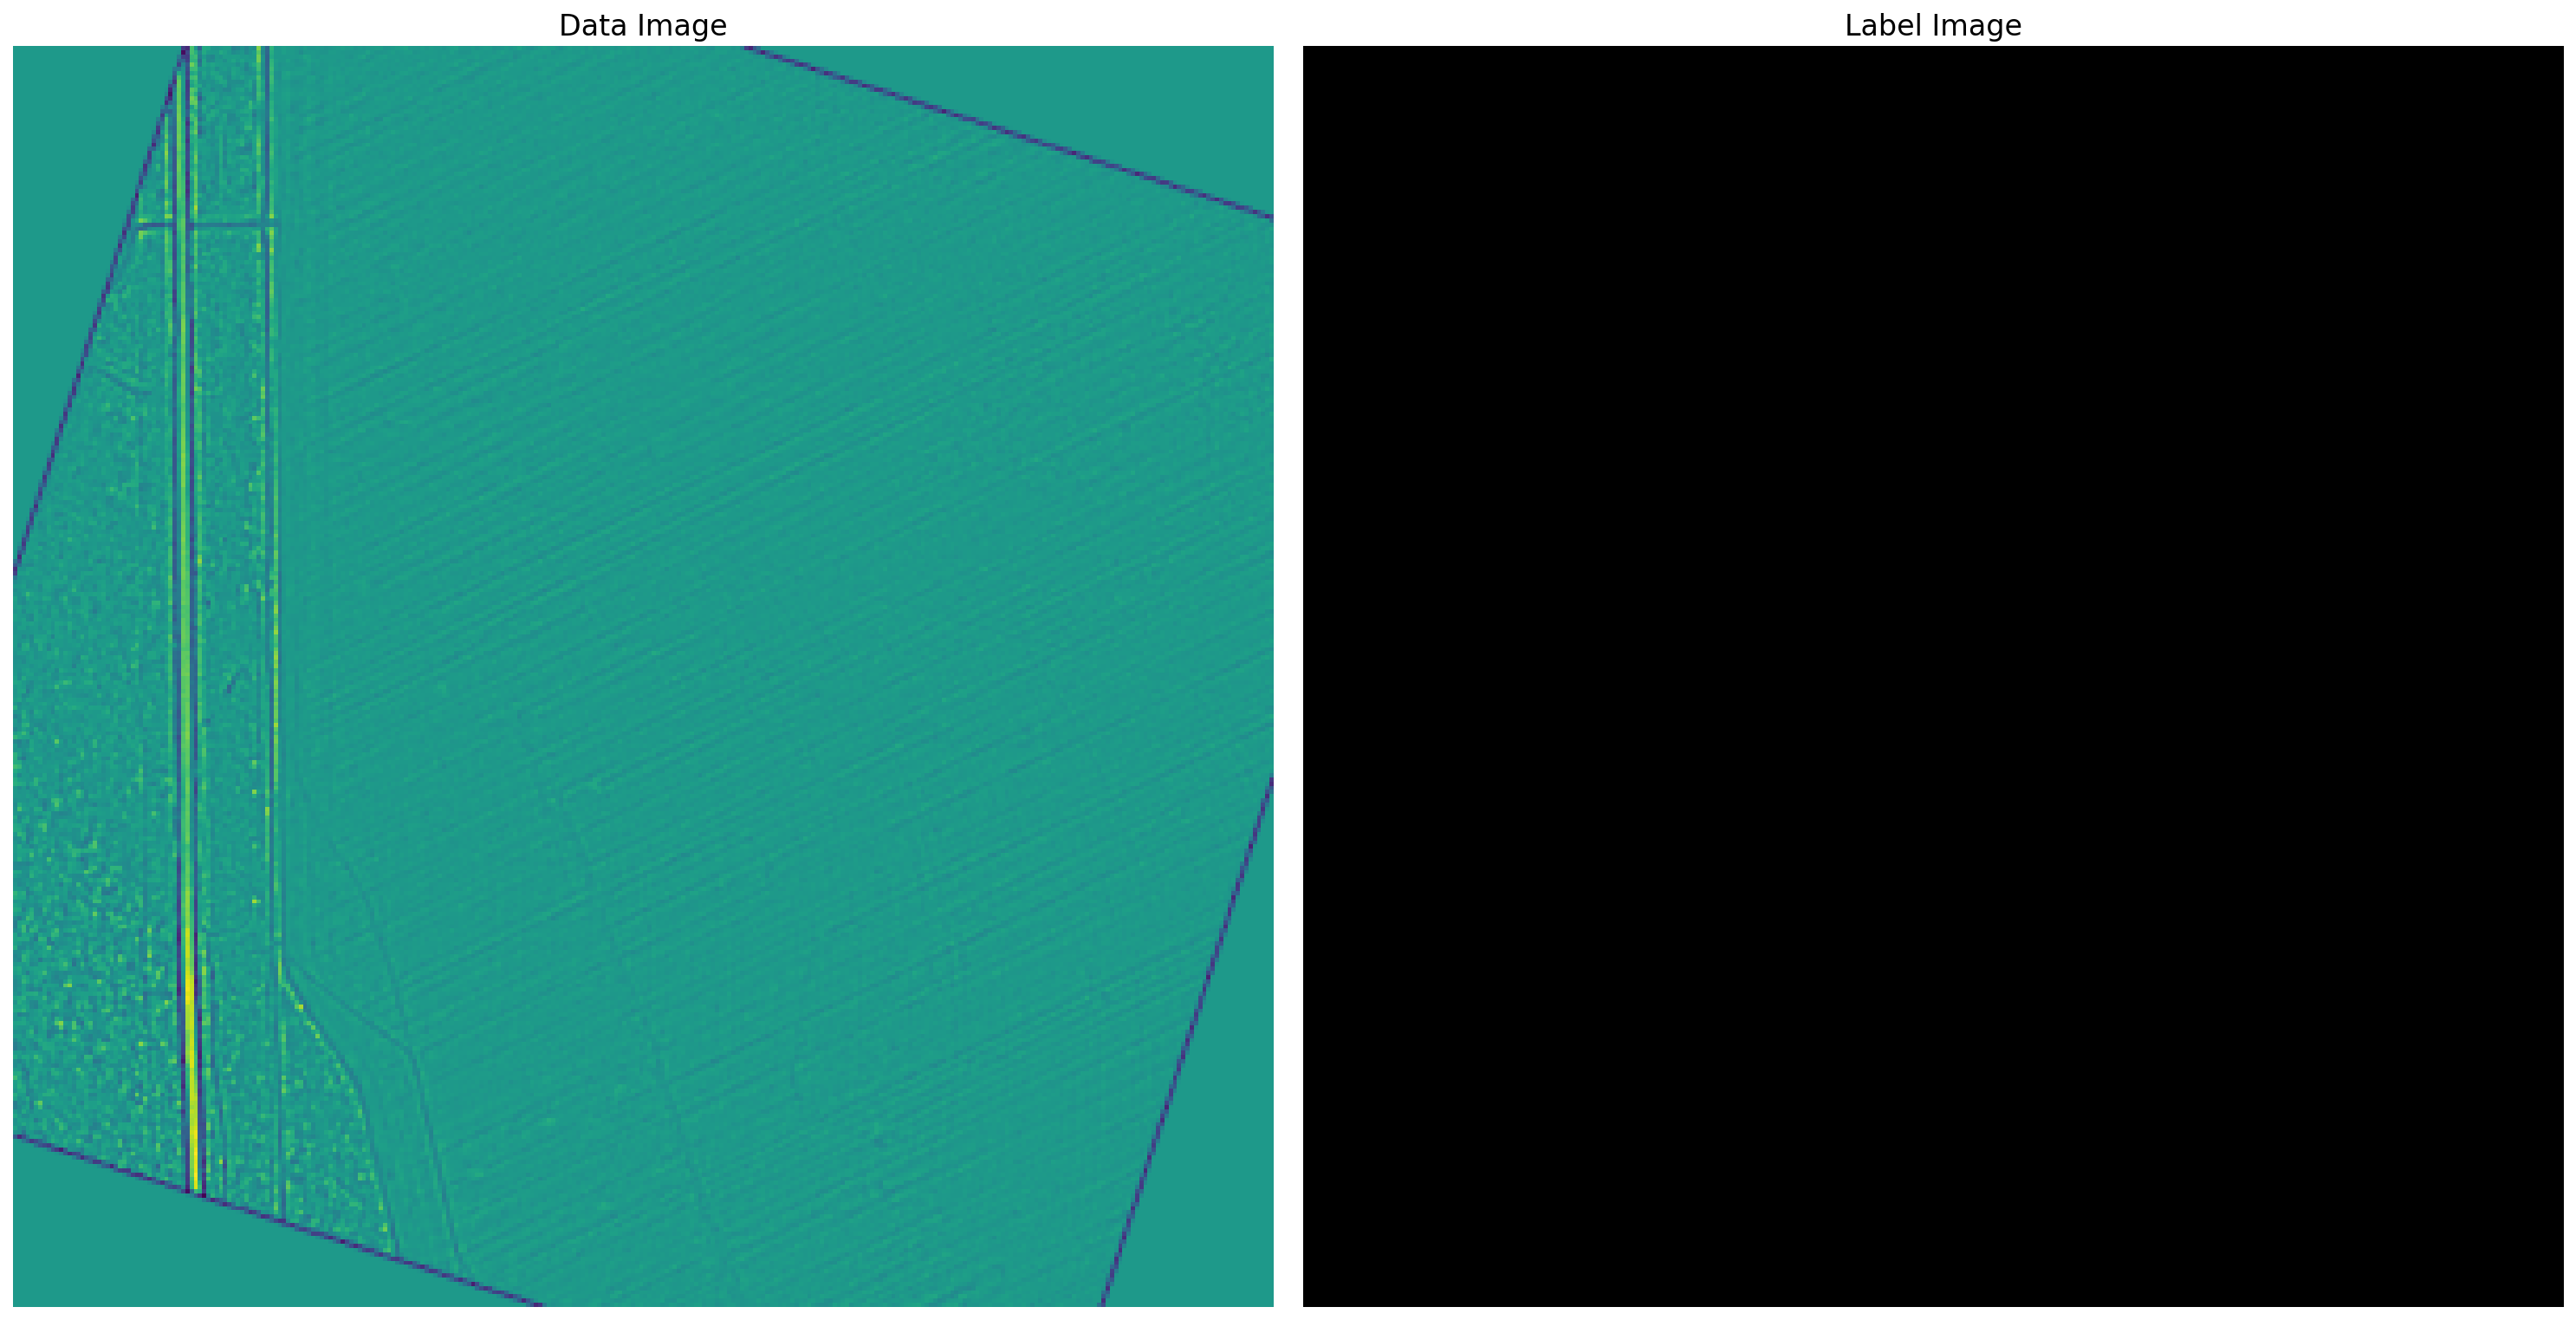

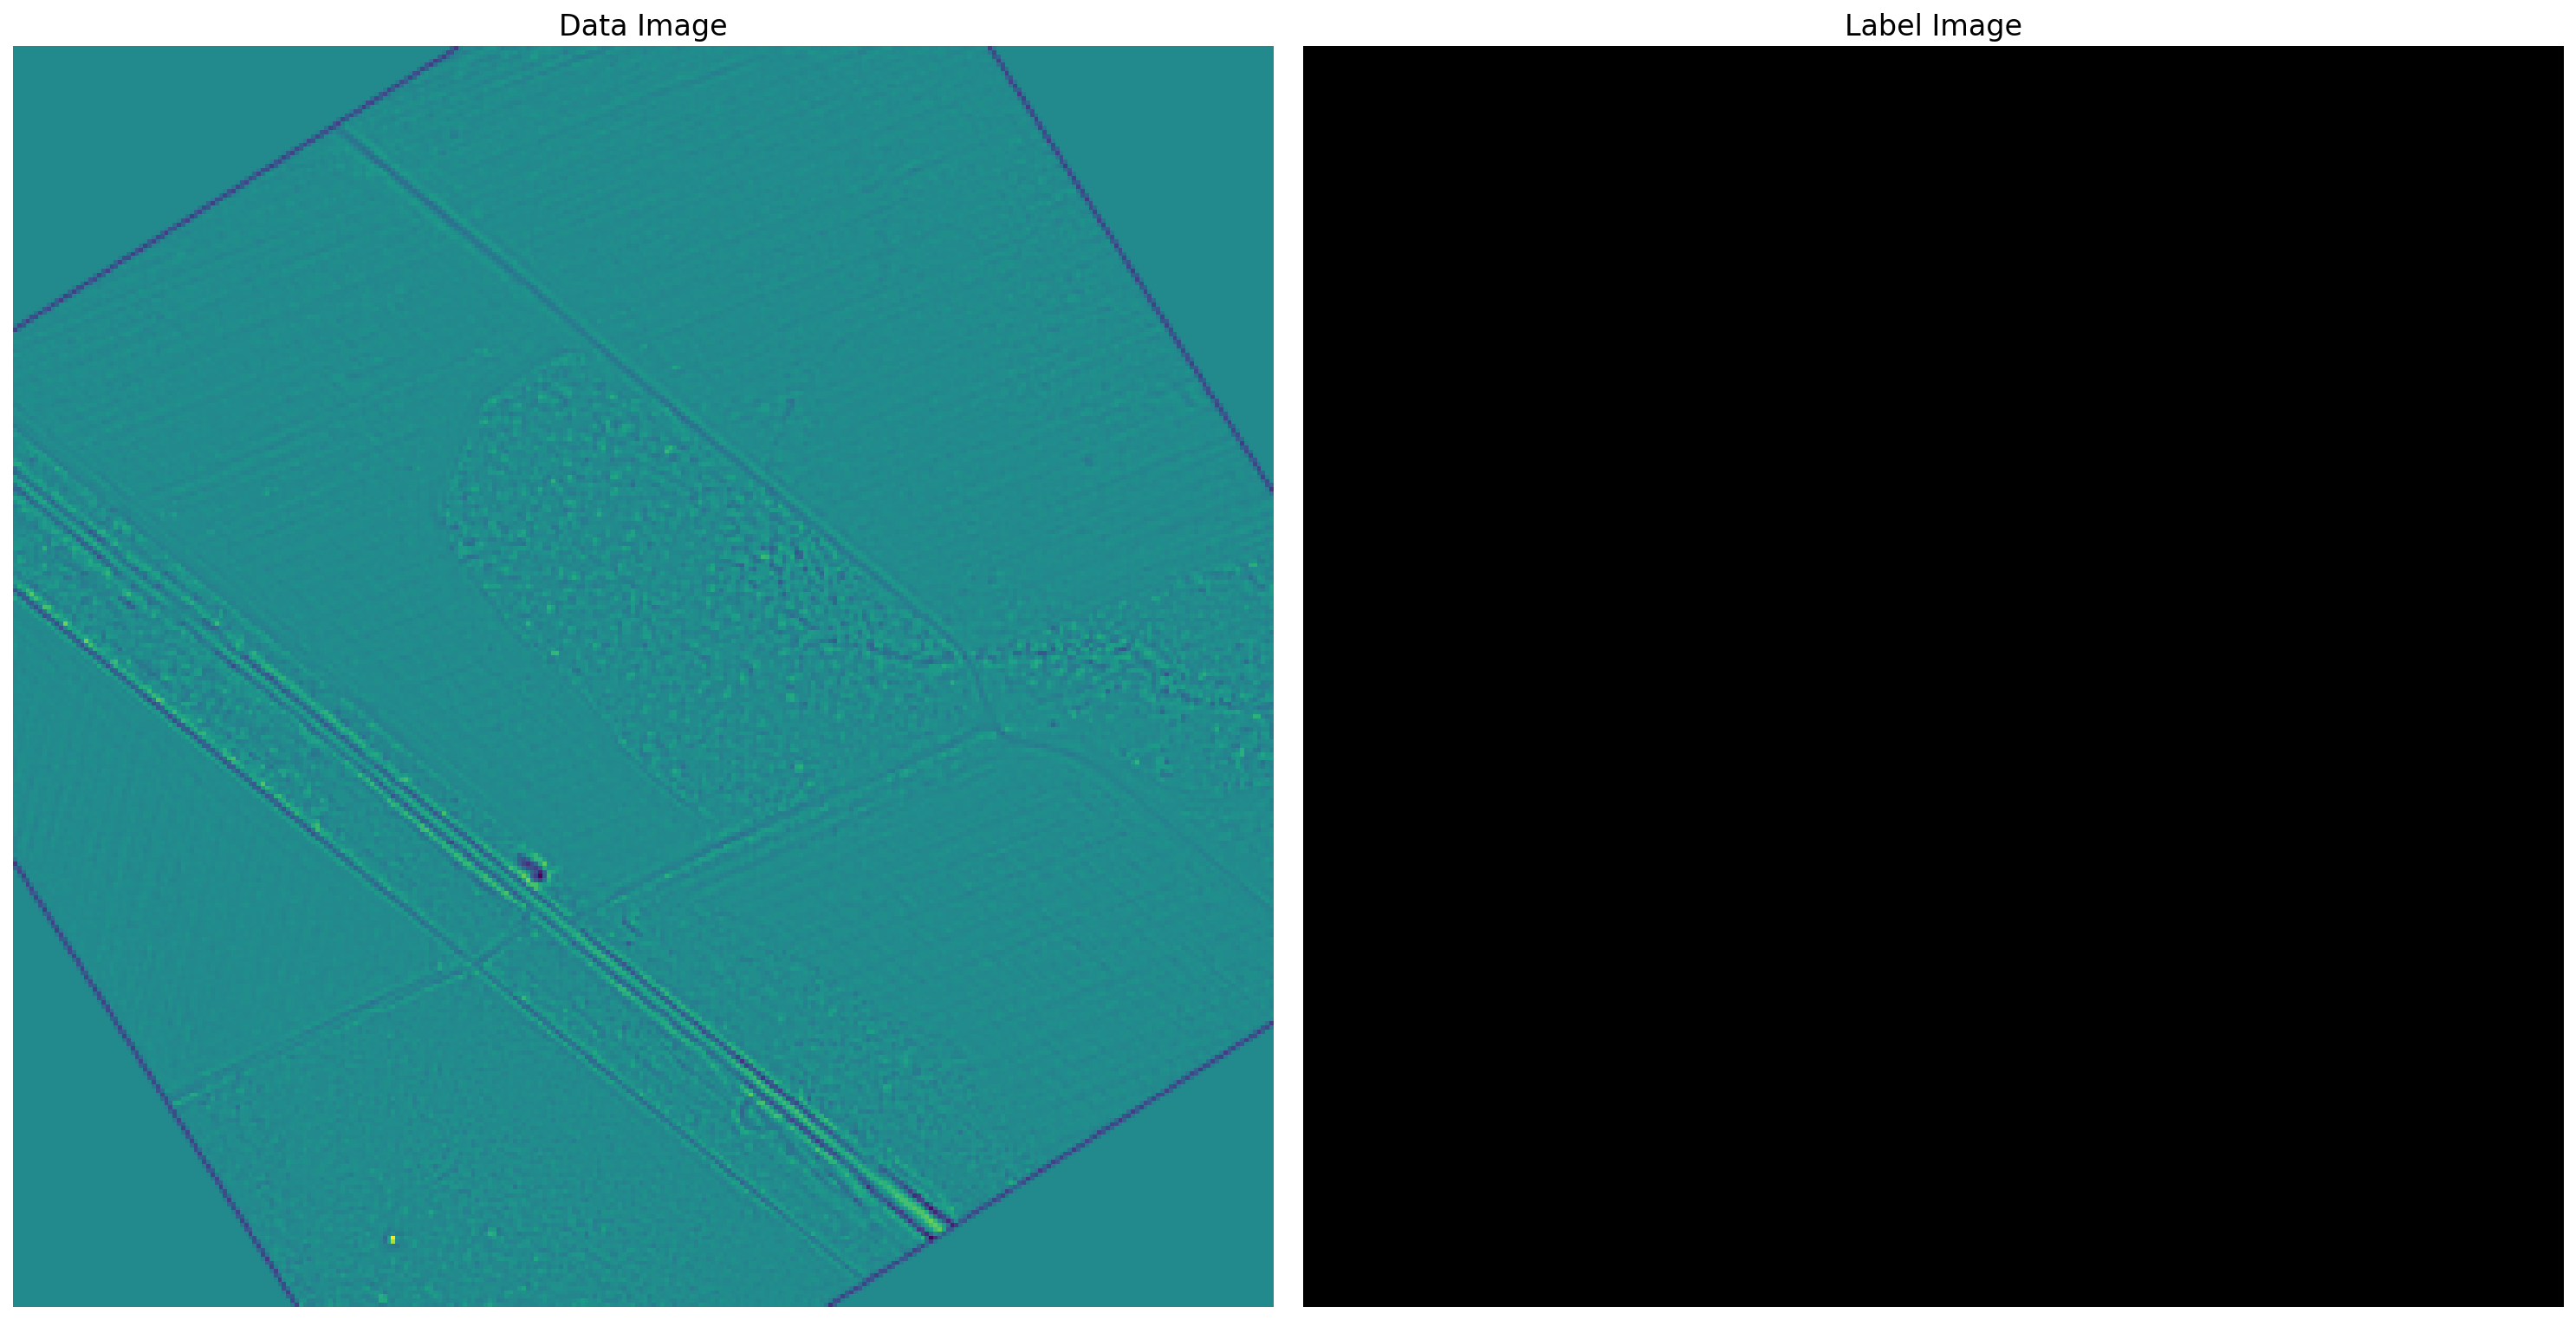

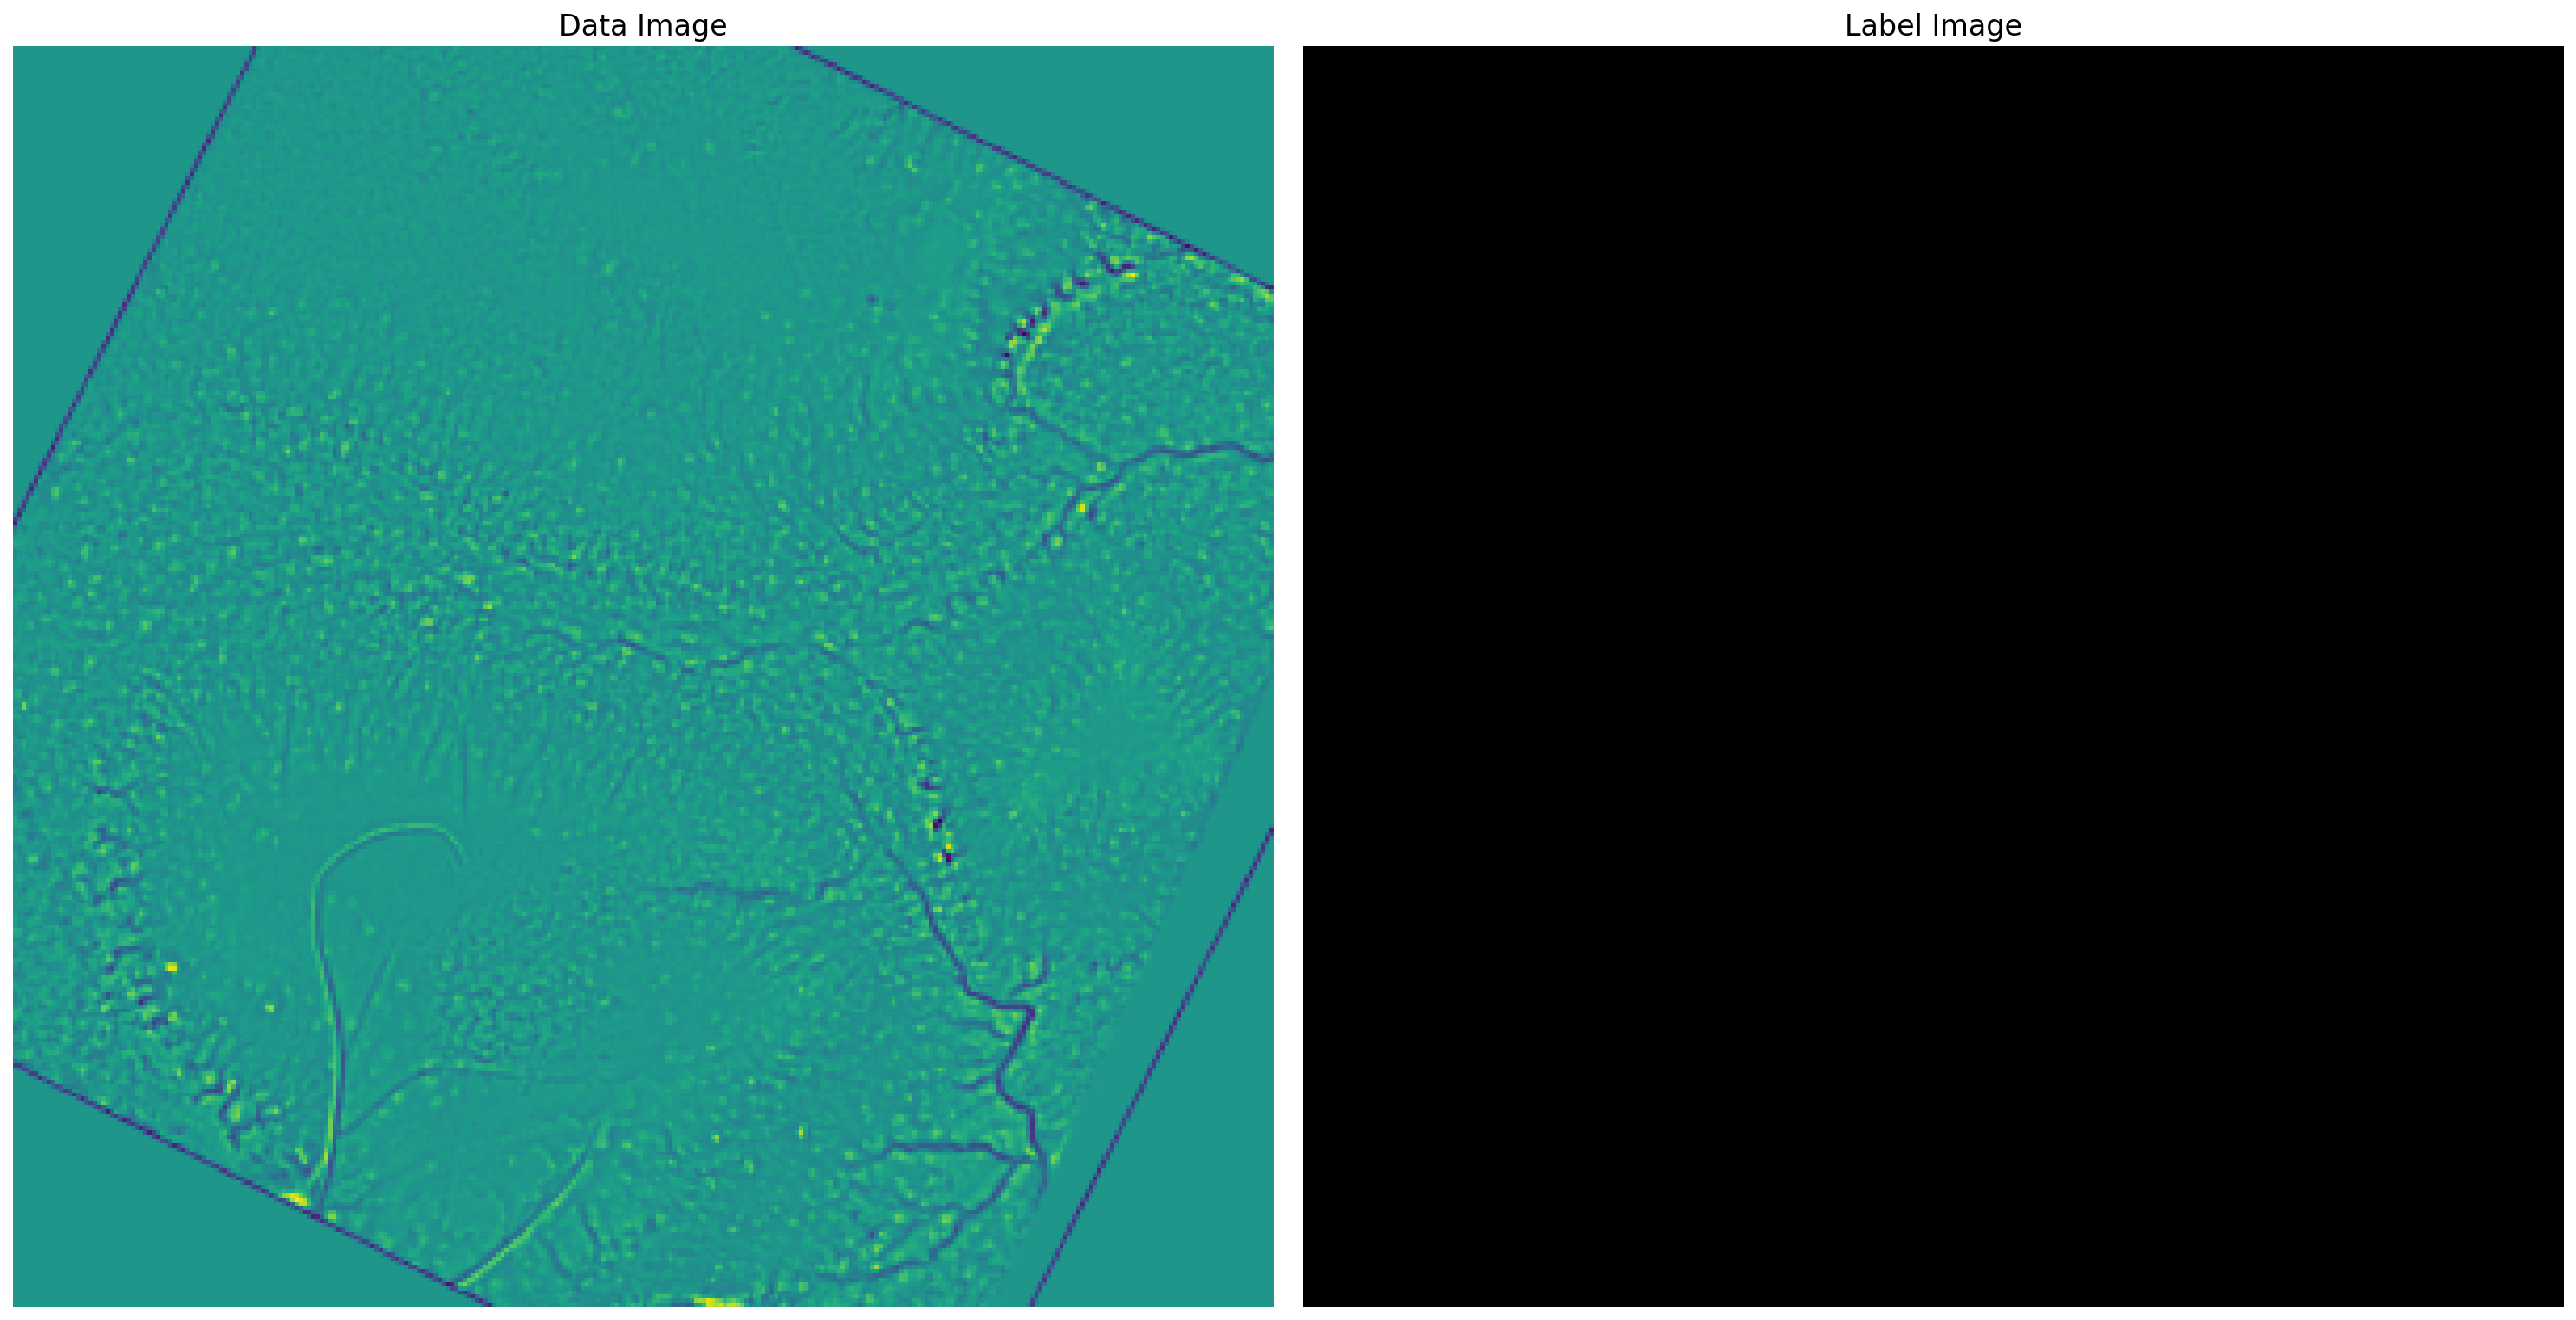

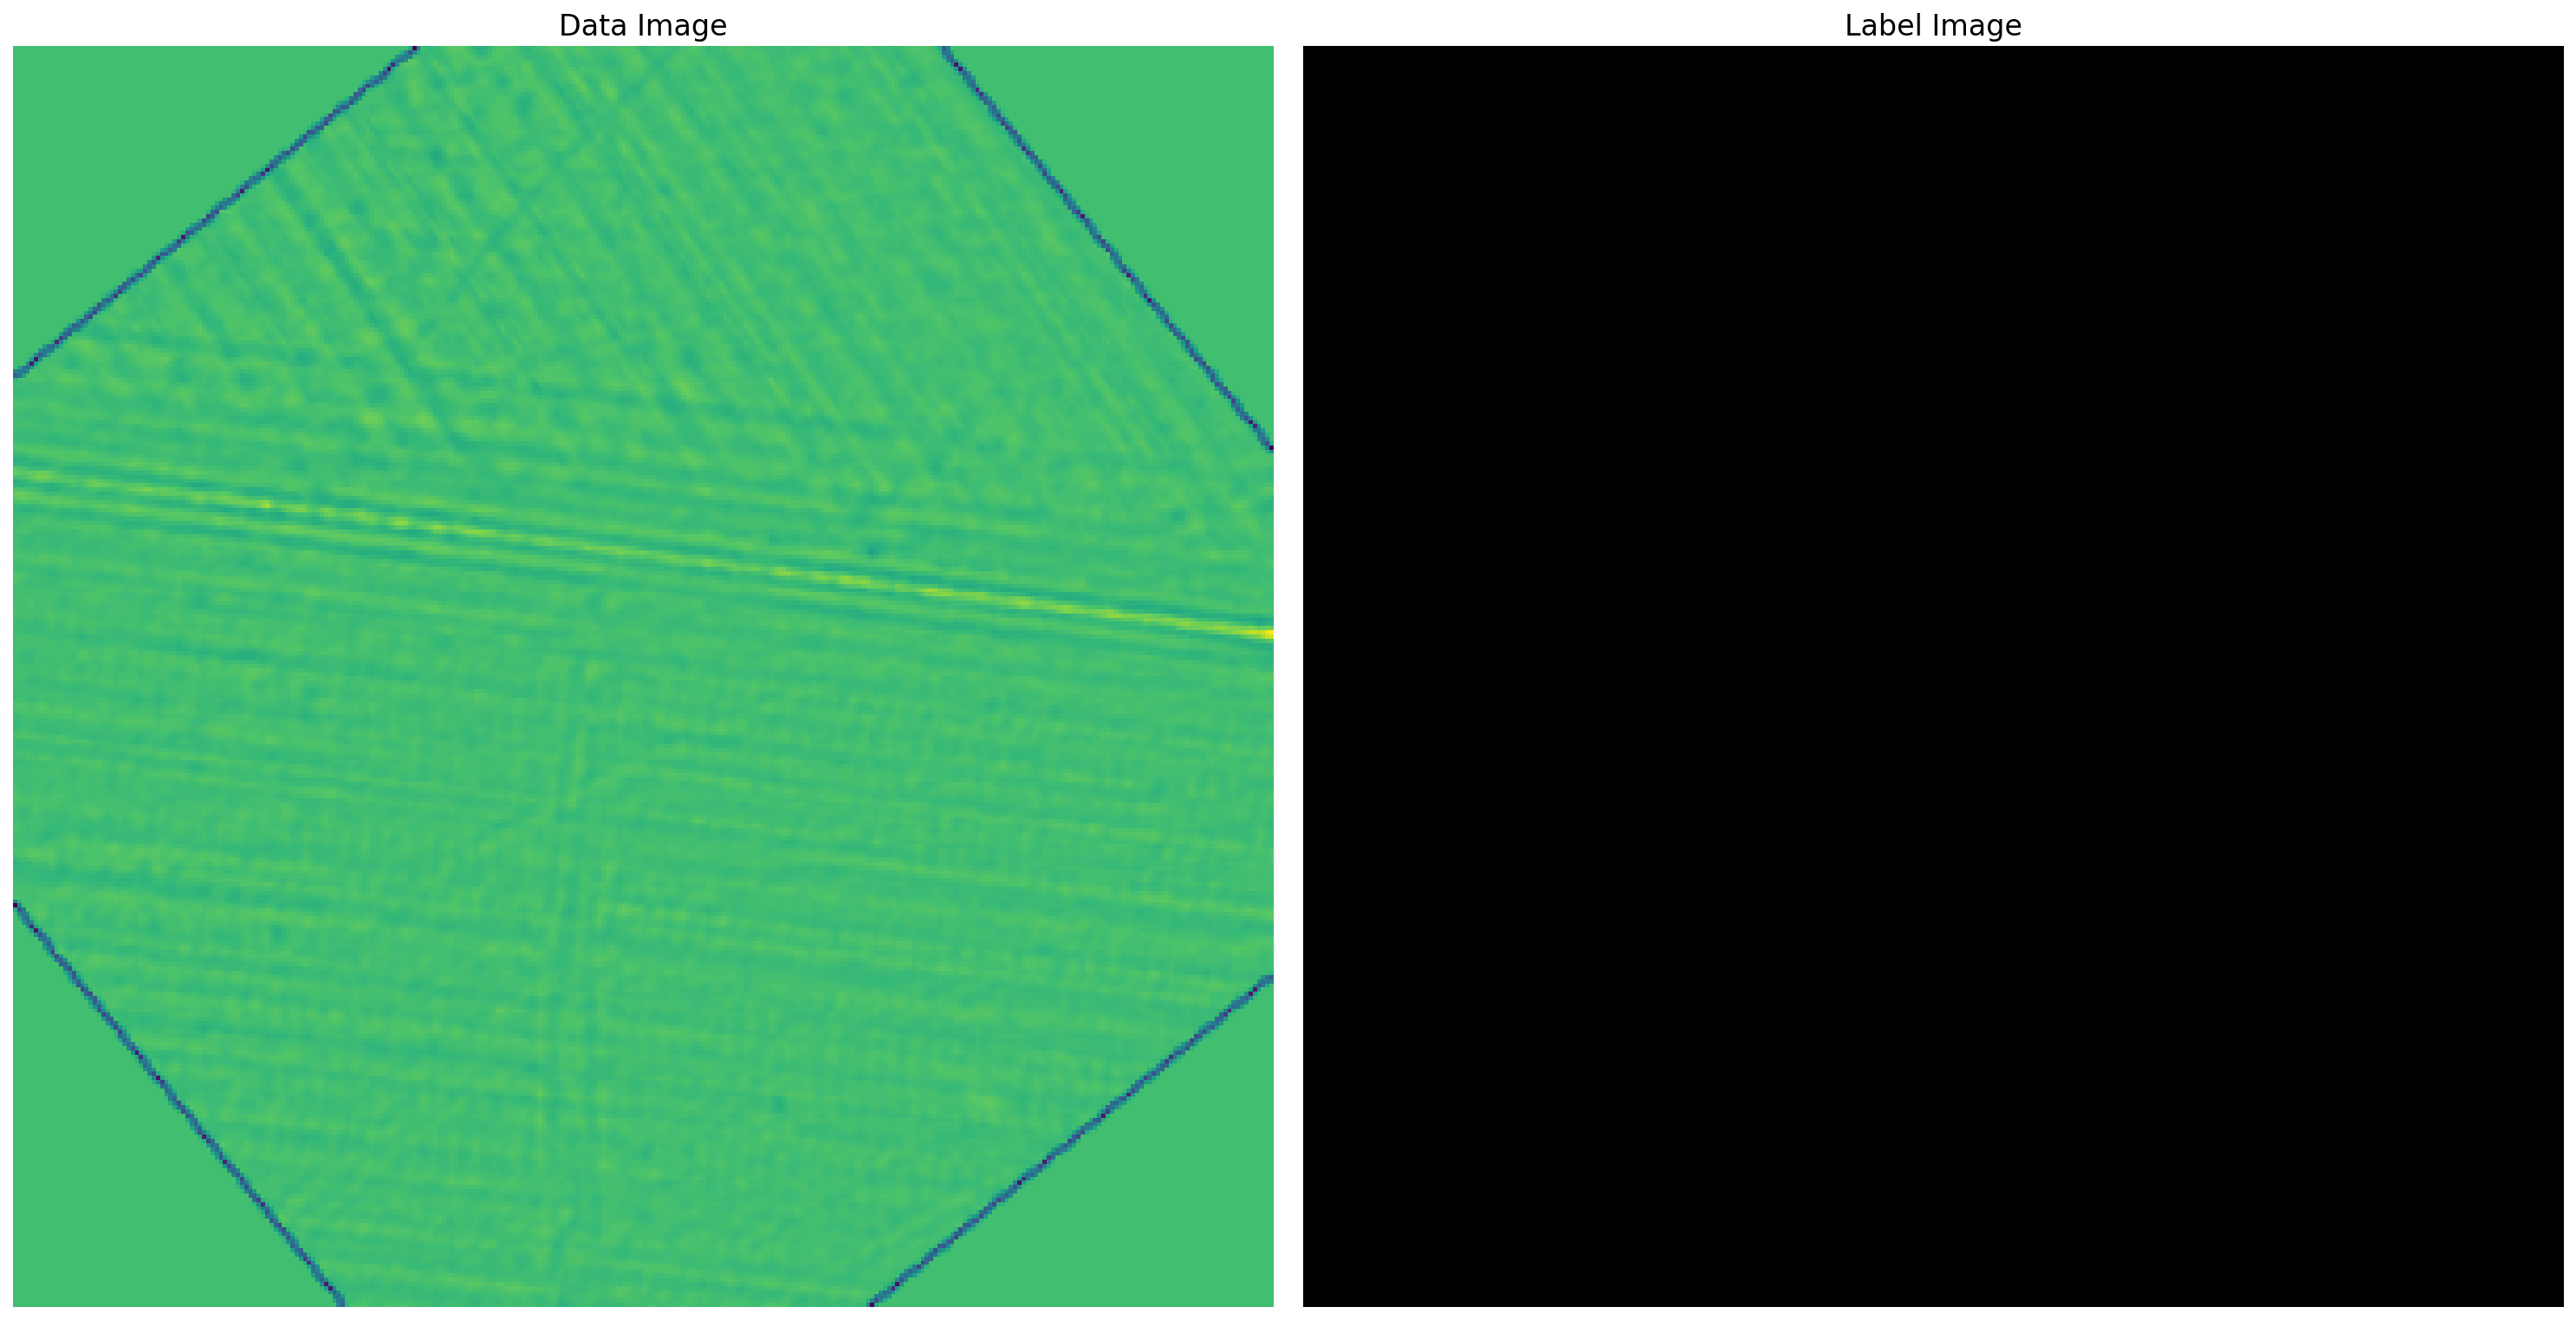

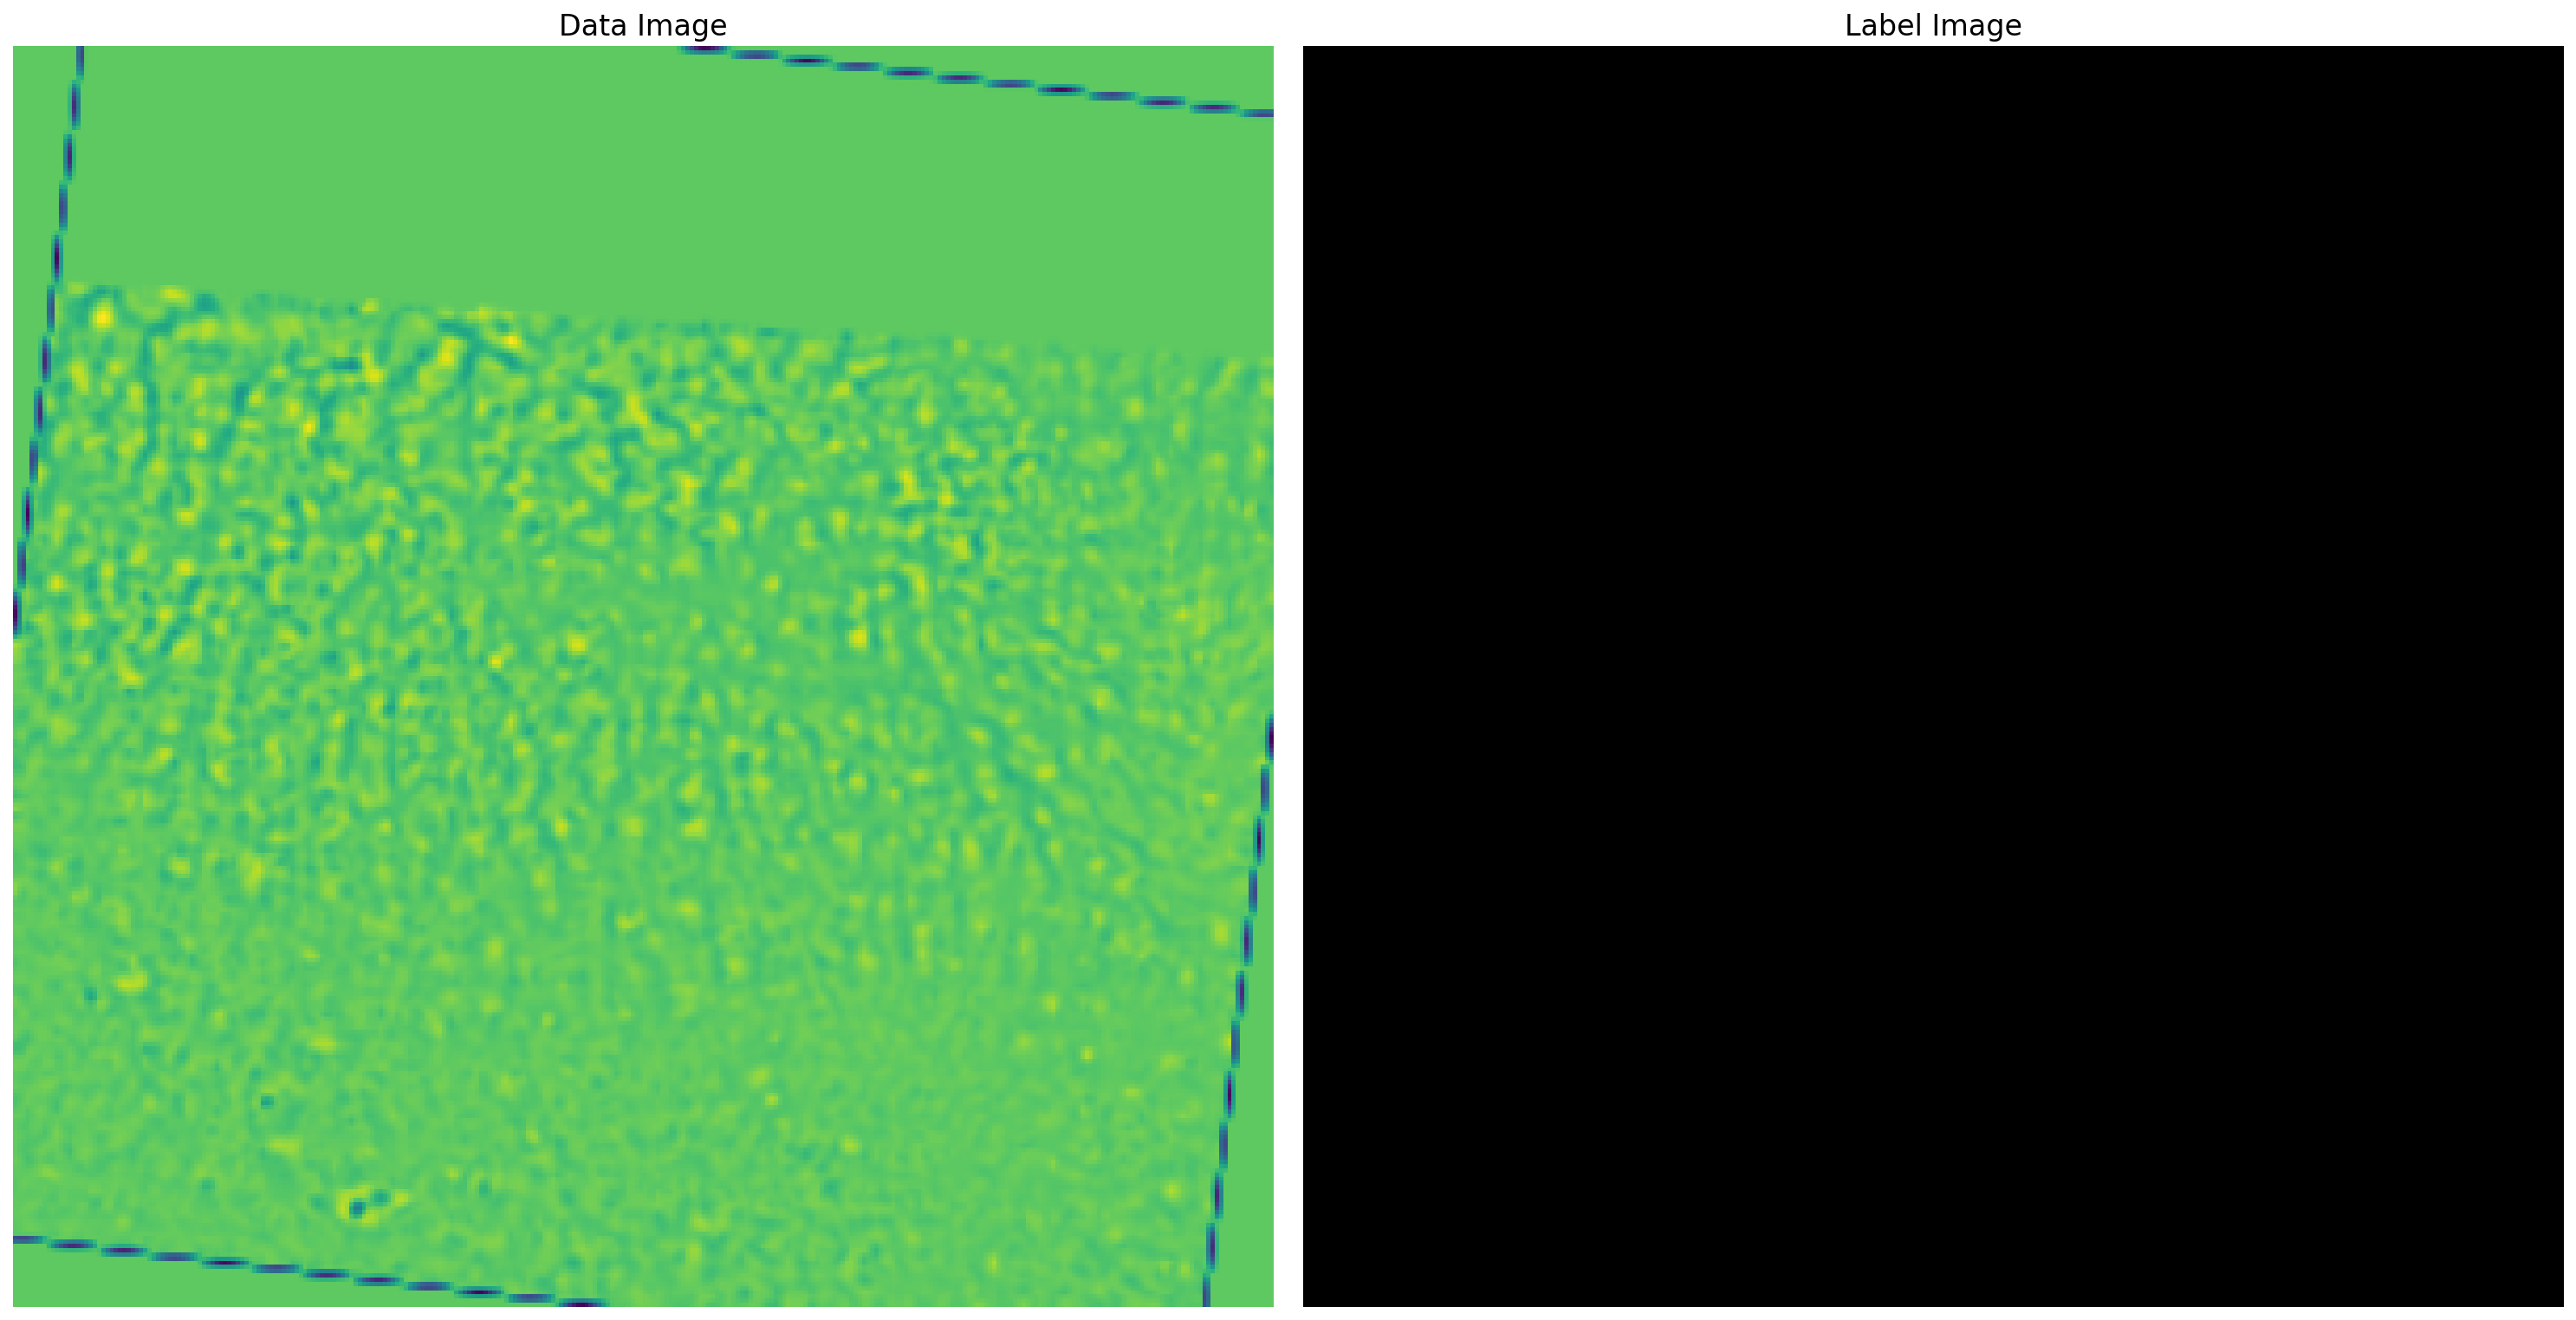

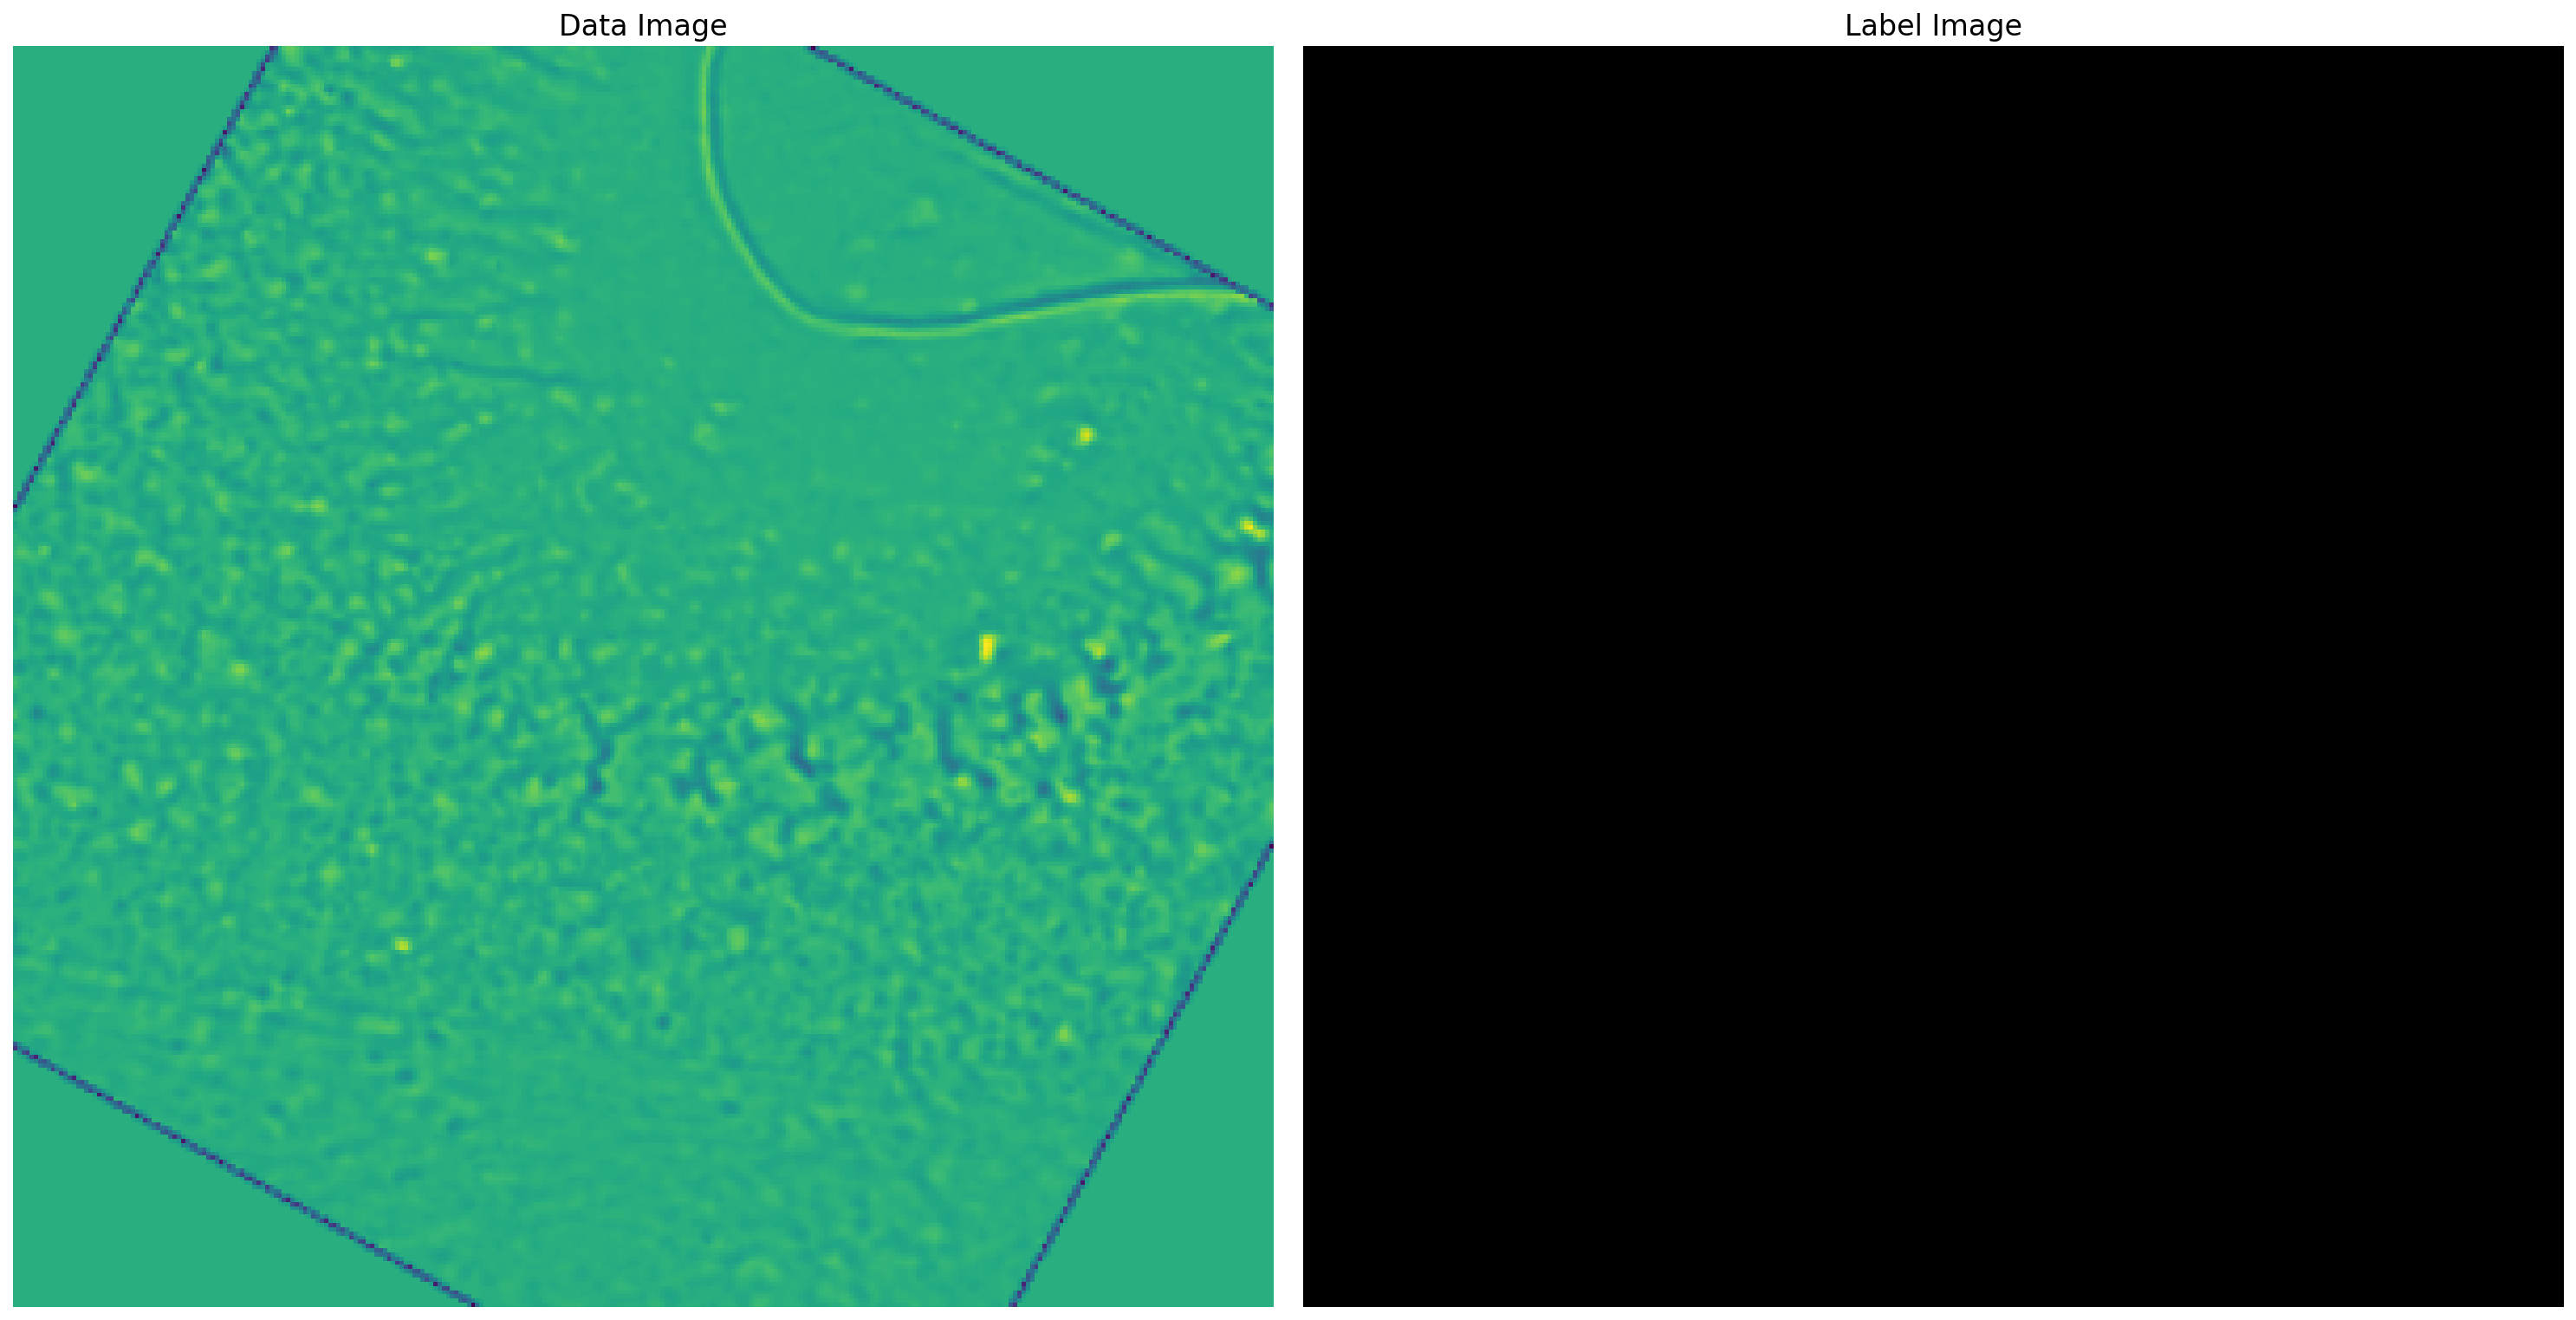

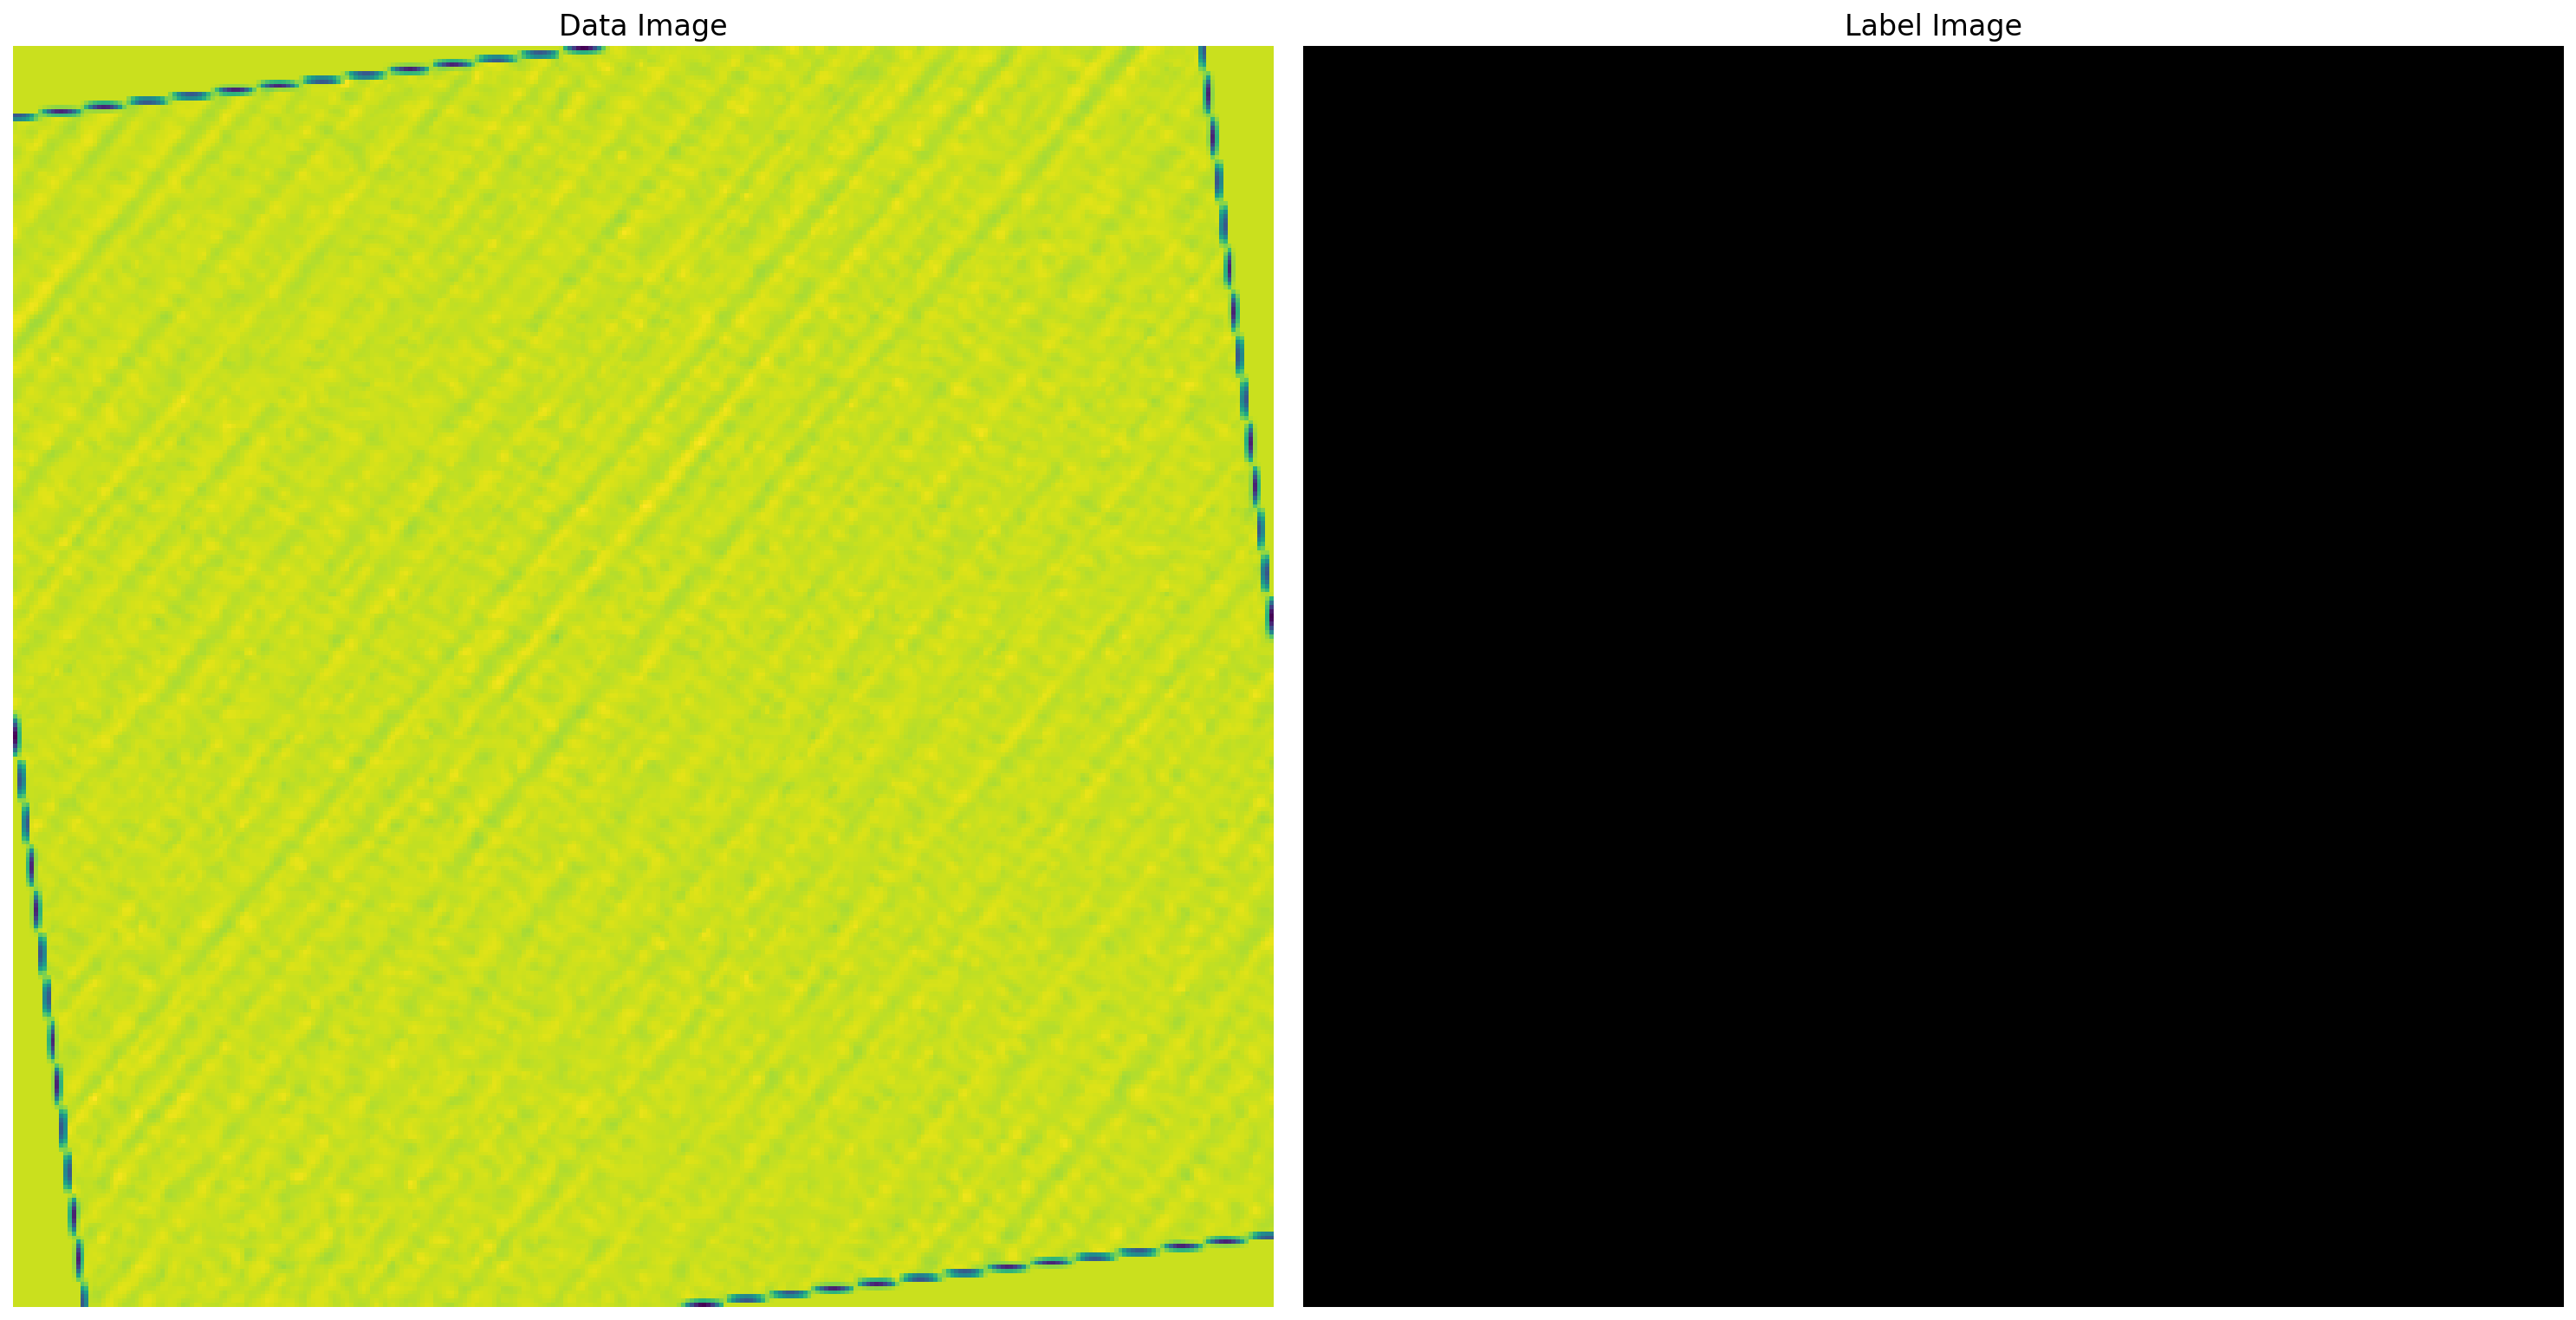

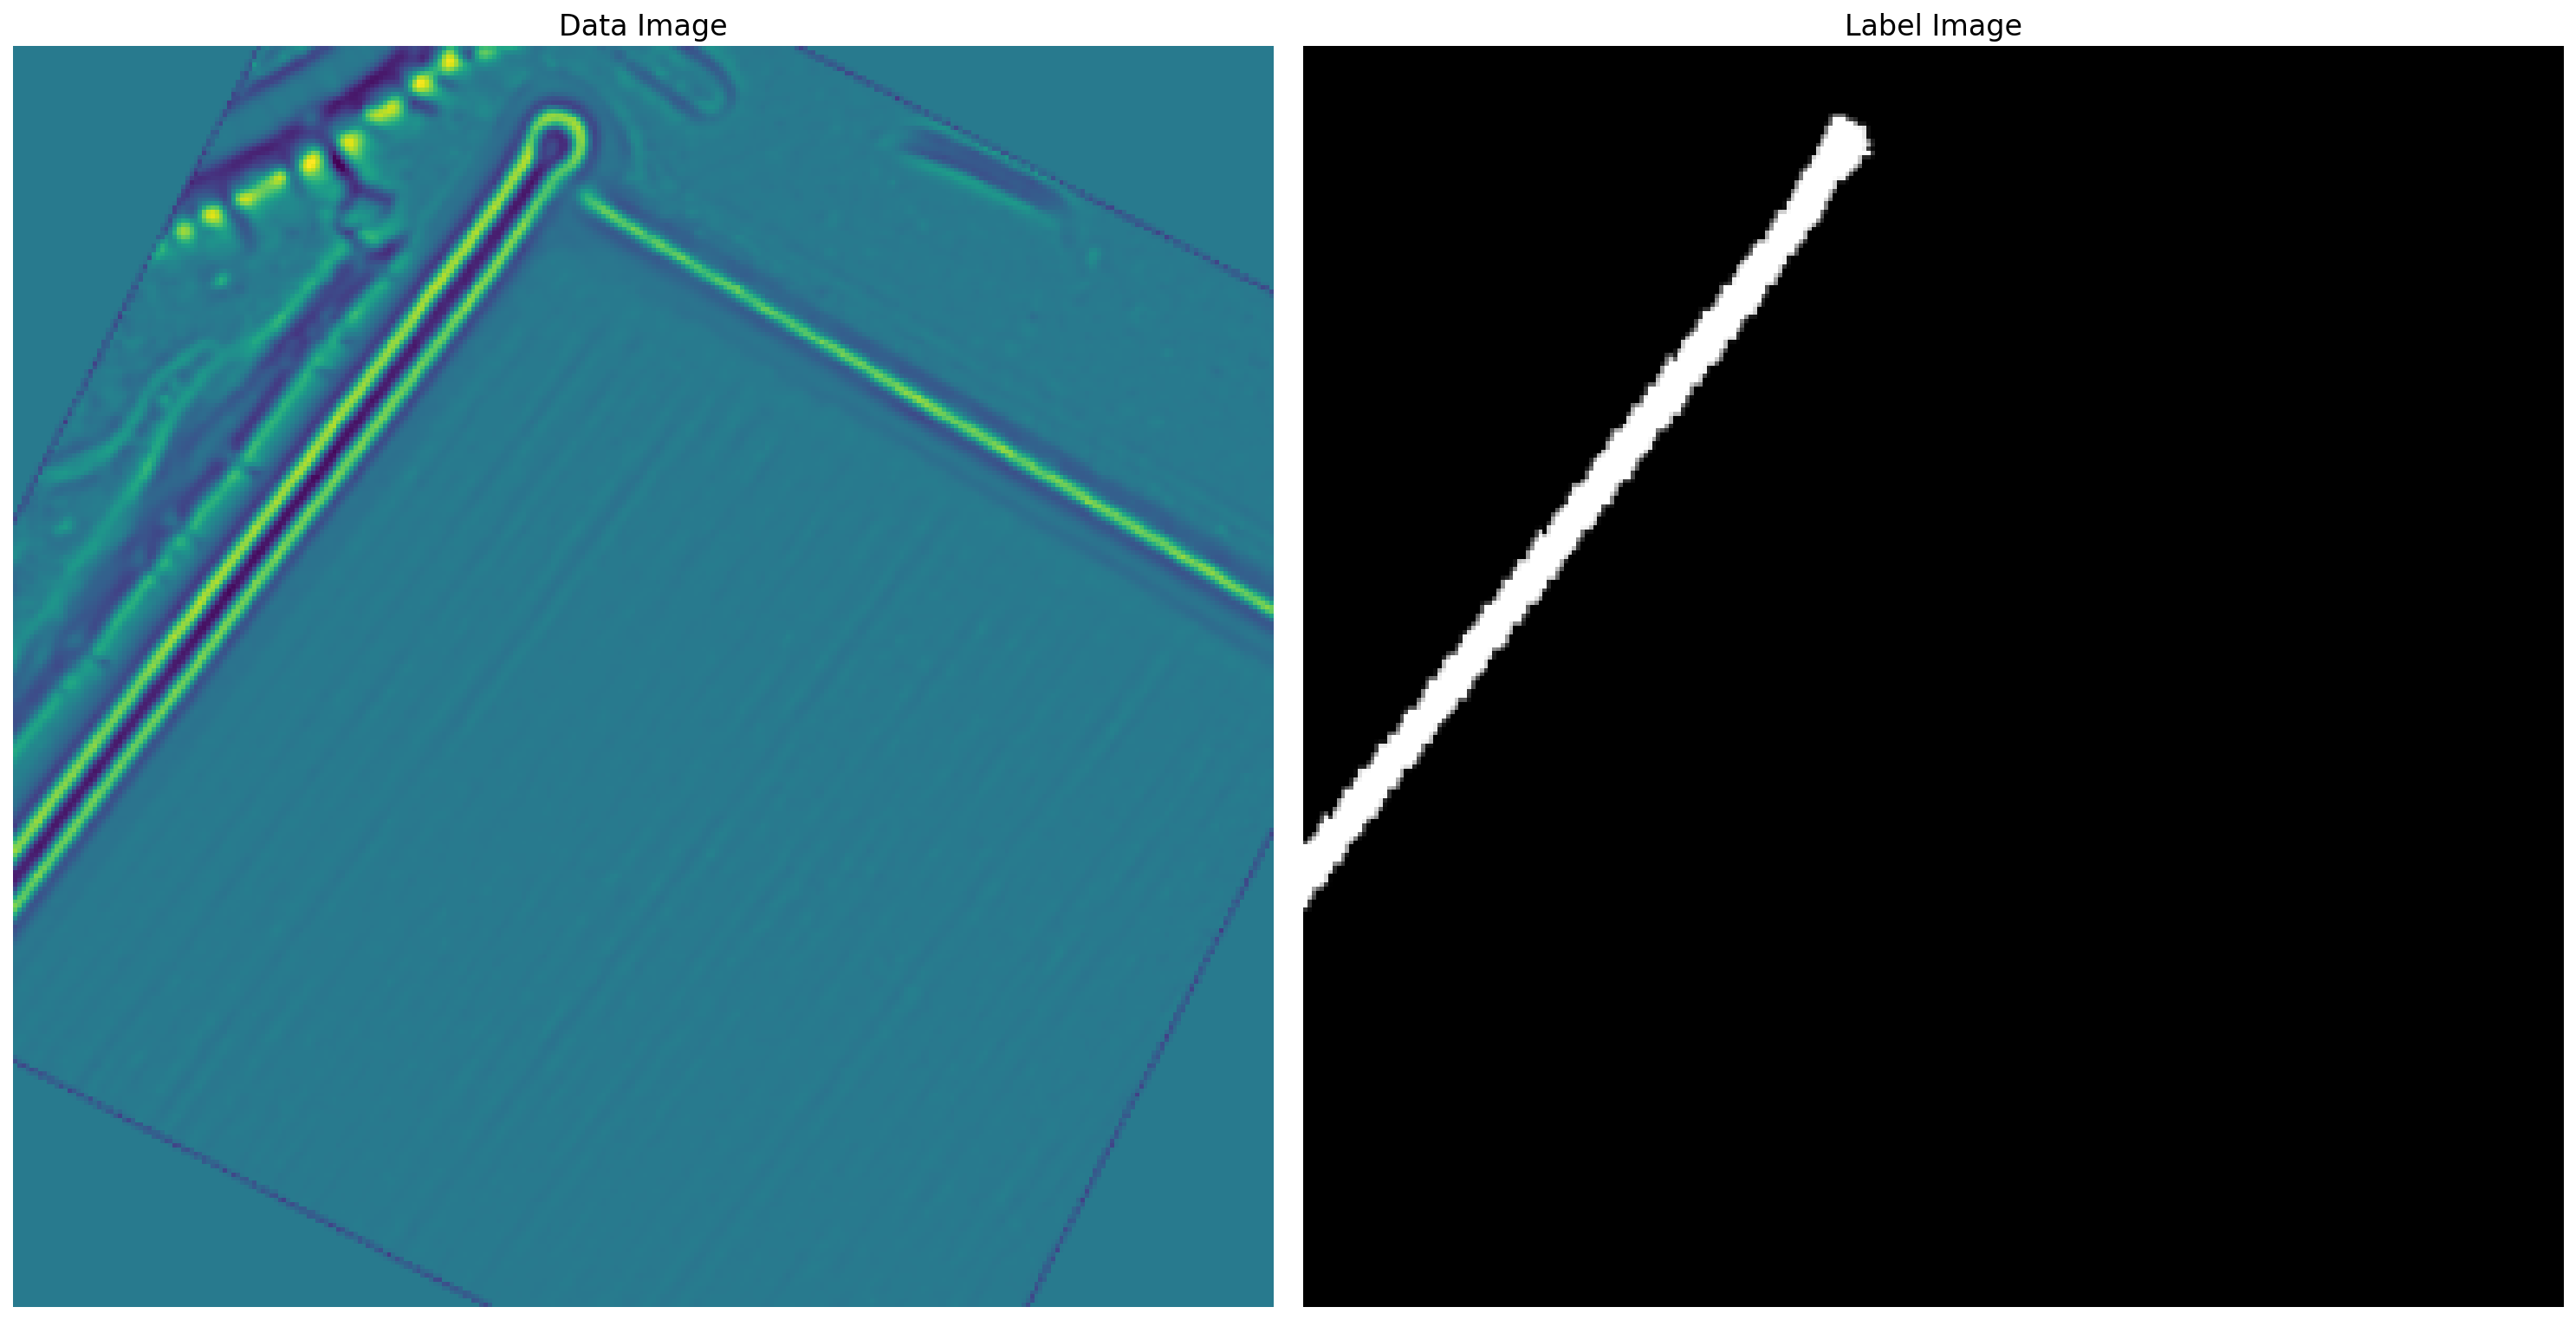

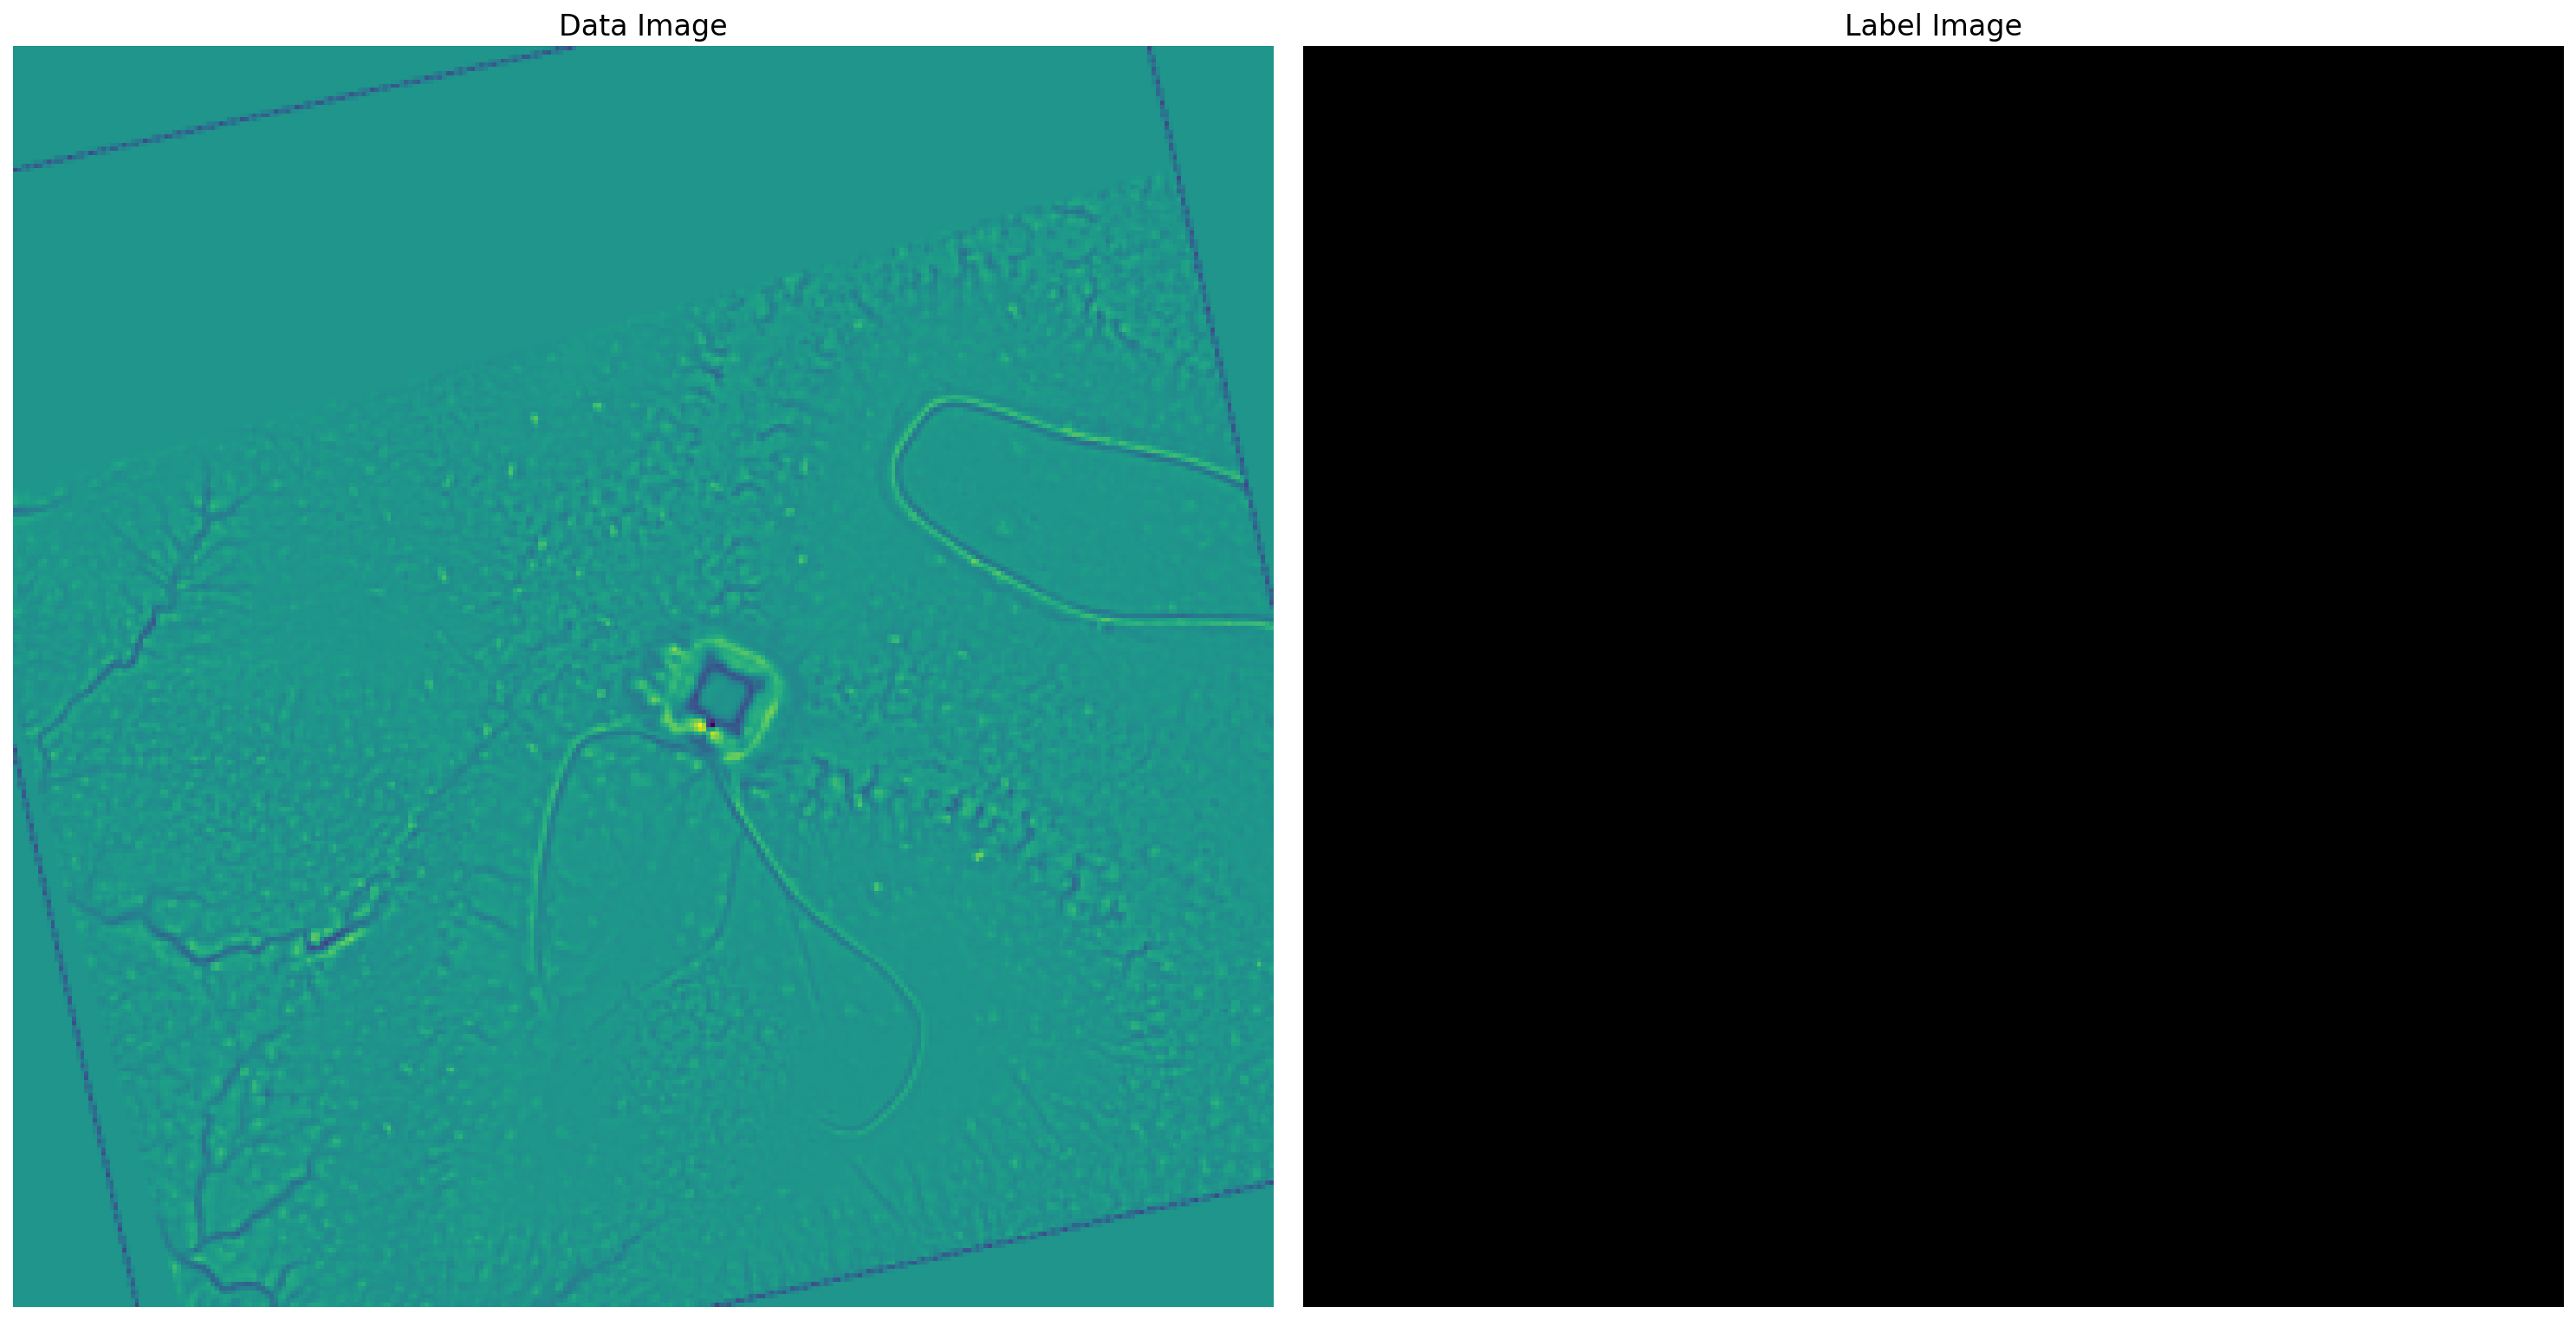

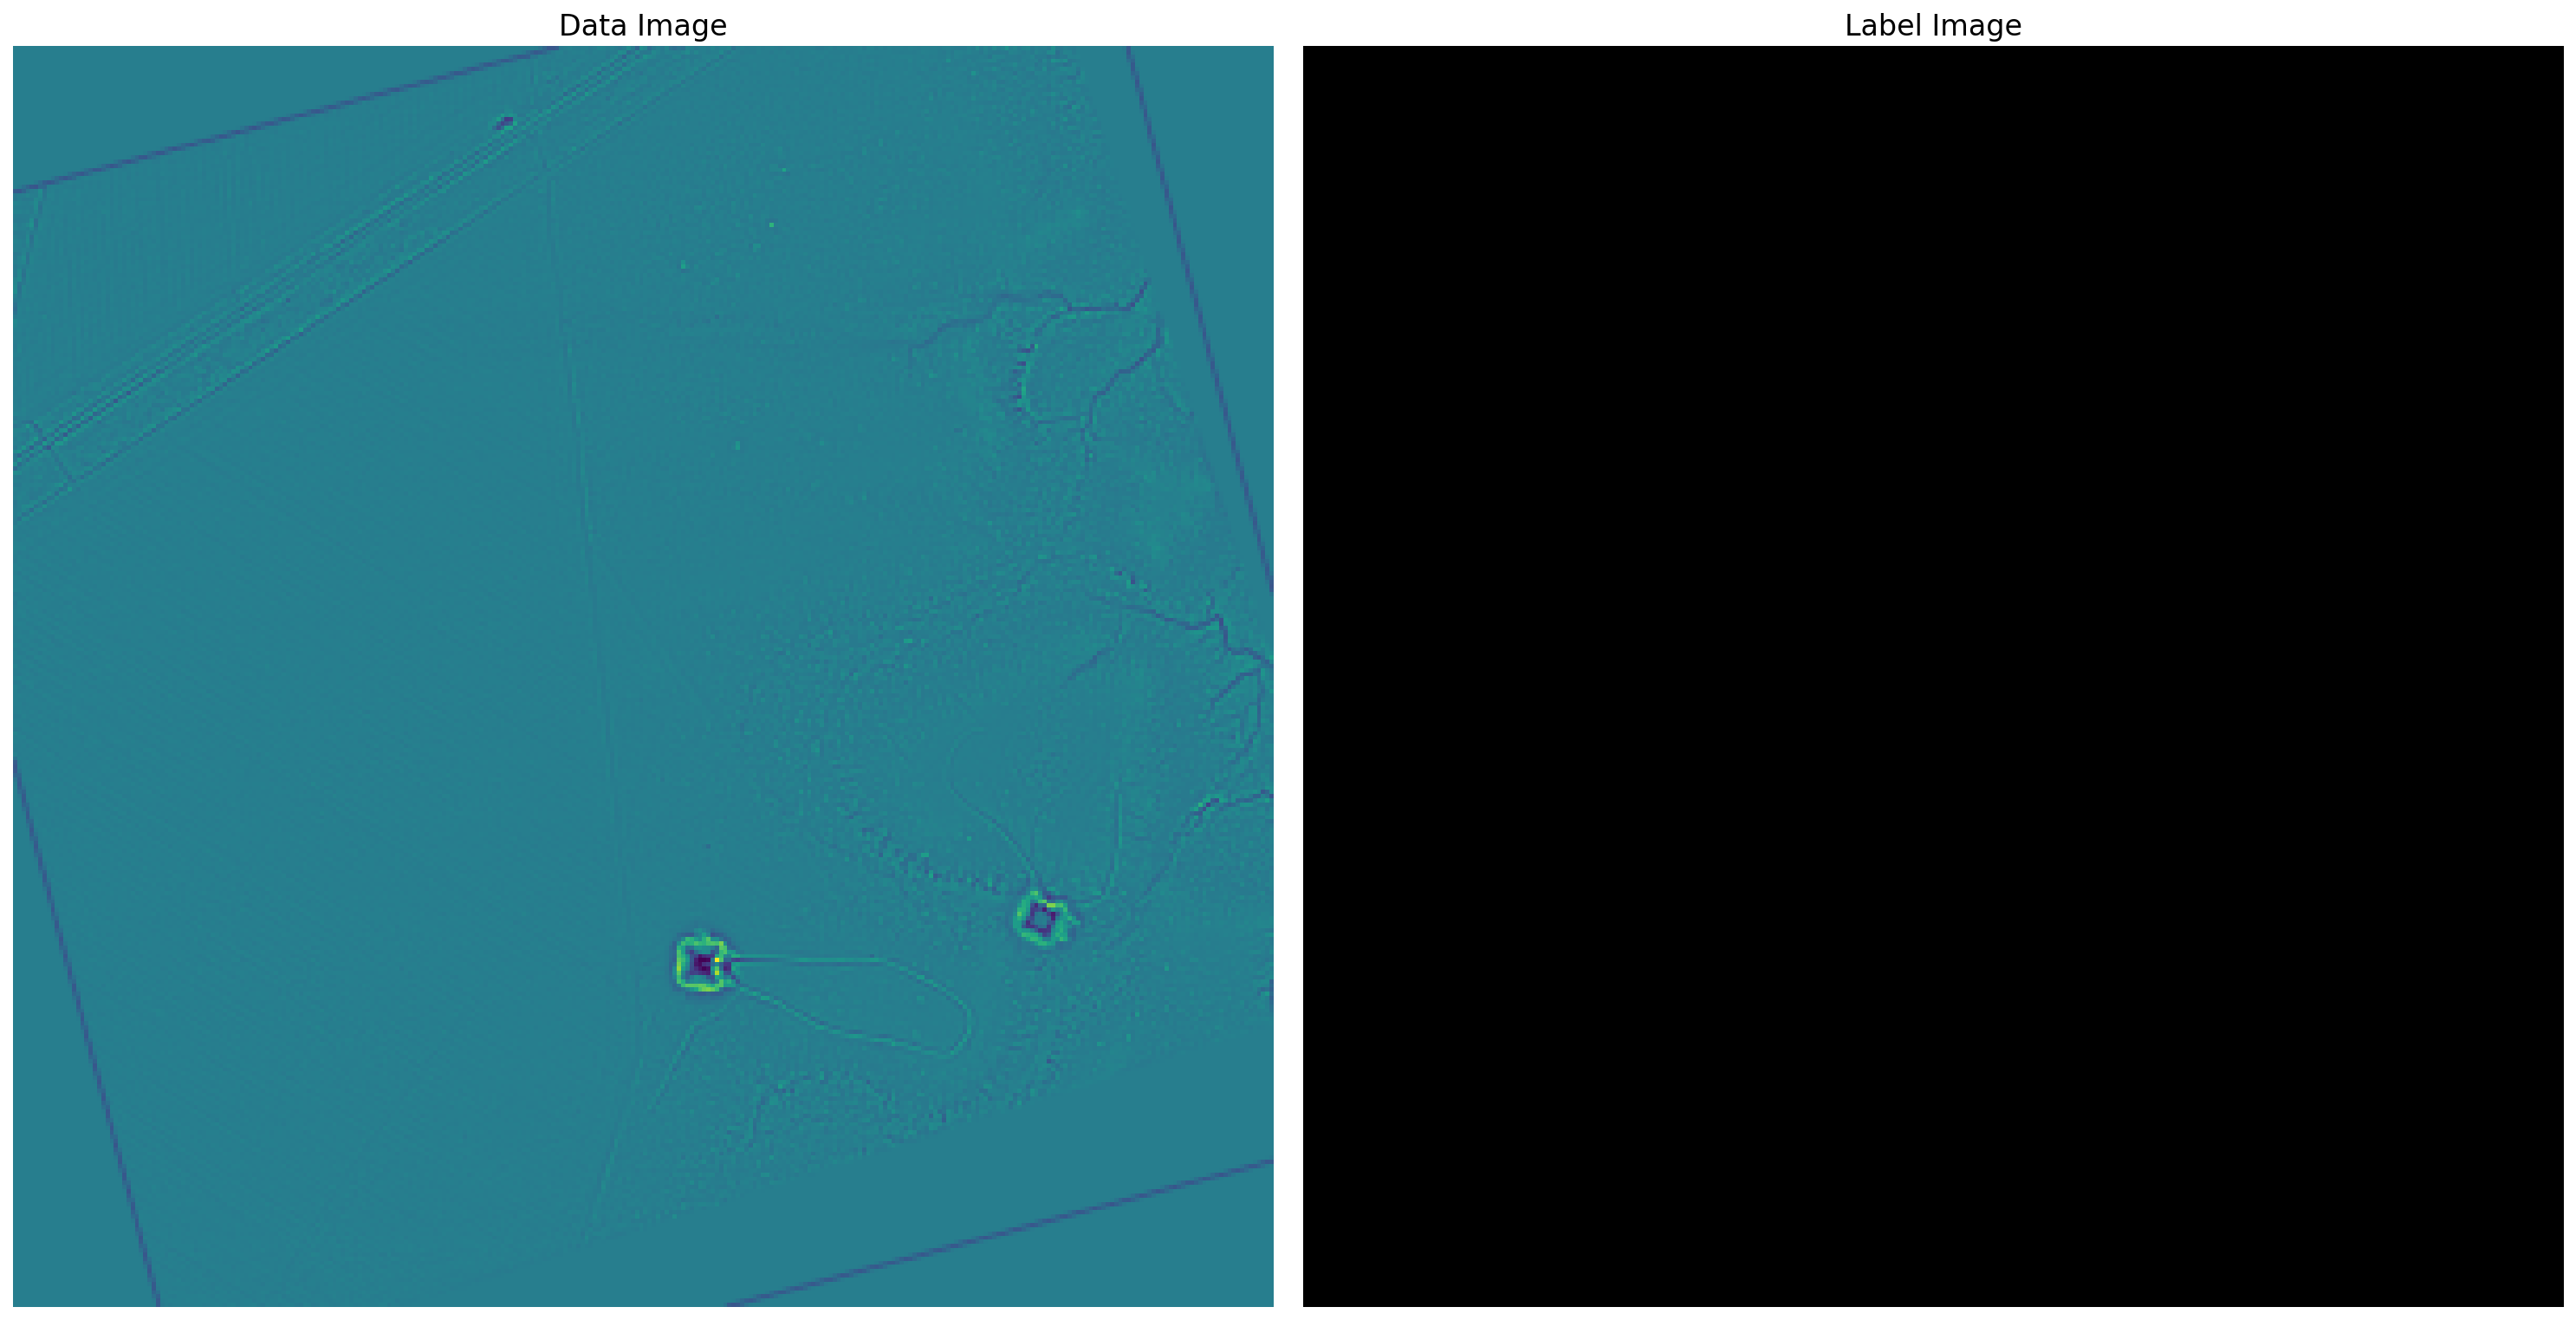

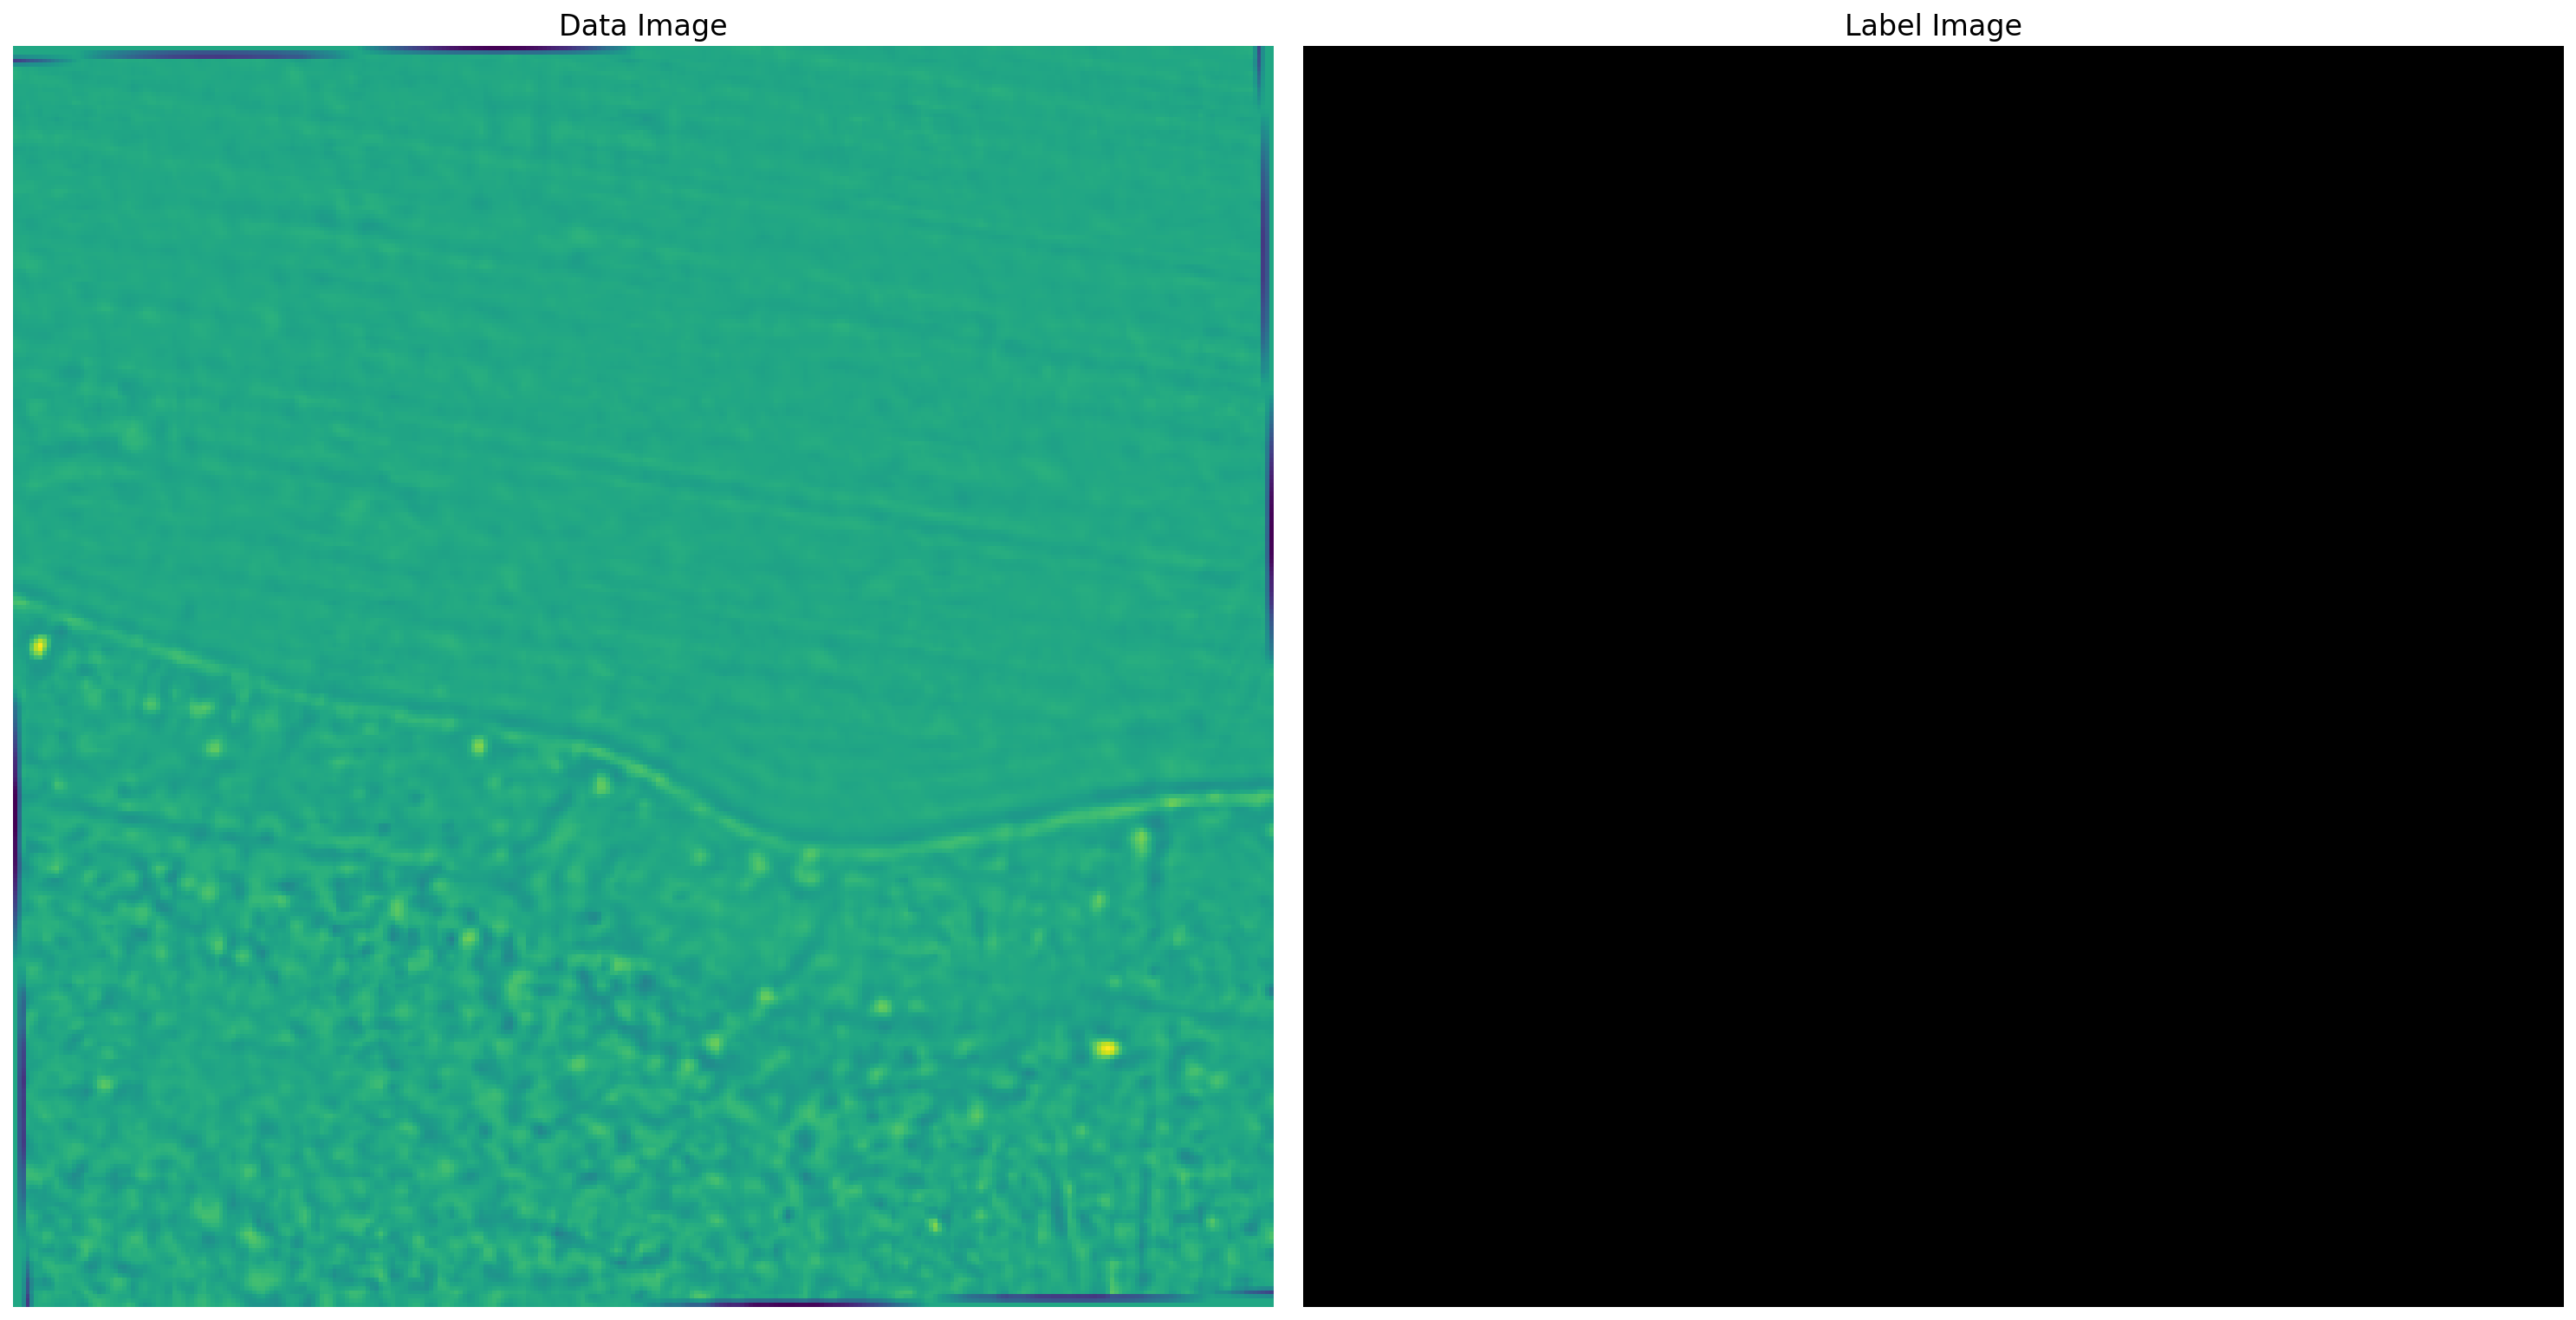

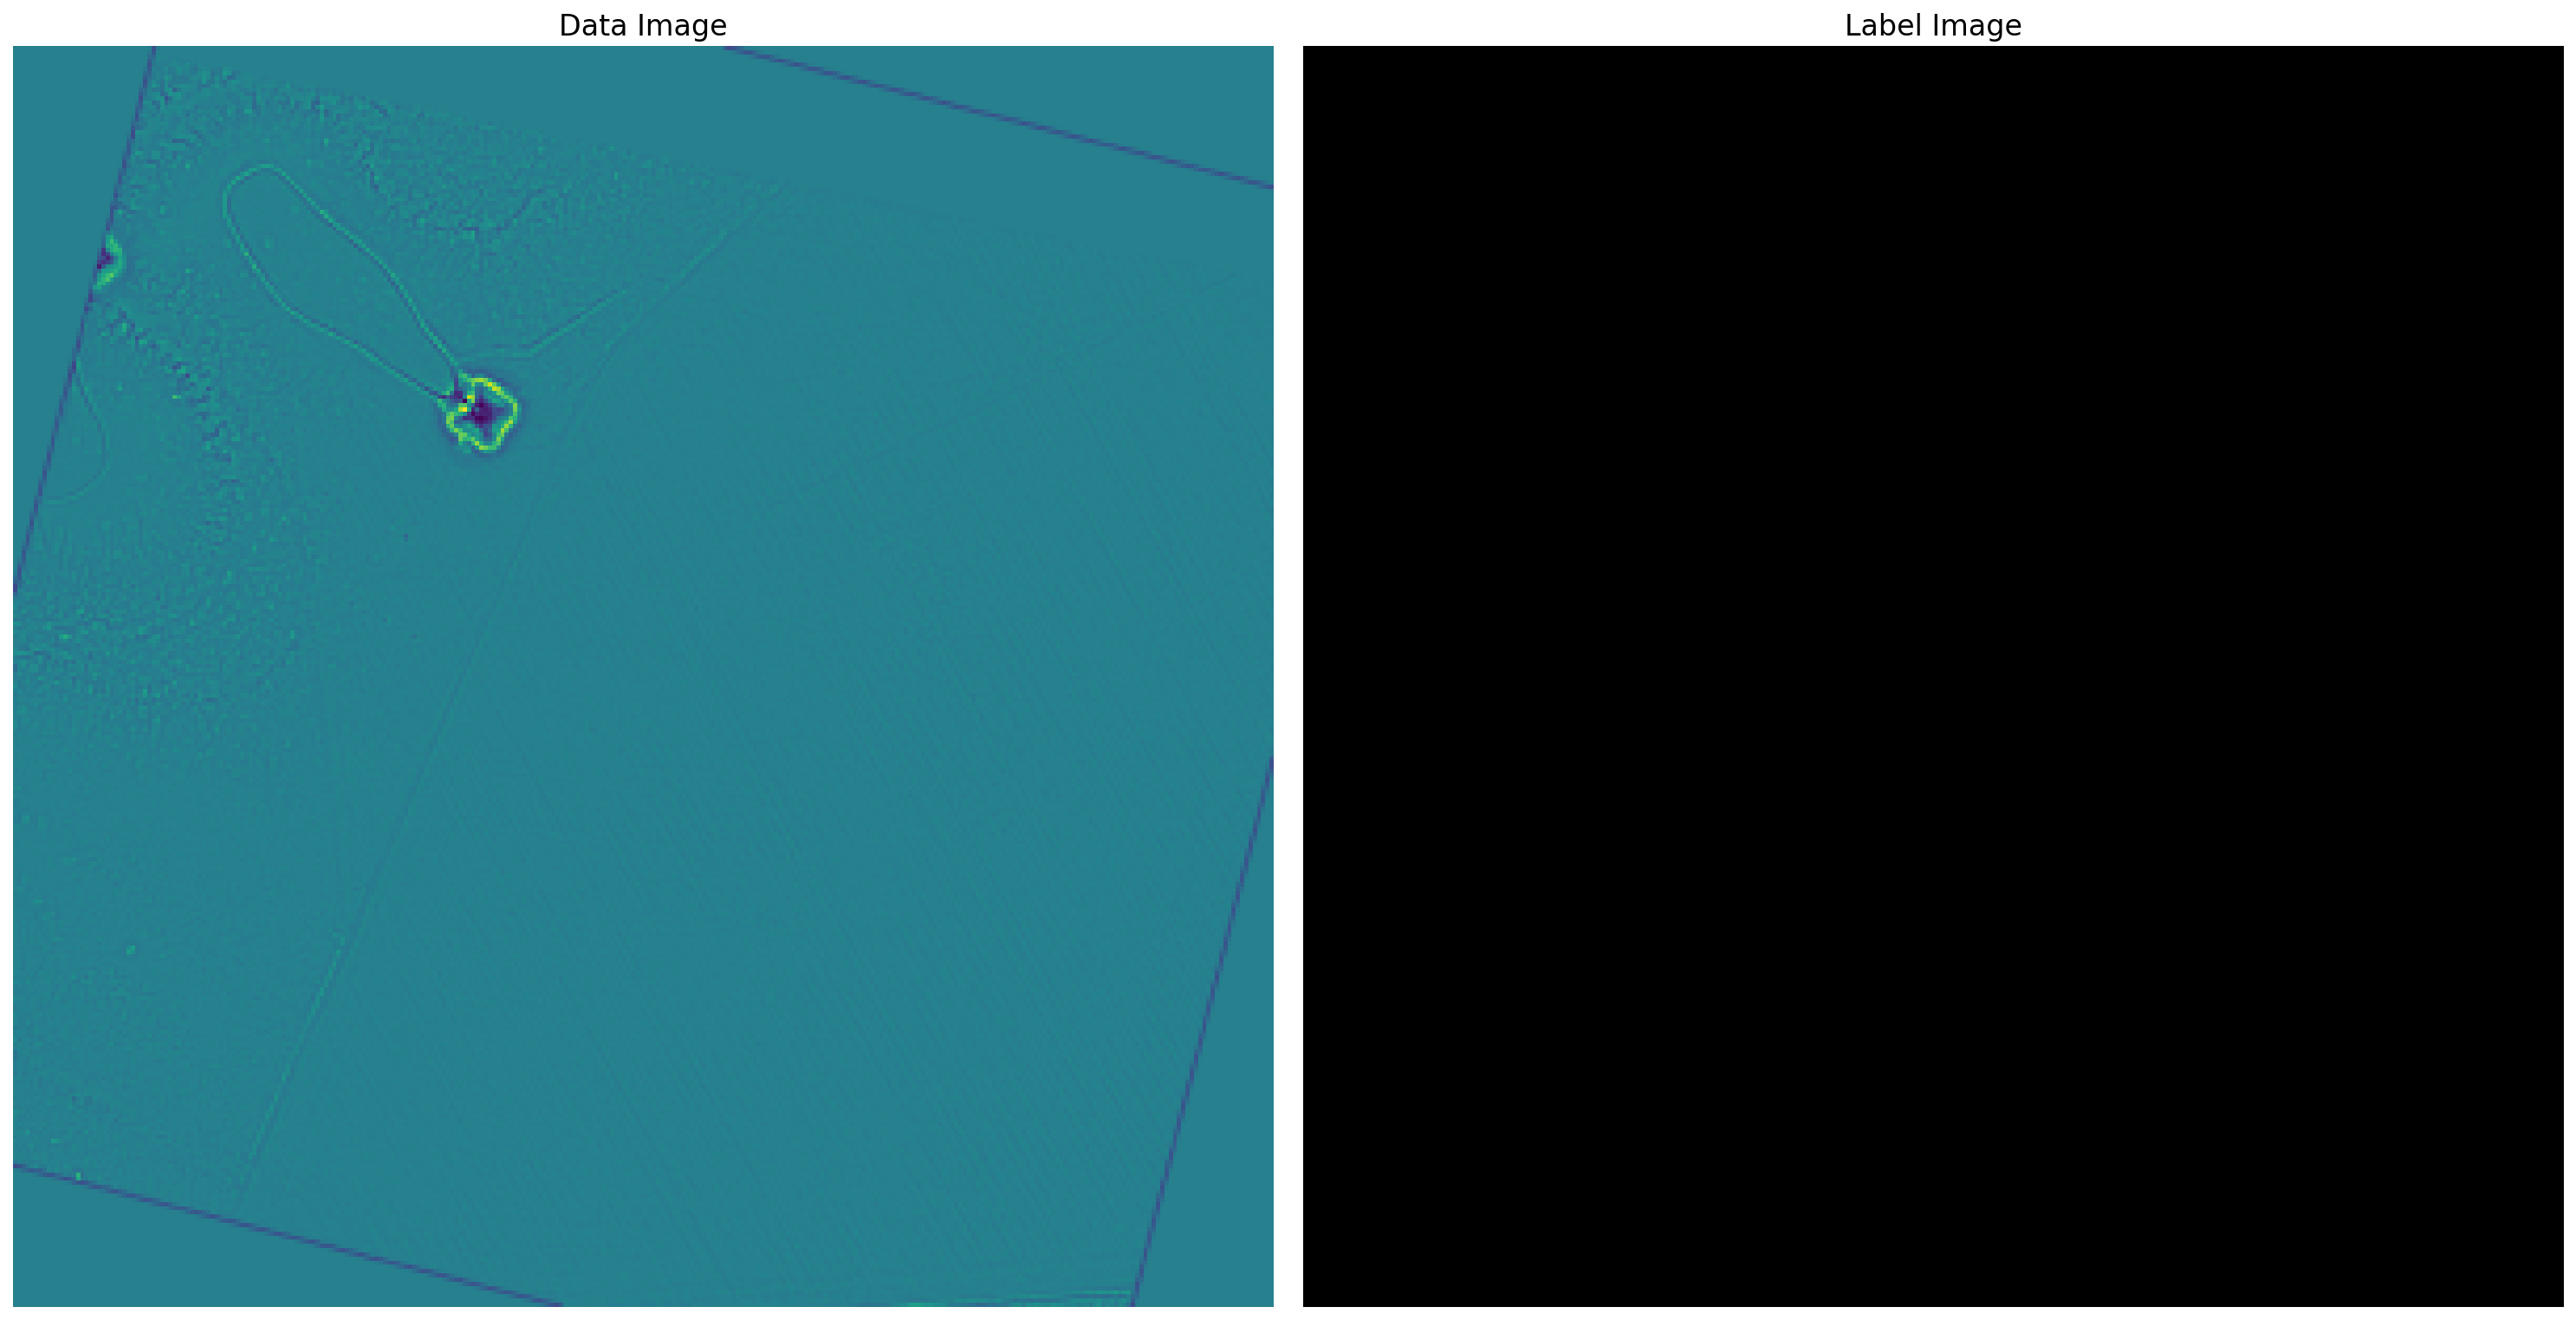

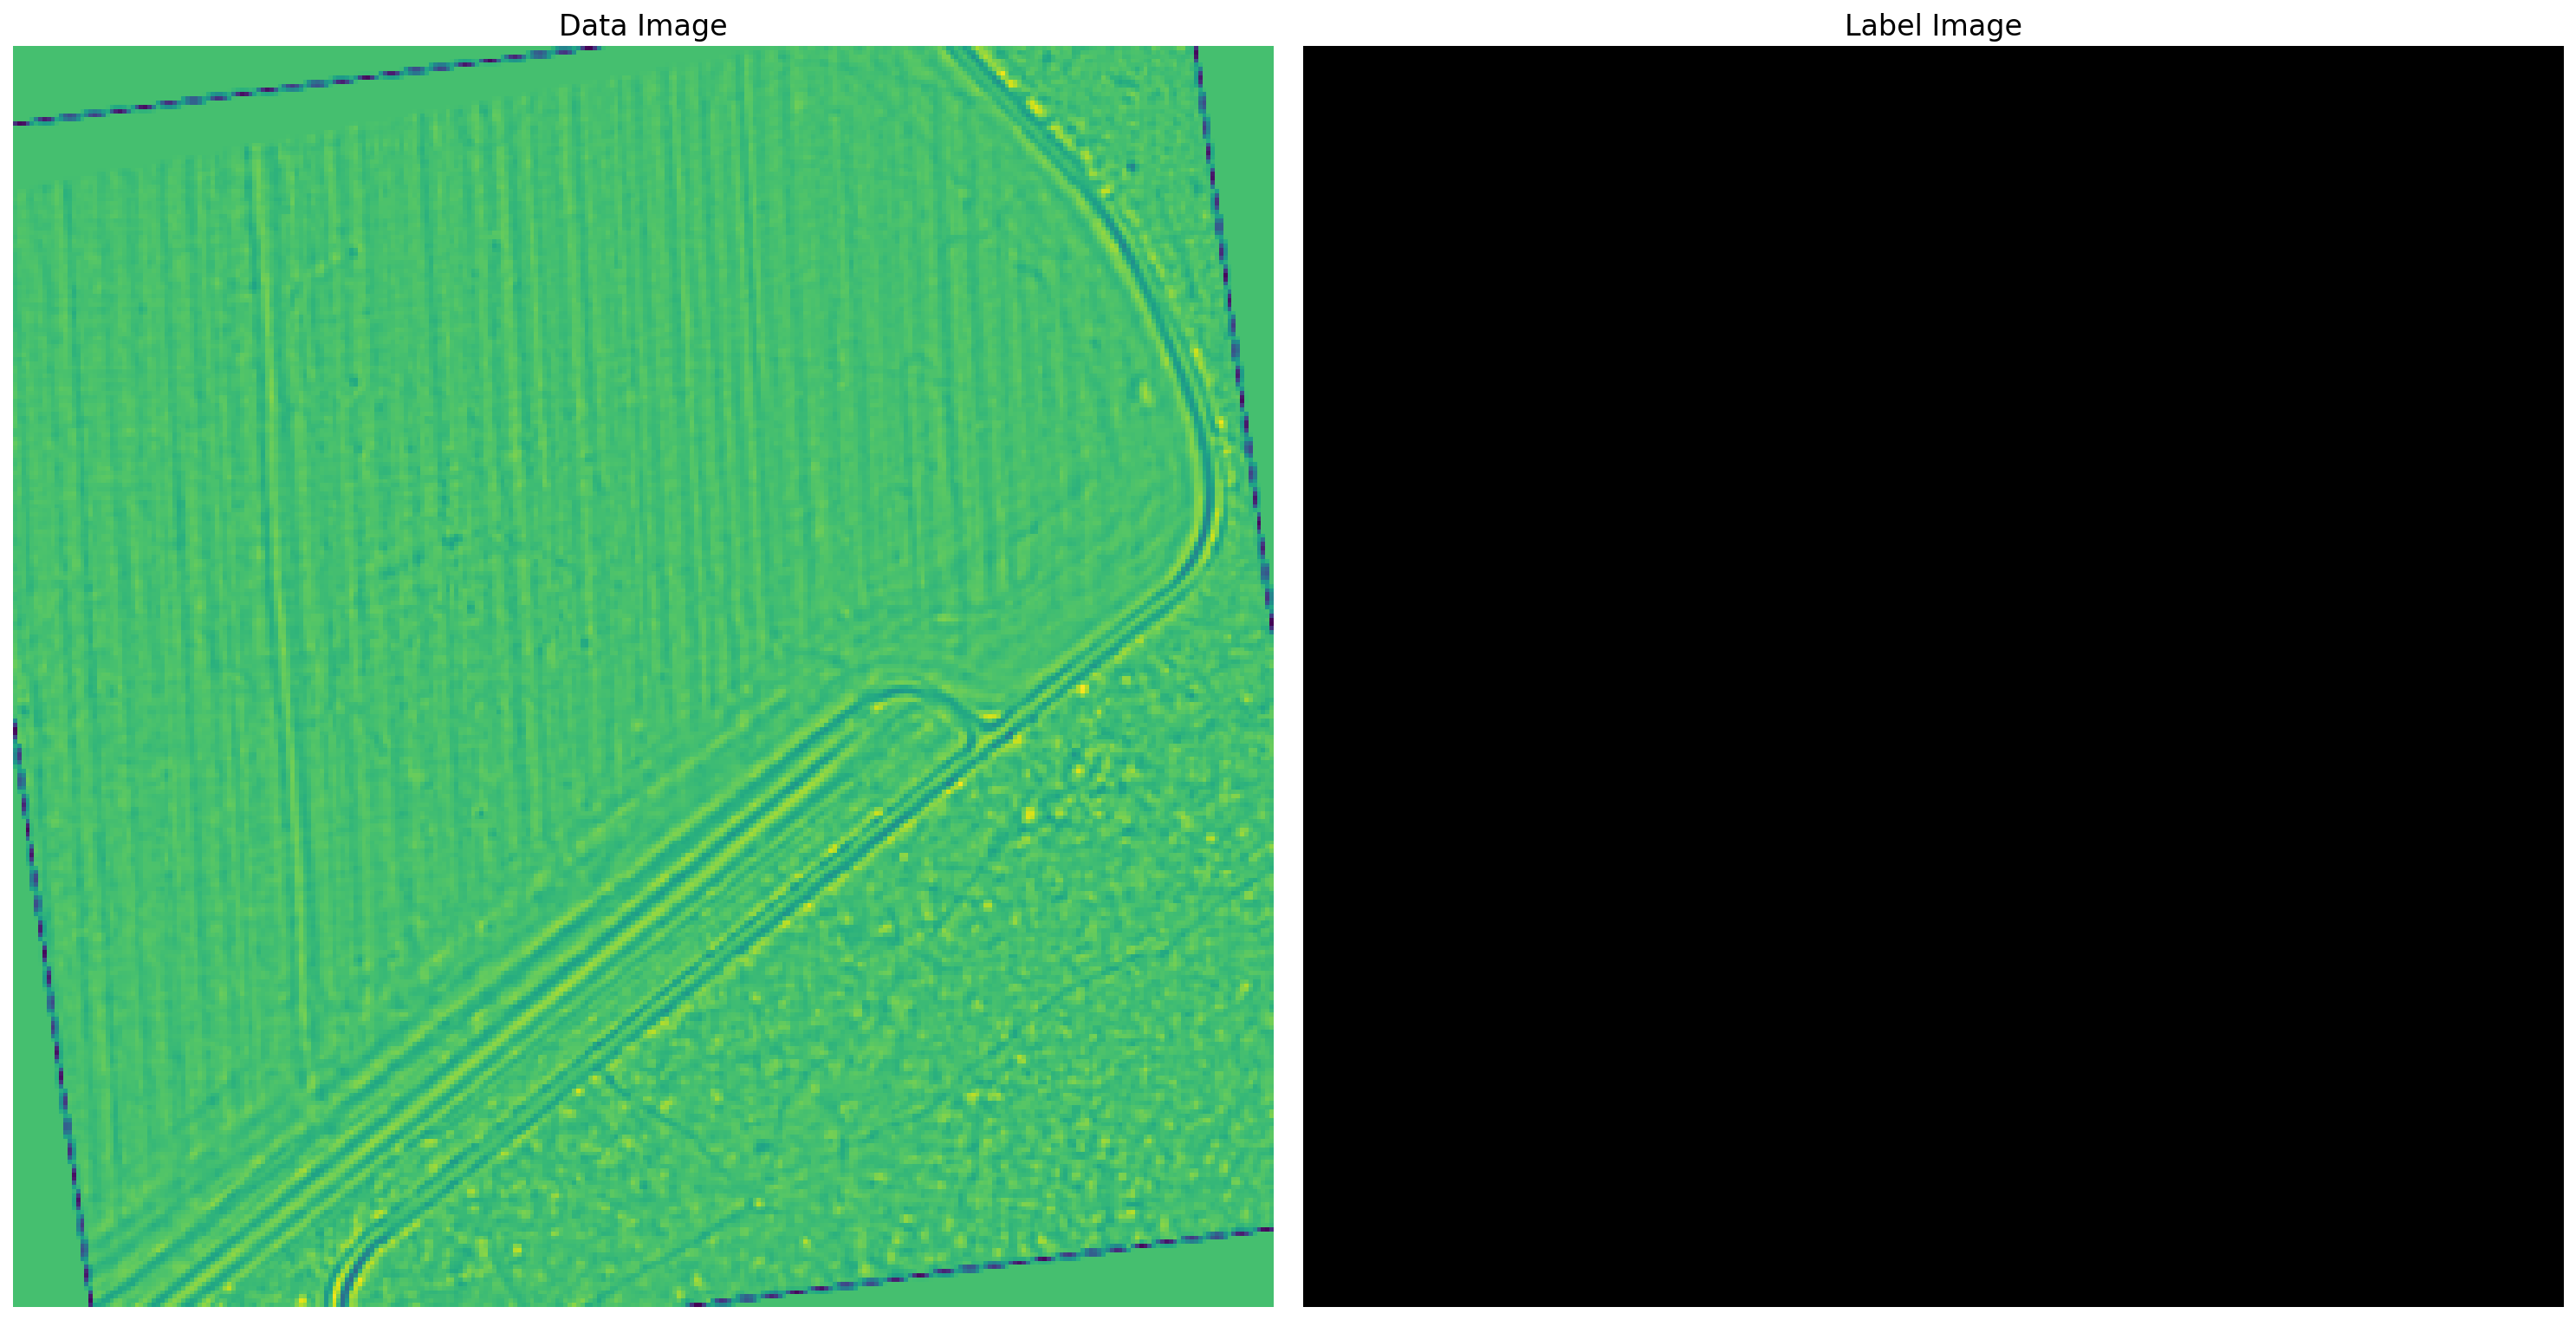

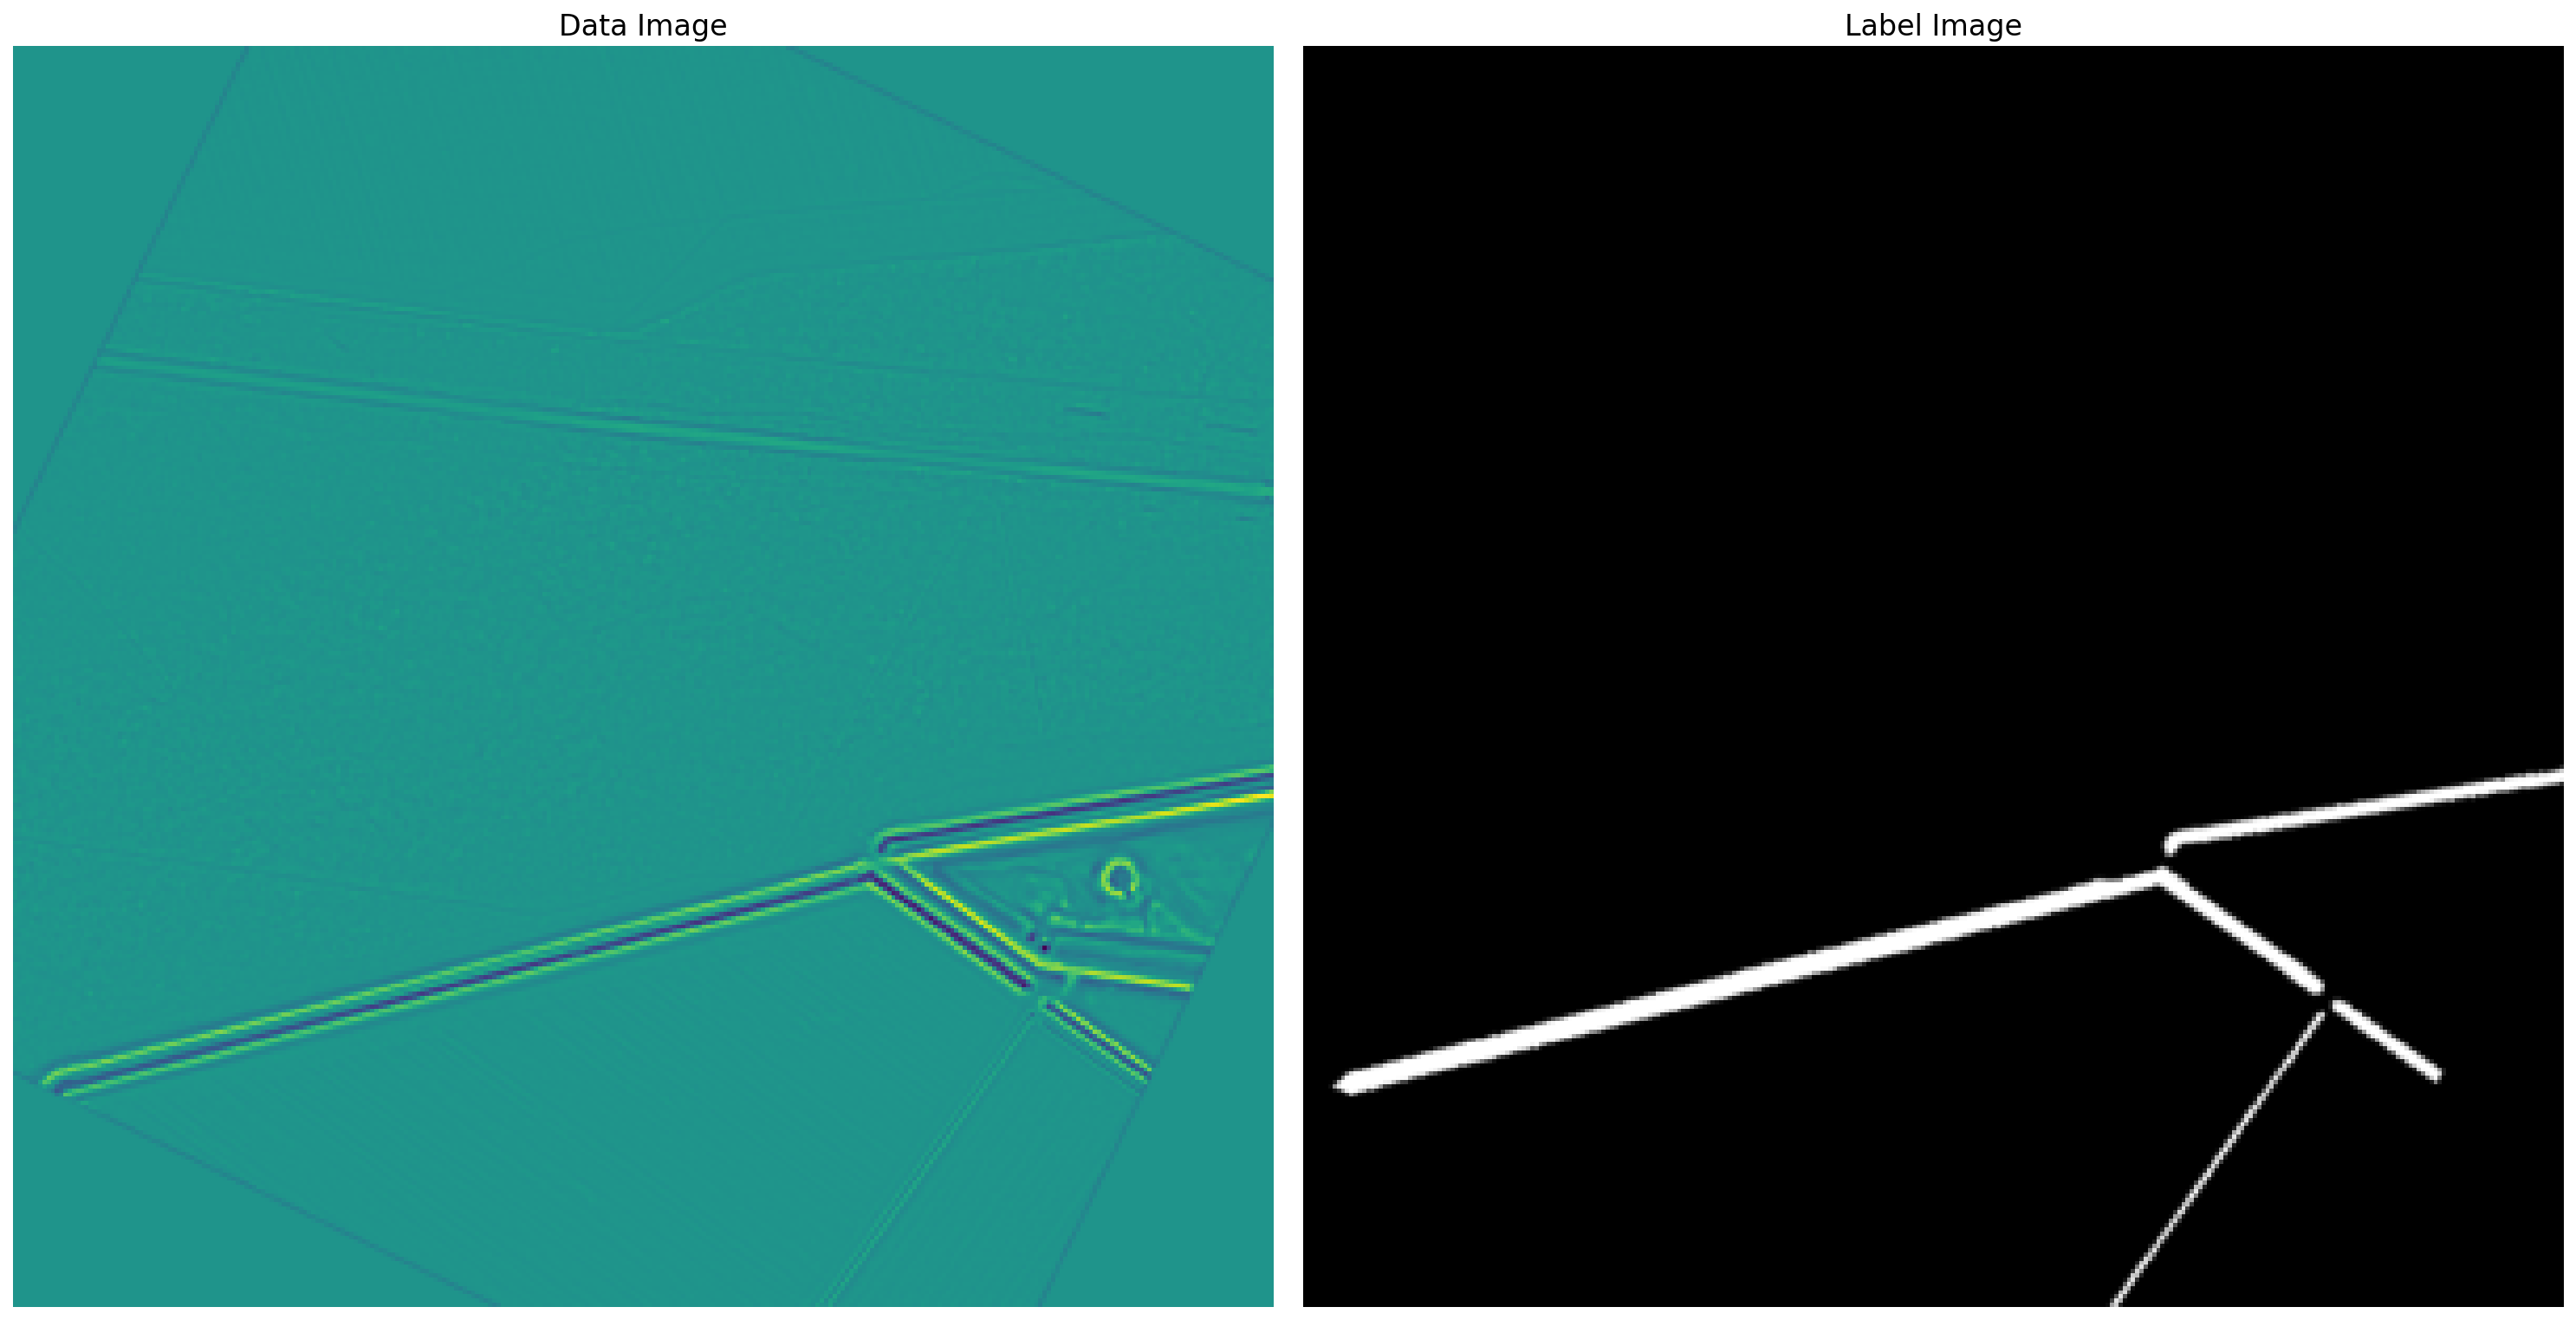

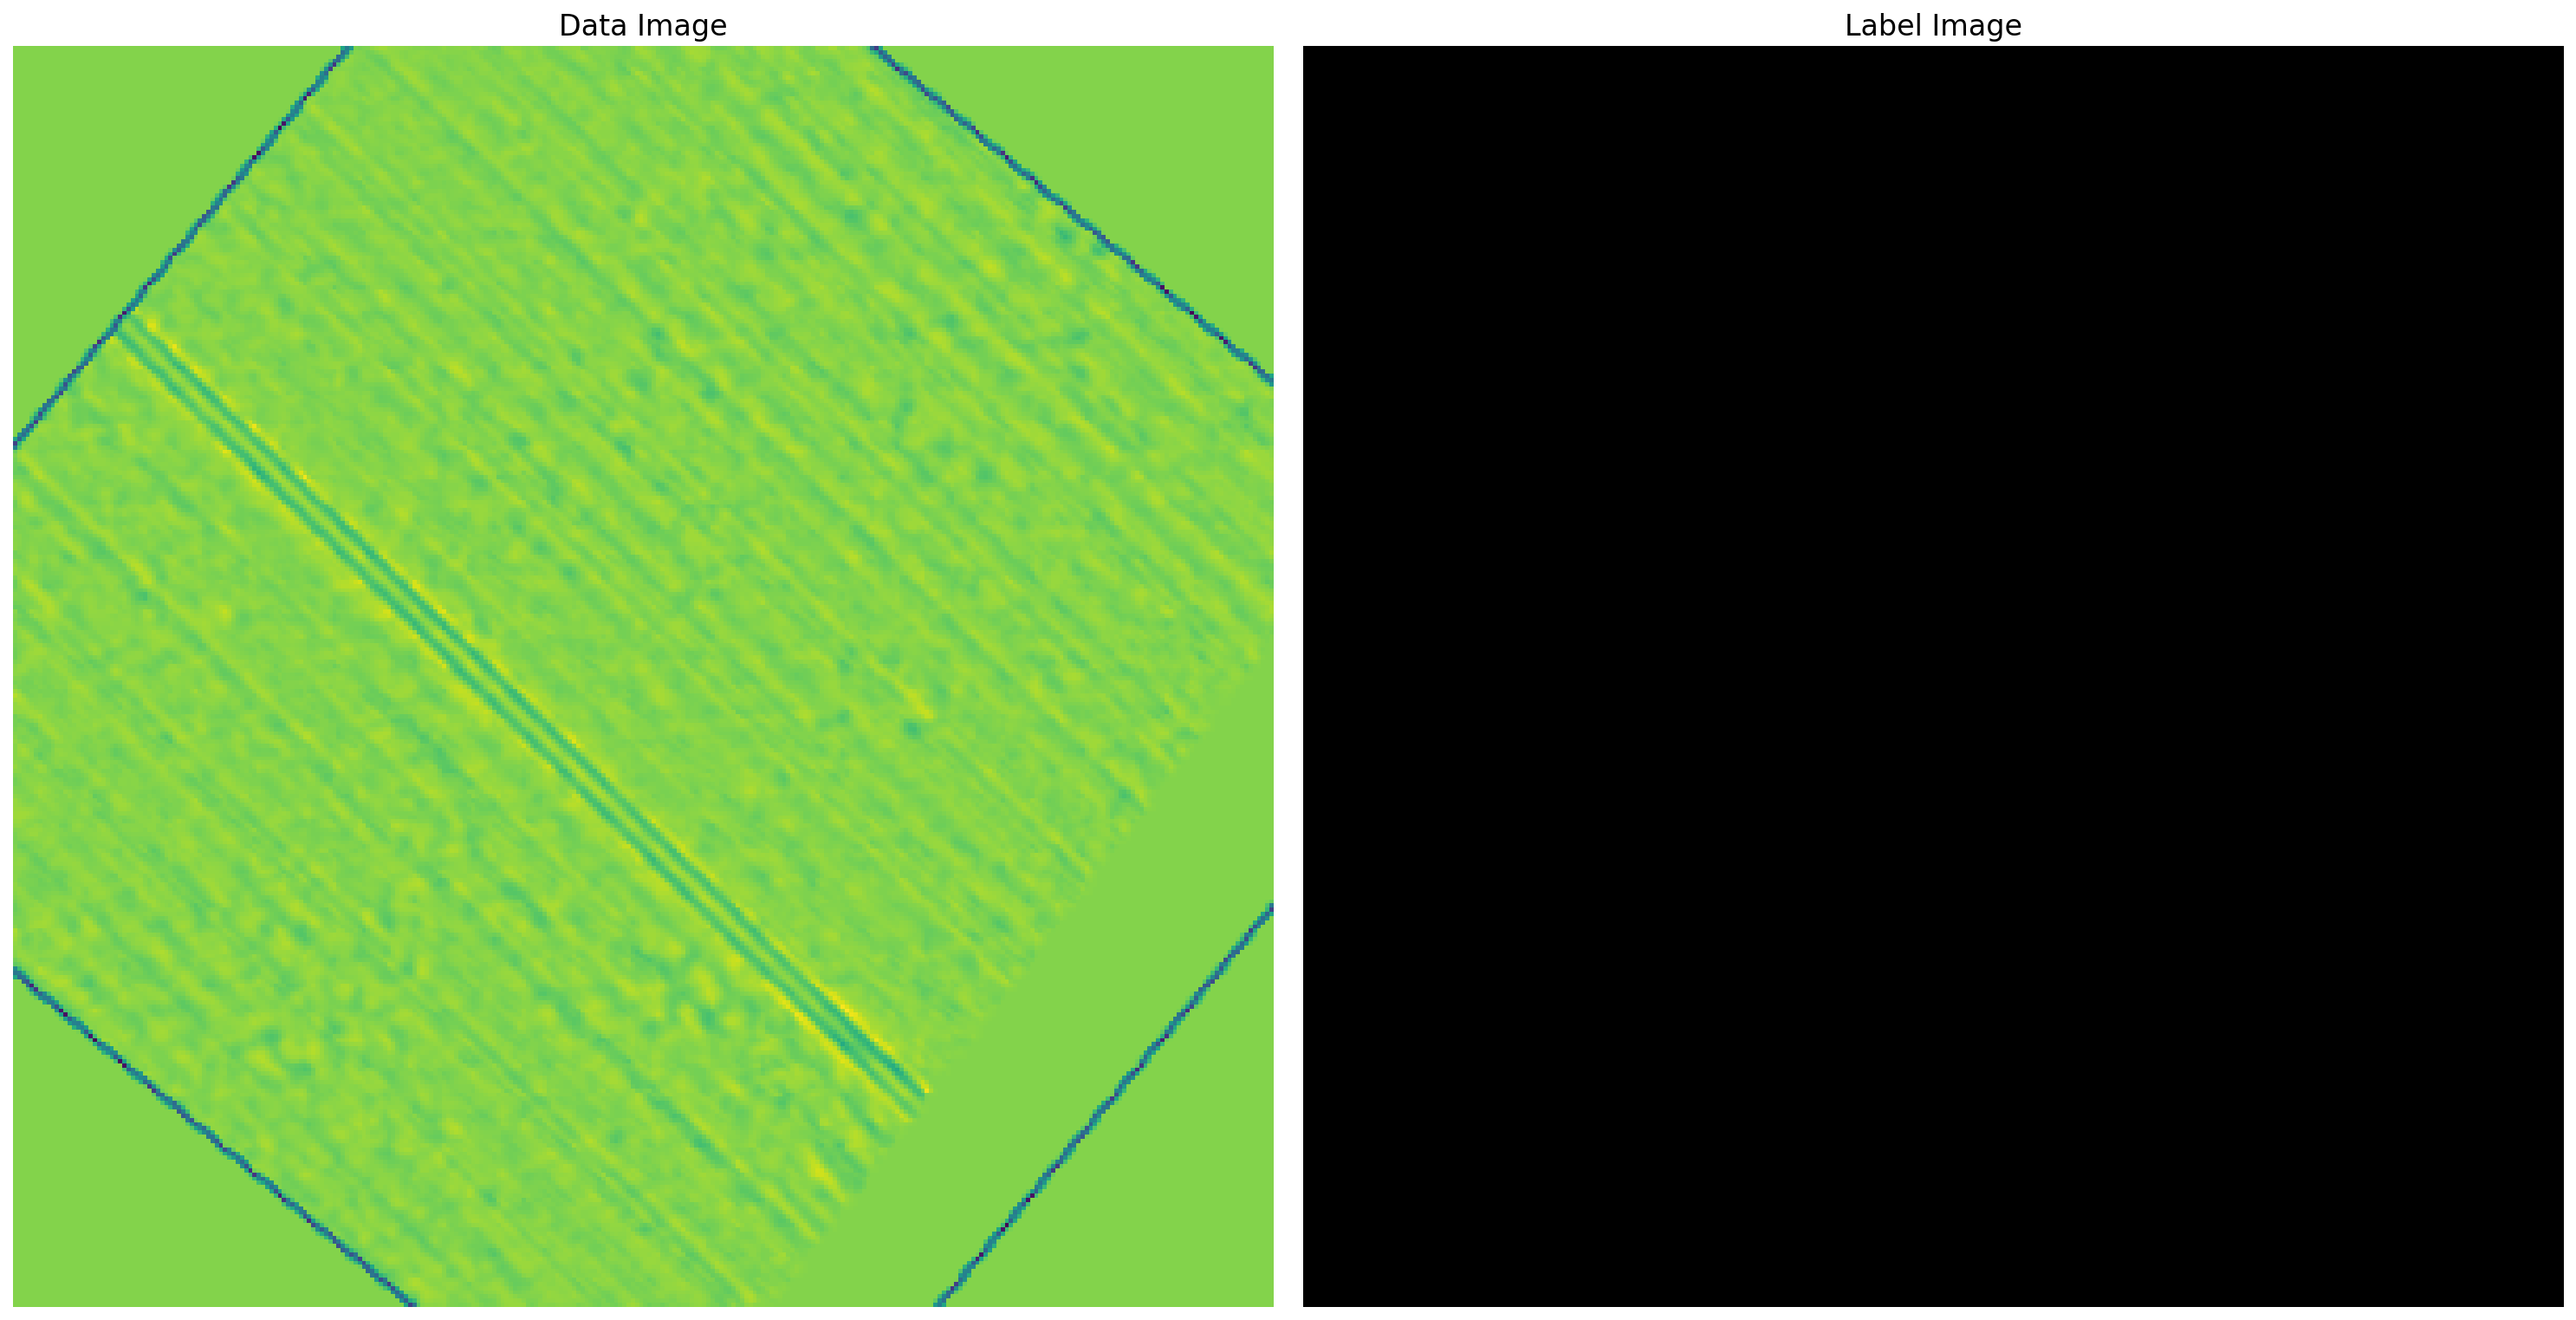

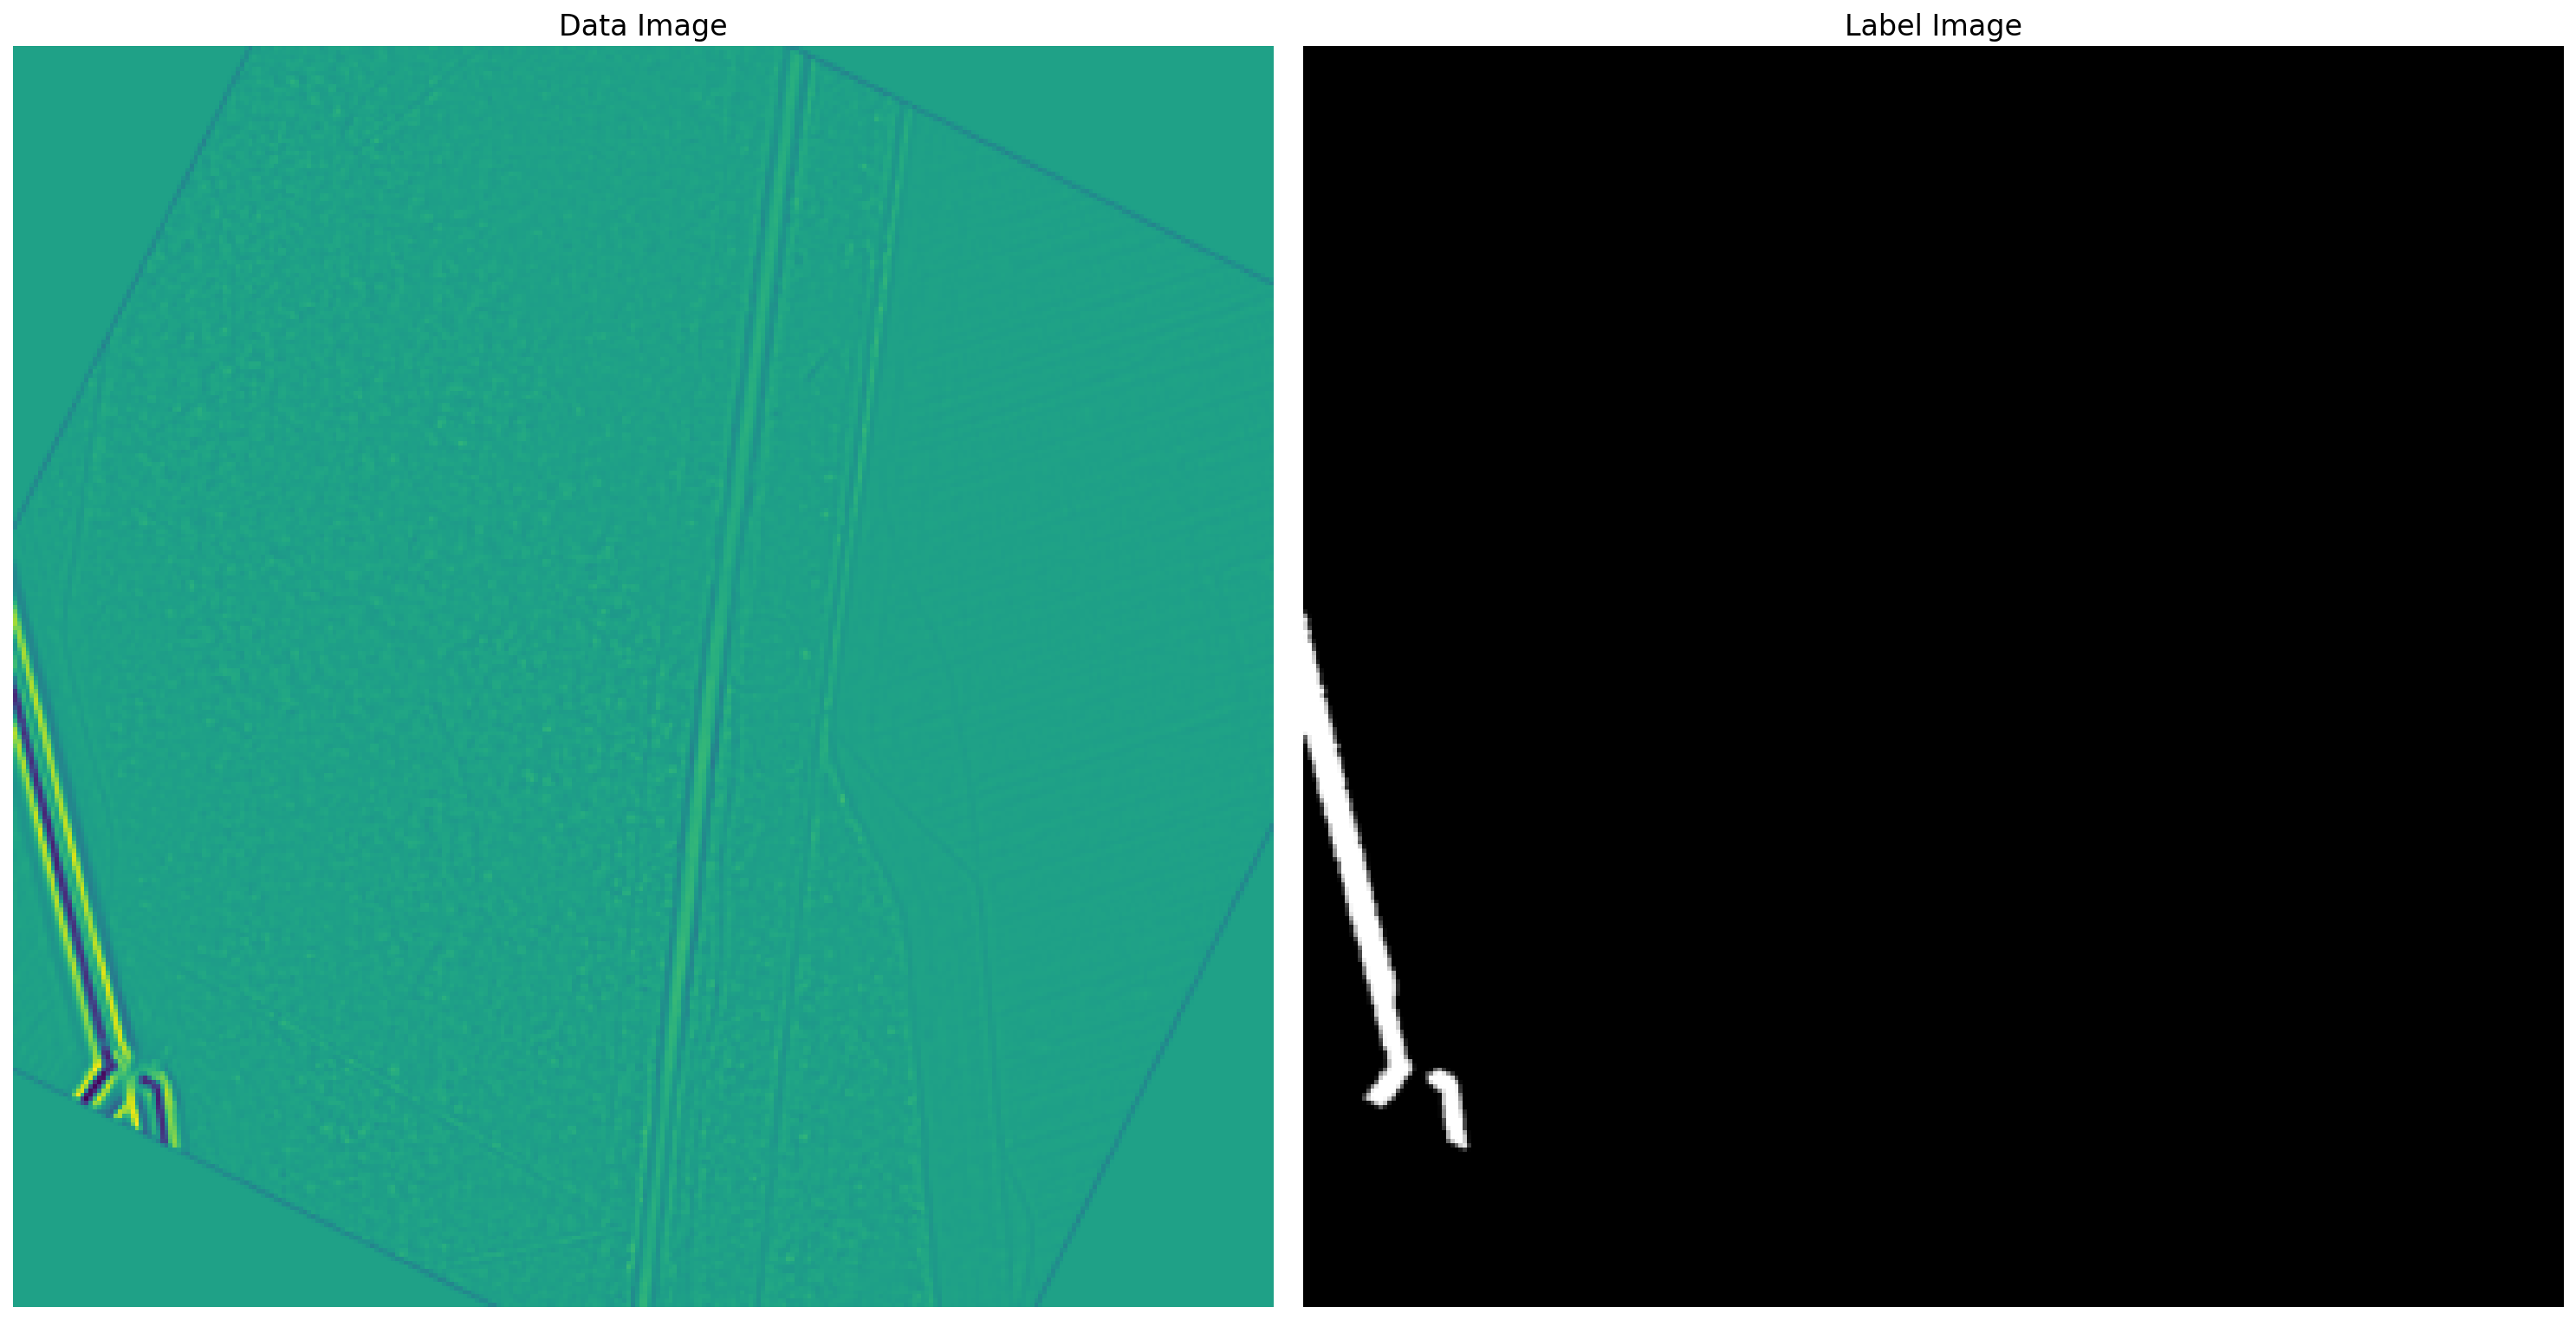

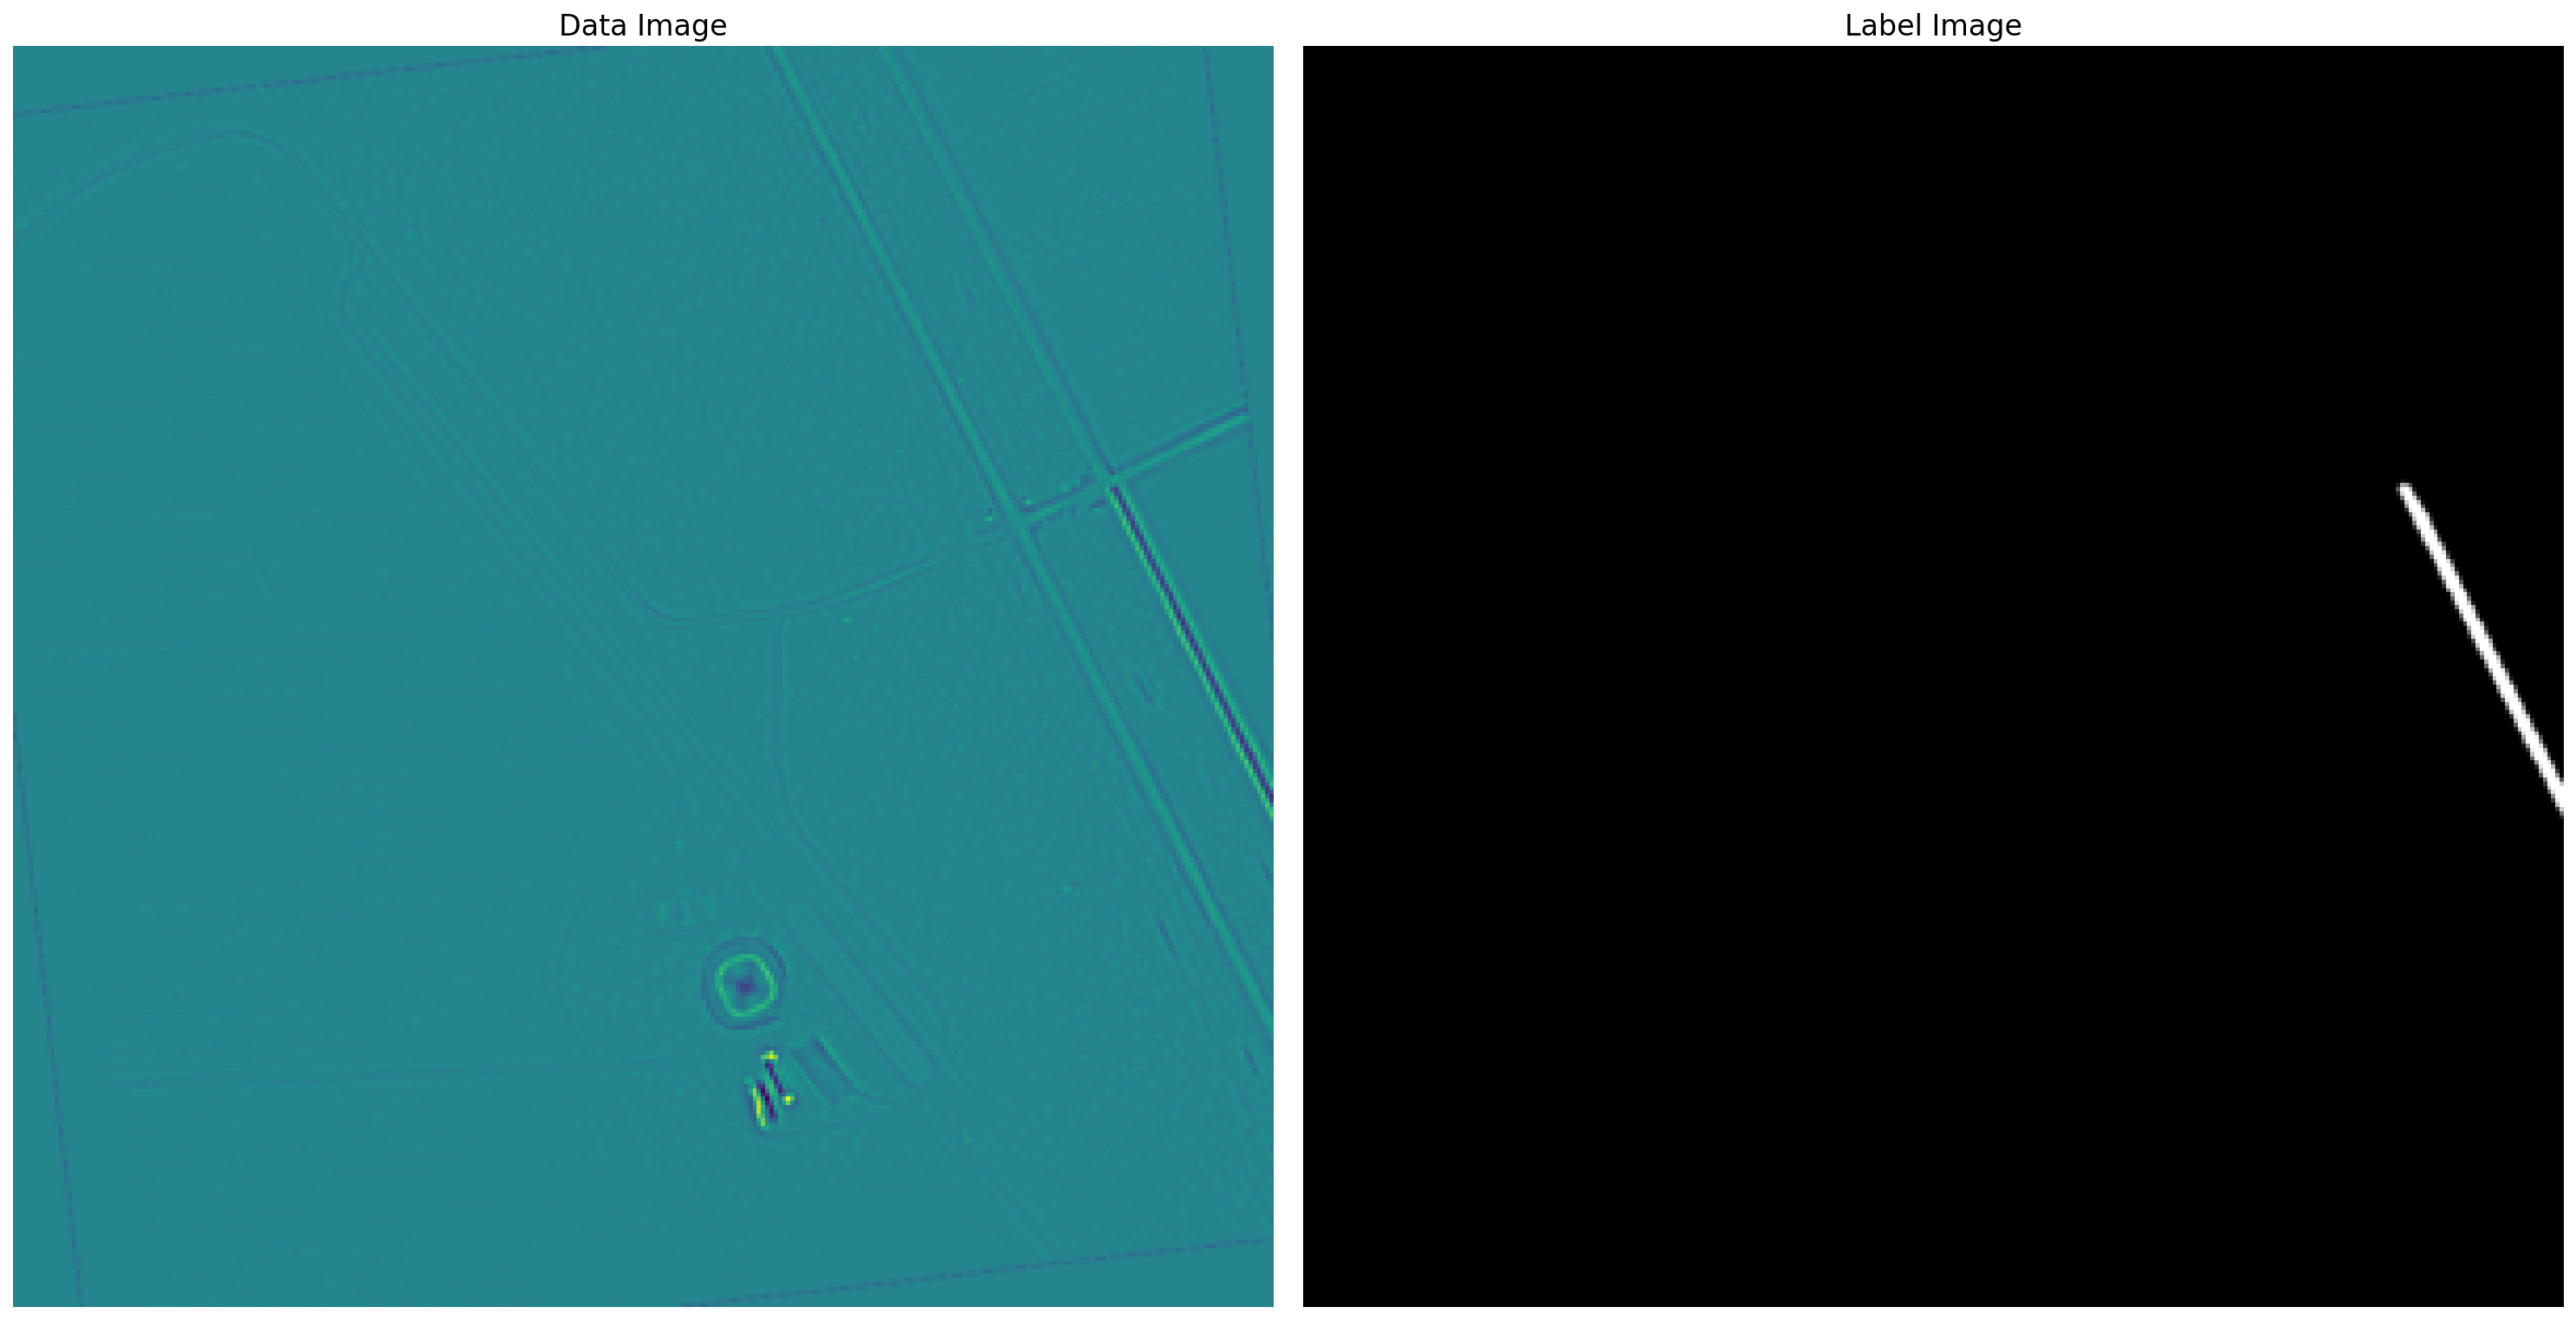

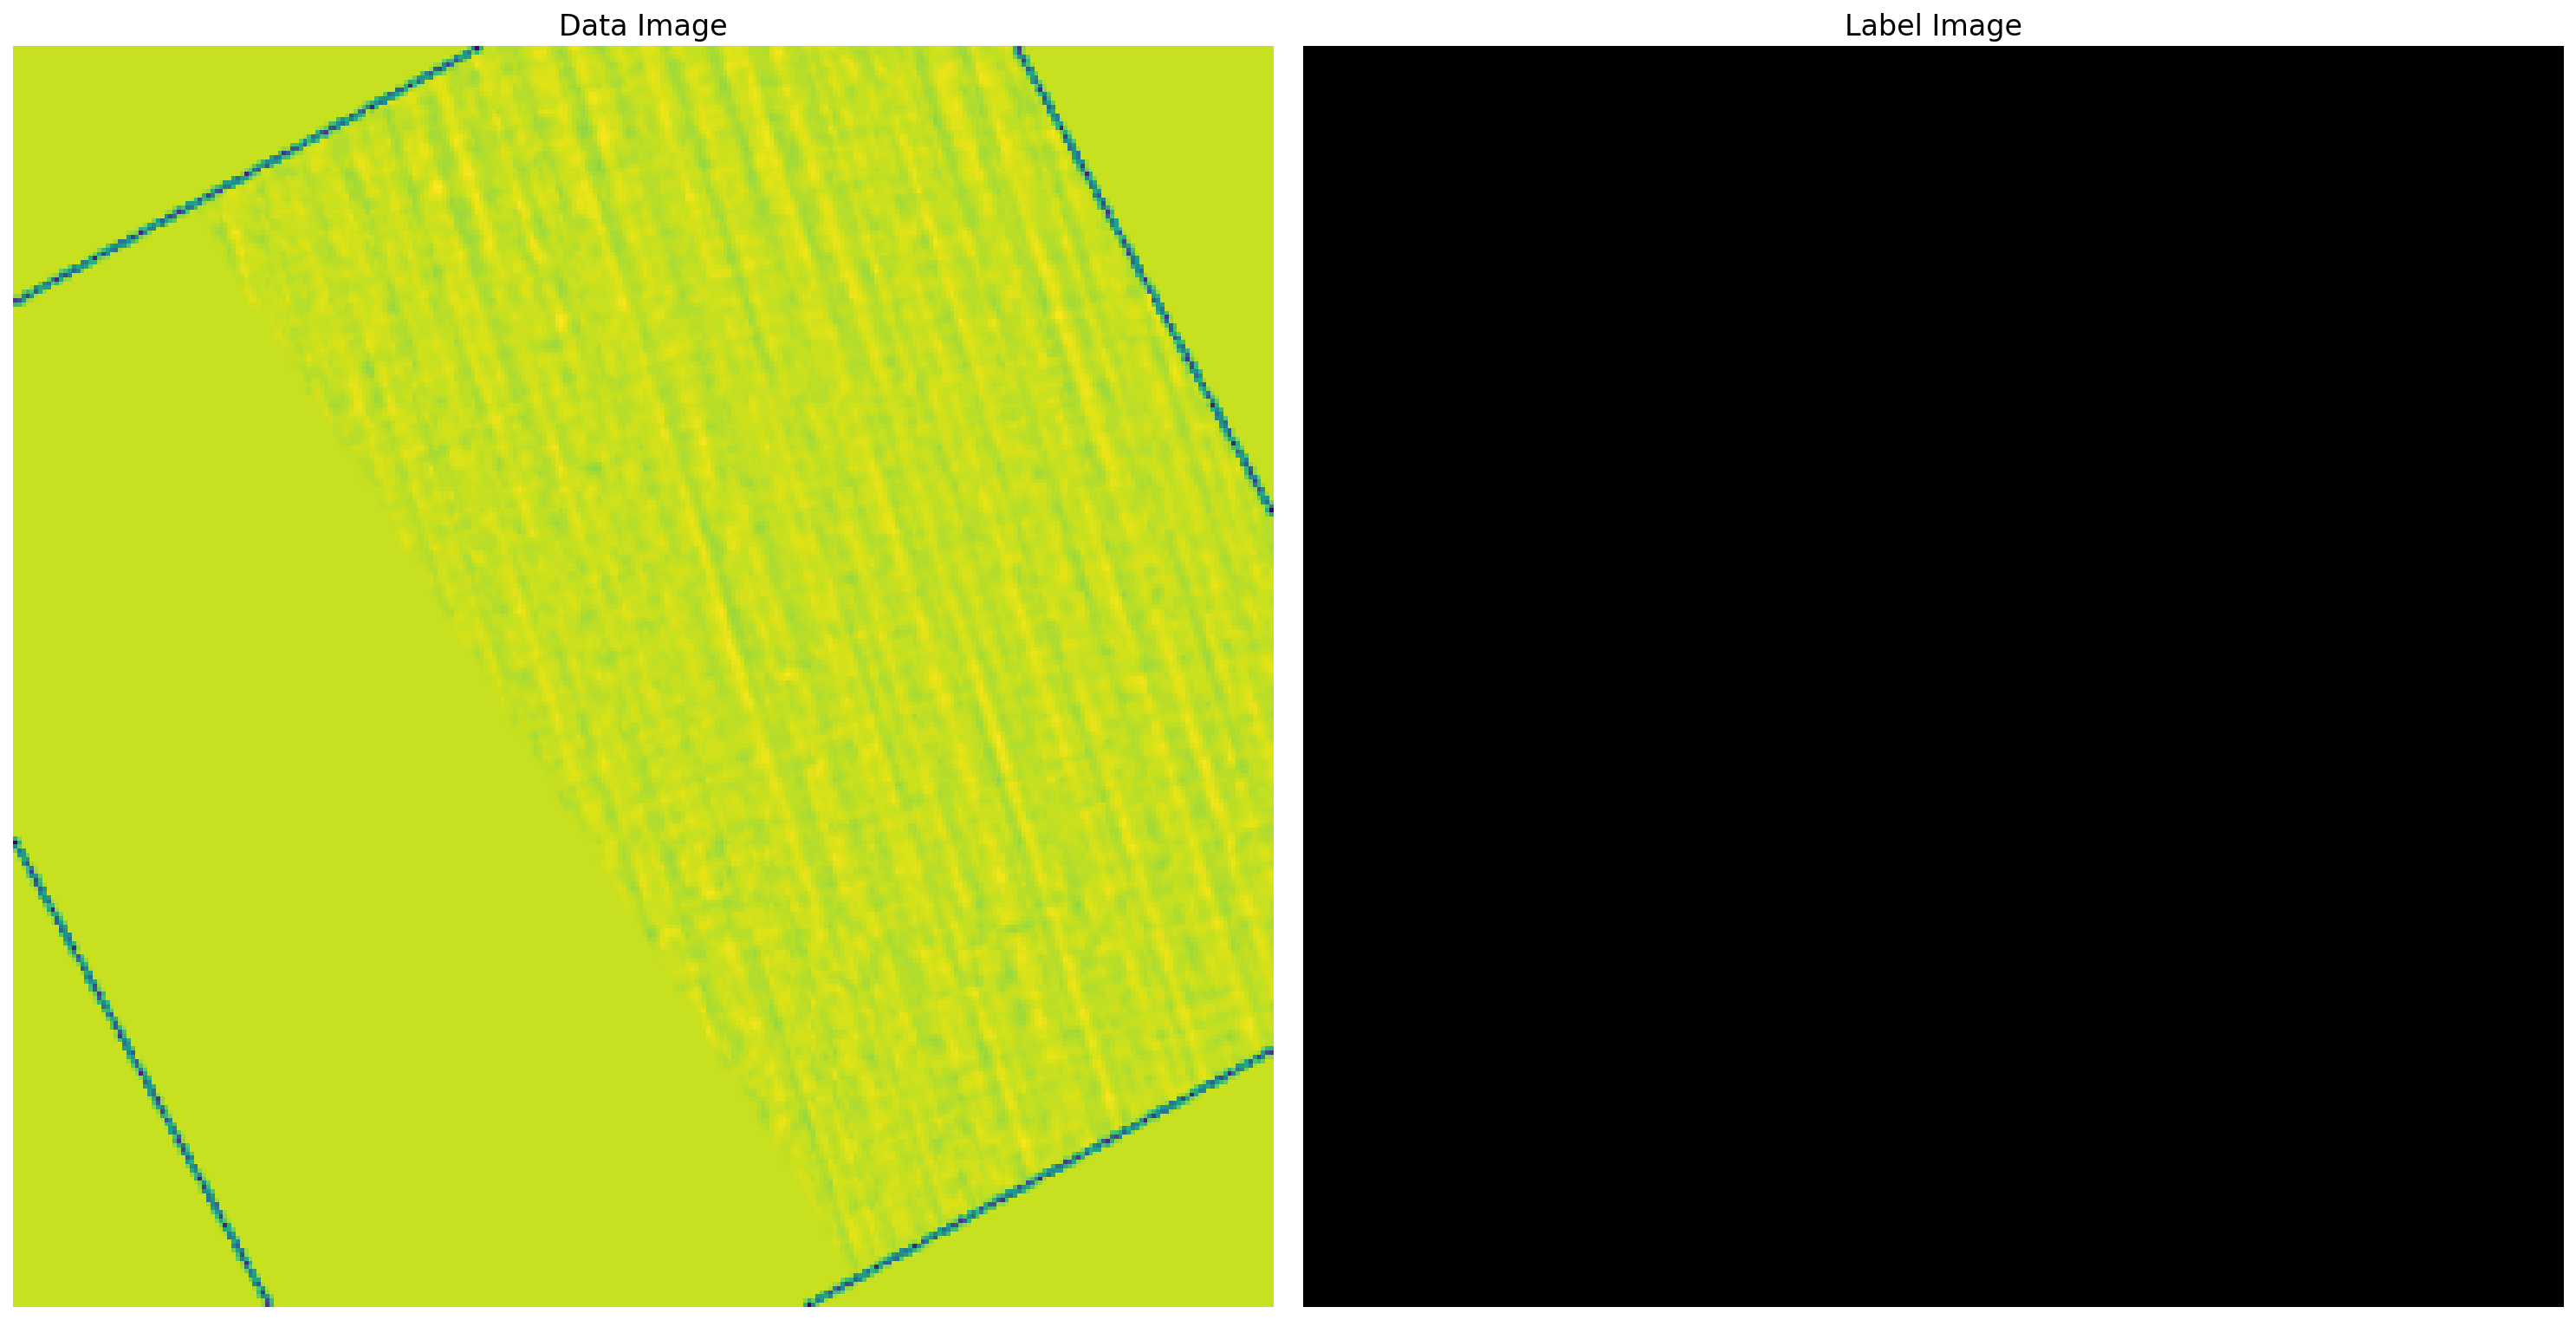

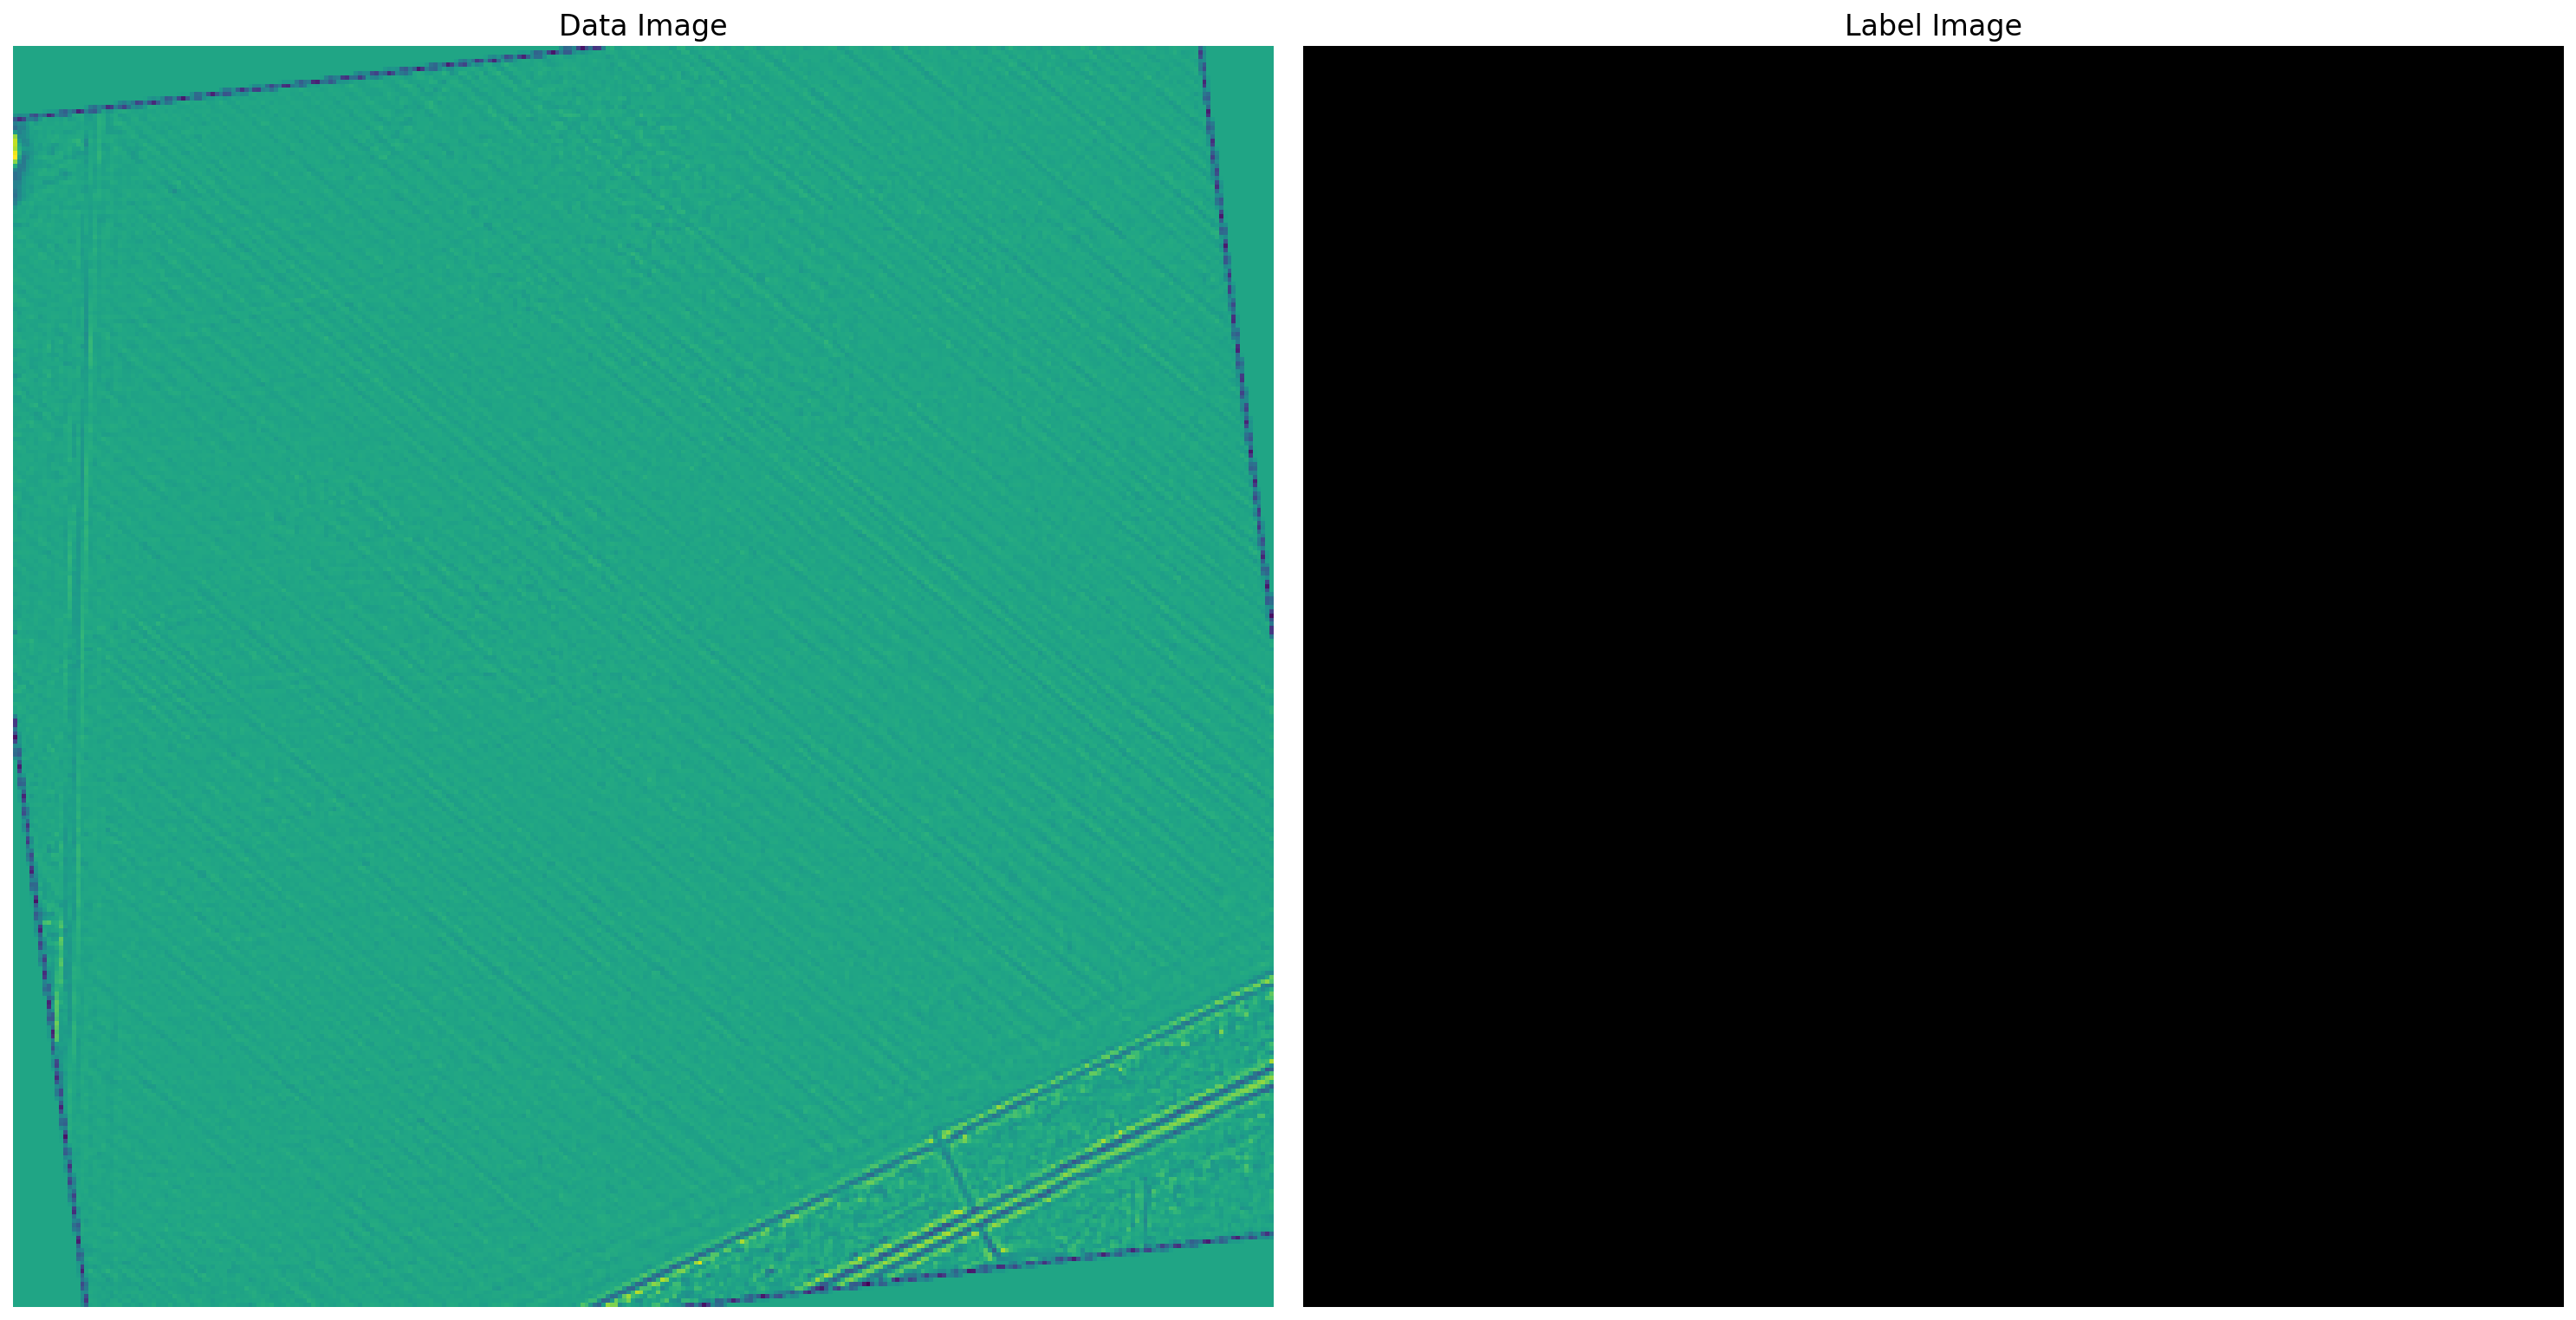

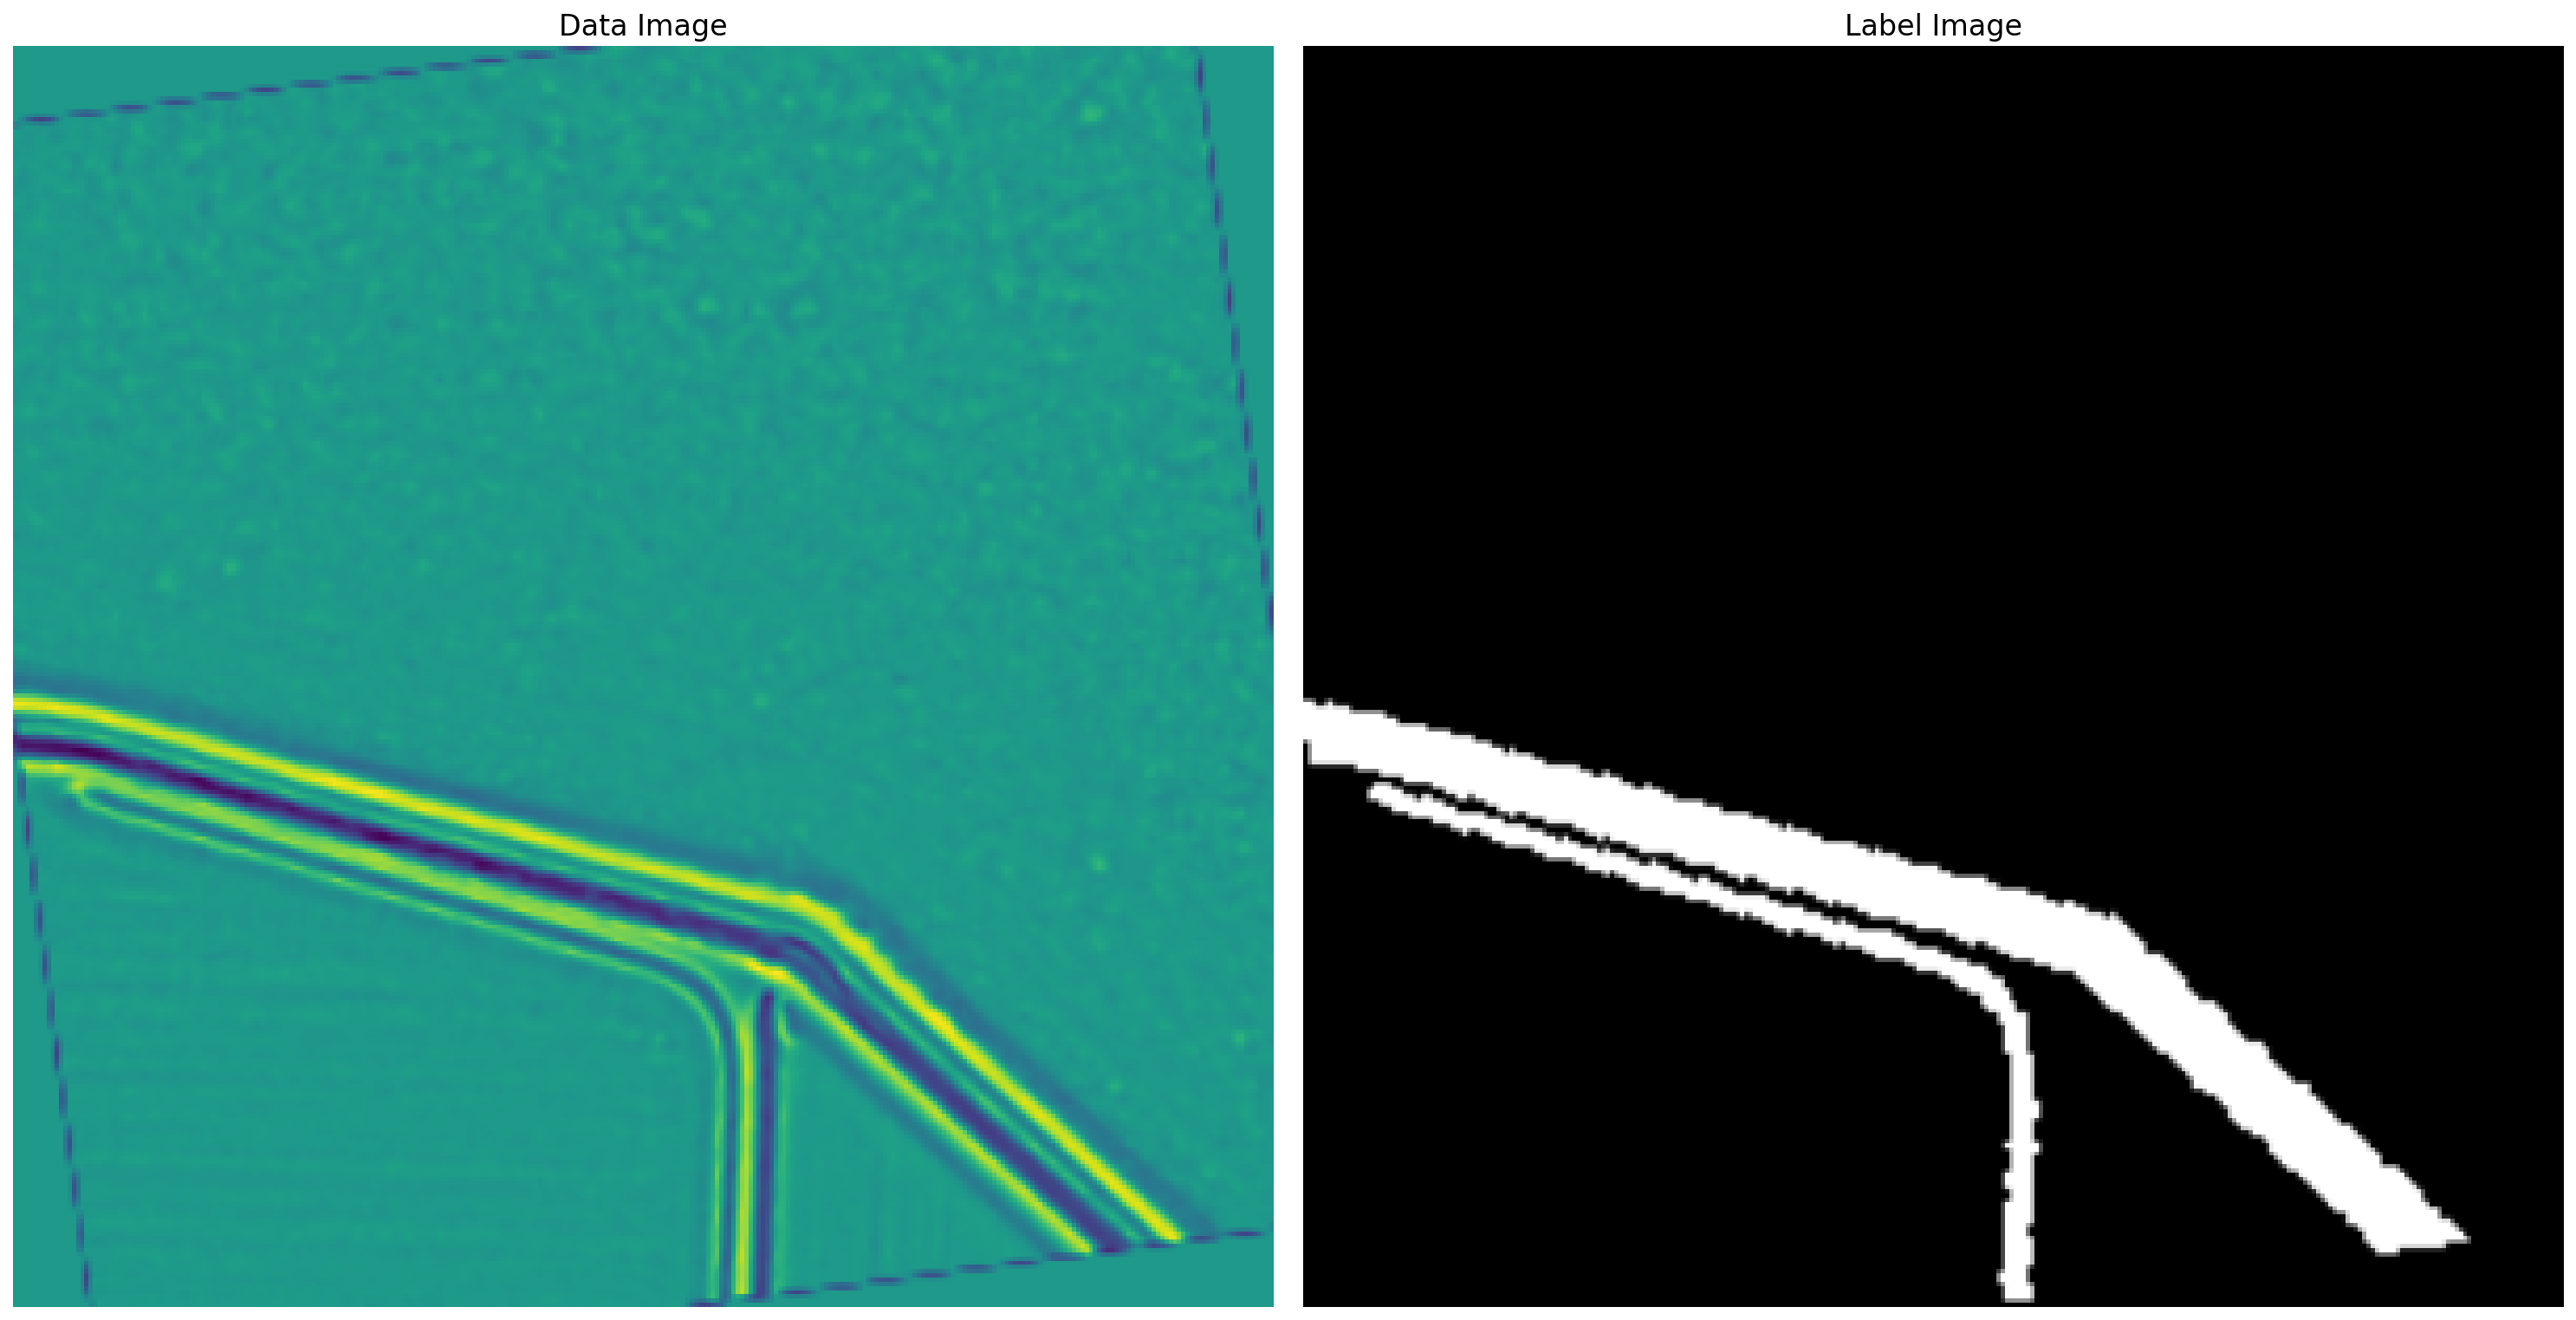

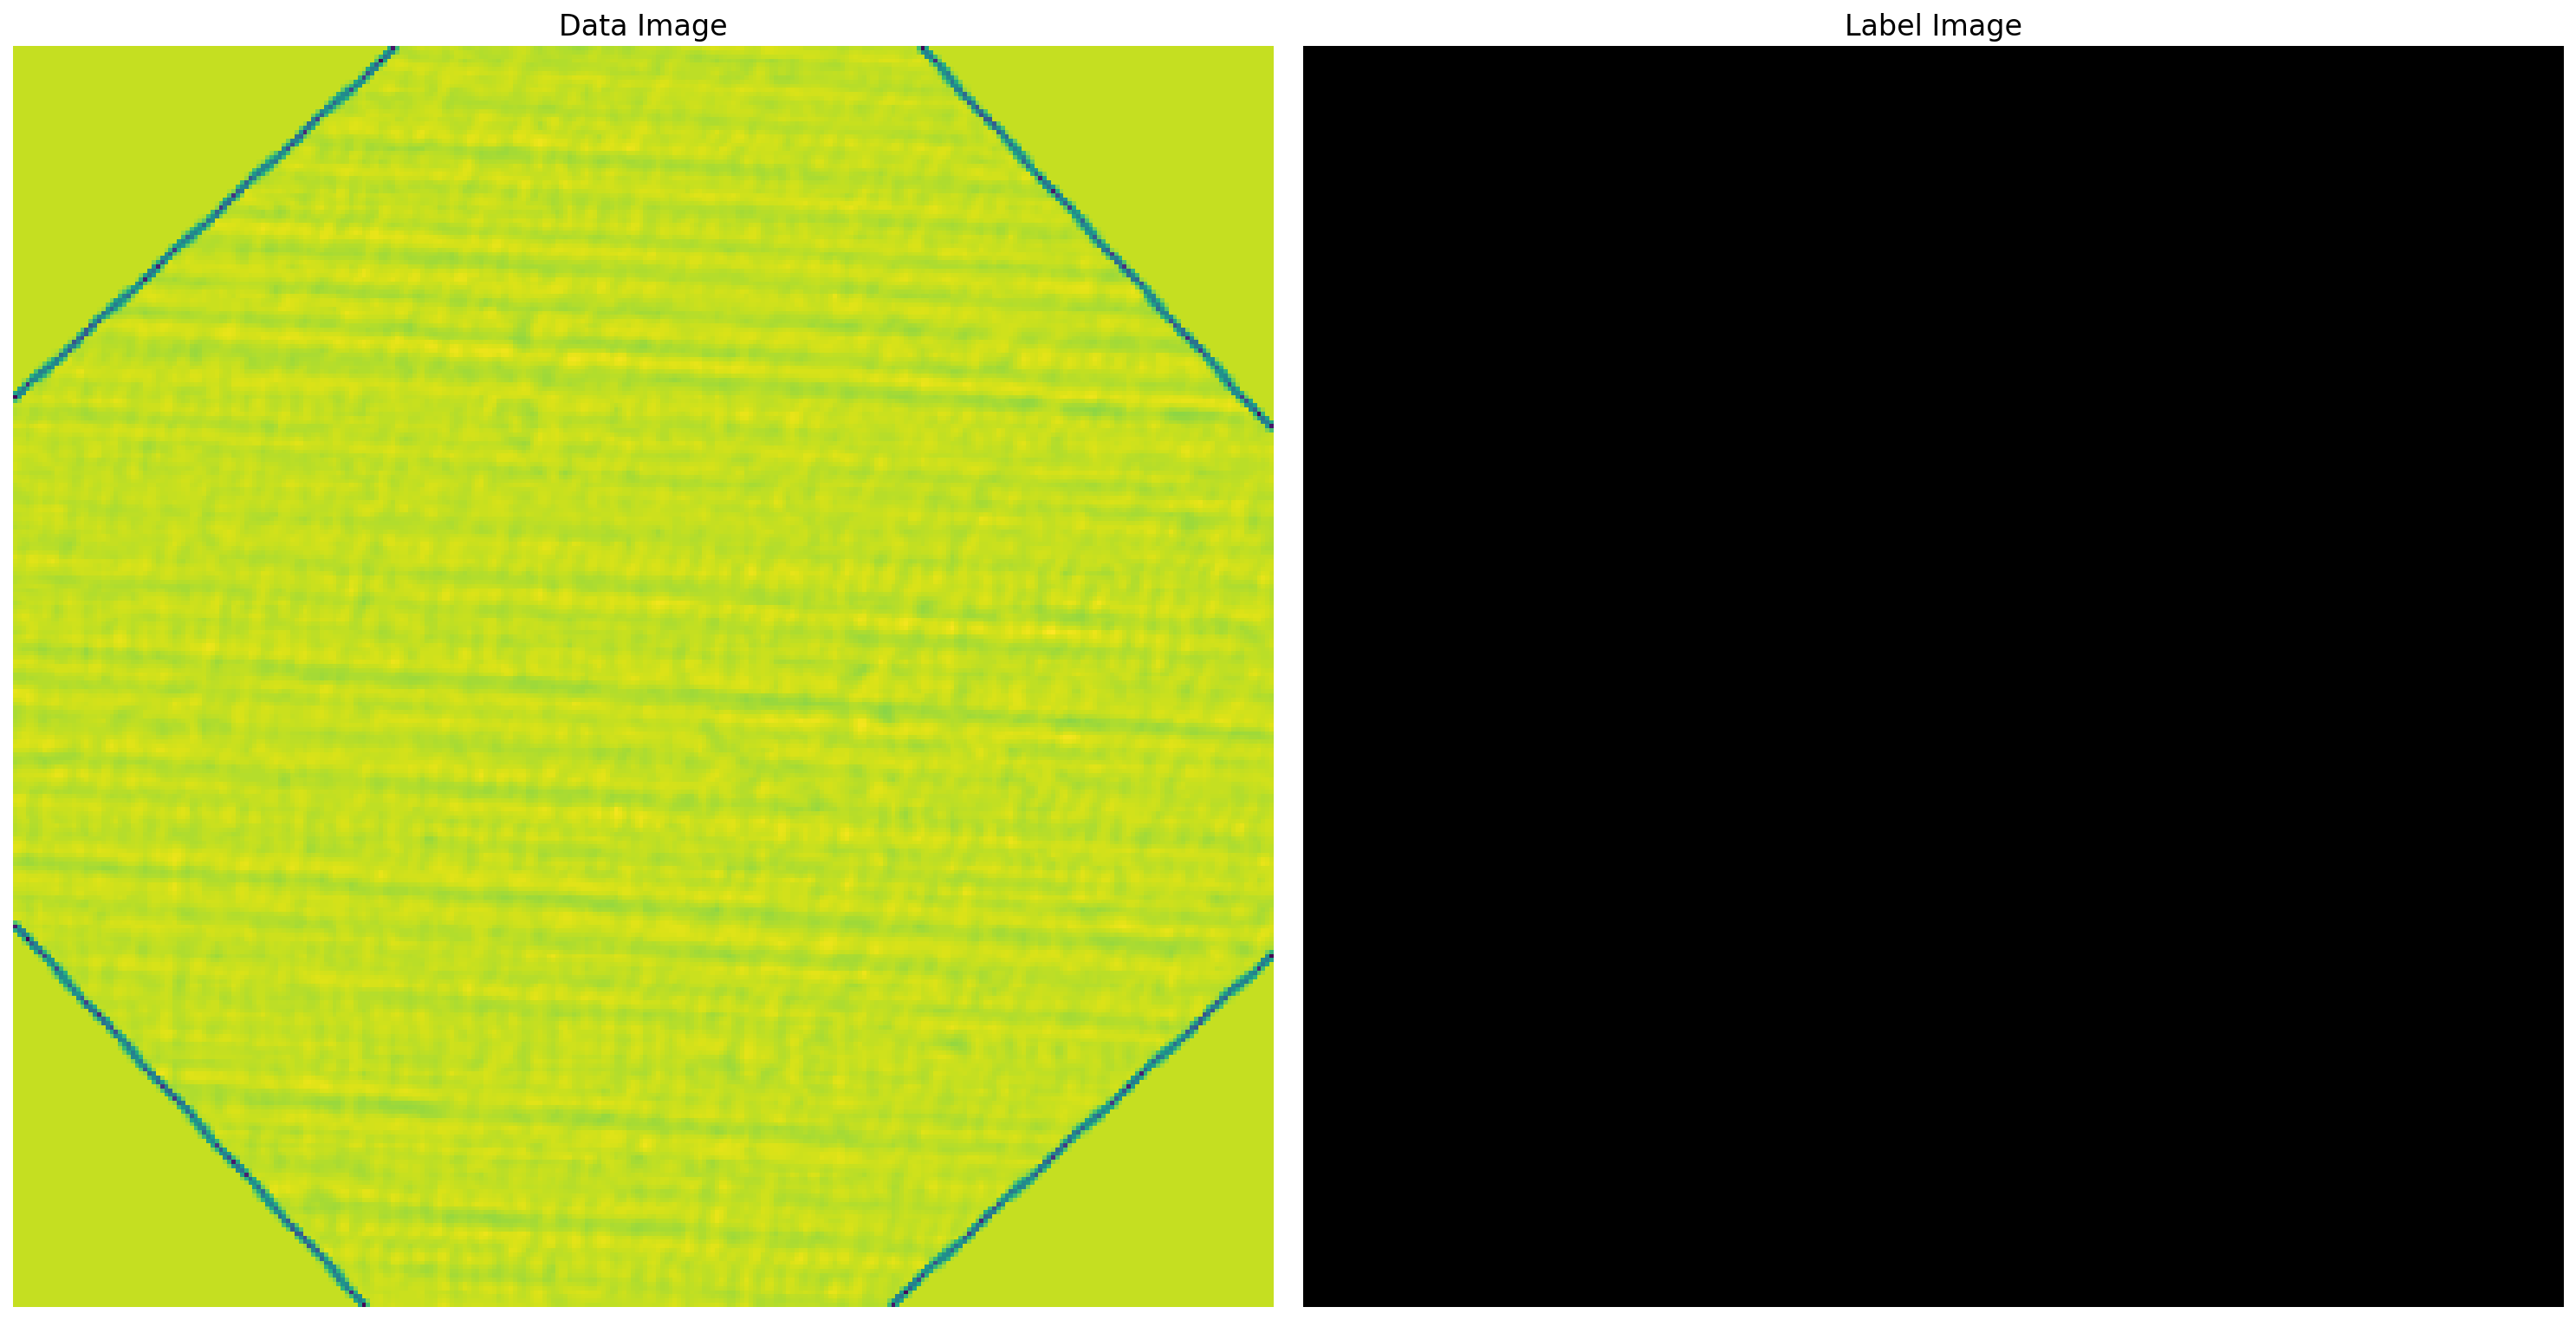

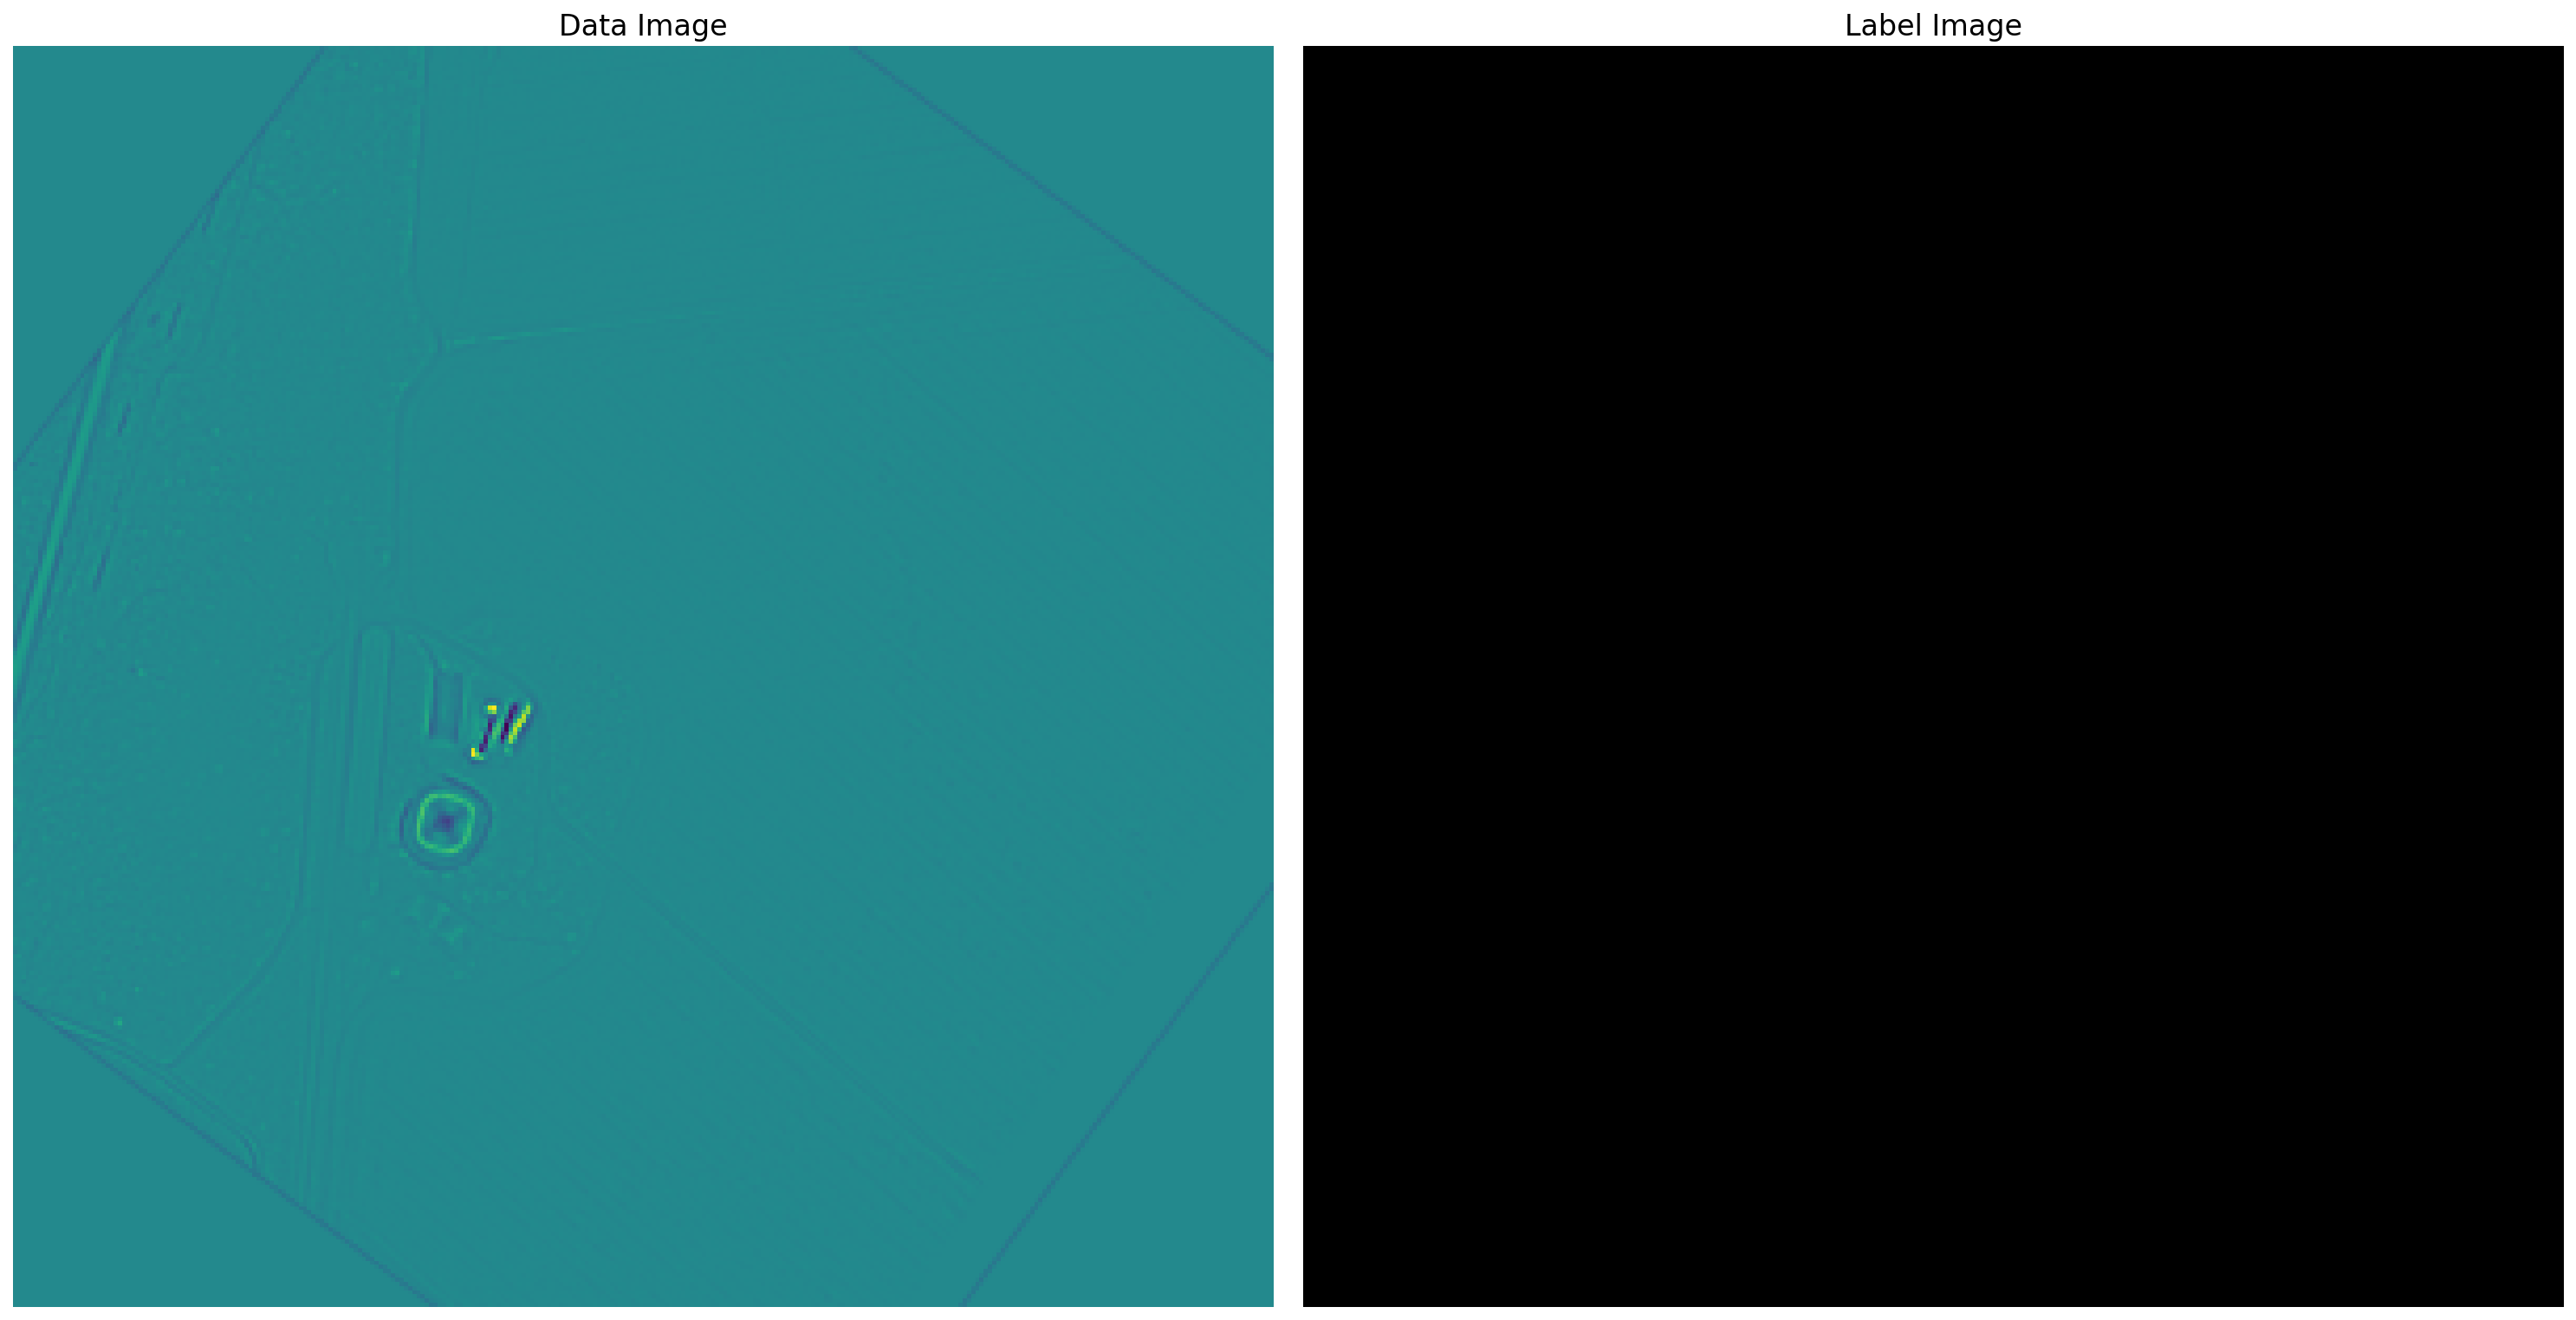

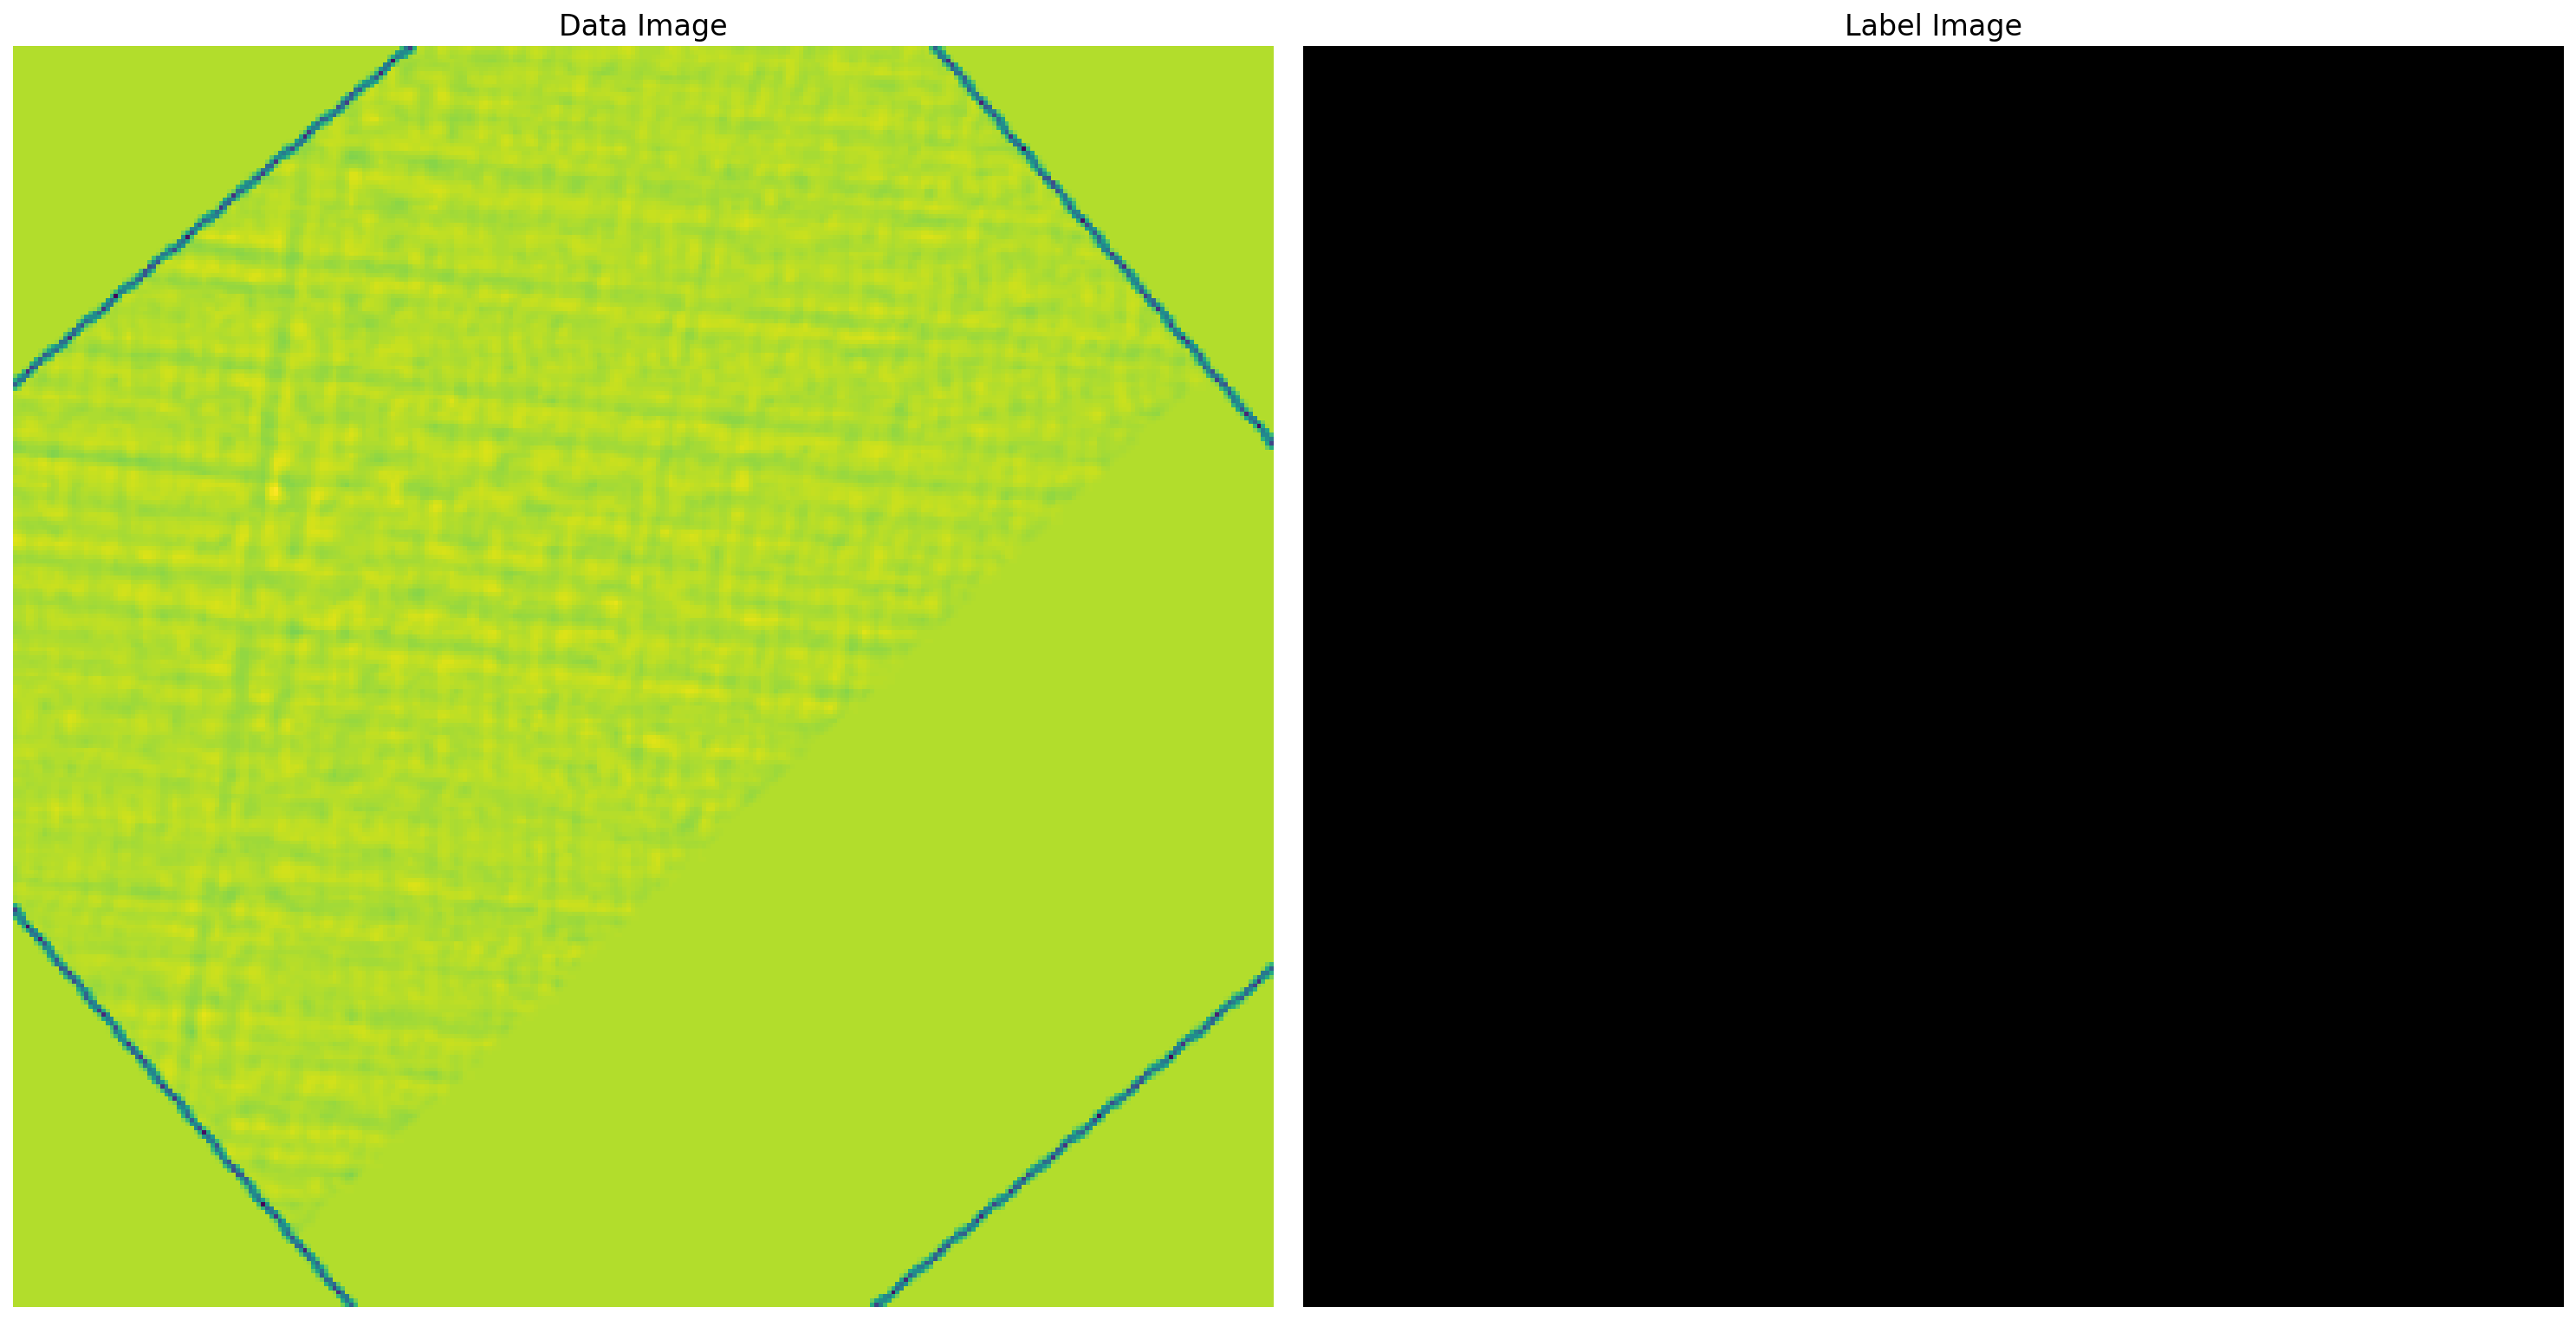

In [52]:
show_images_from_segmented_data_with_labels(md.segmented_data_with_labels, num_images=30)